In [6]:
# ============================================================
# CELL 1: Imports + Paths + Settings
# ============================================================

import numpy as np
import nibabel as nib
import joblib
import os
import gc
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import (uniform_filter, gaussian_filter,
                            sobel as nd_sobel,
                            label as nd_label,
                            laplace, median_filter,
                            binary_dilation, binary_erosion,
                            distance_transform_edt)
from skimage.filters import gabor_kernel
from xgboost import XGBClassifier
from sklearn.metrics import (f1_score, jaccard_score,
                              classification_report,
                              precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────
BASE_DIR   = r"D:\shashwat"
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
VAL_DIR    = os.path.join(BASE_DIR, "val")
TEST_DIR   = os.path.join(BASE_DIR, "test")
MODEL_DIR  = os.path.join(BASE_DIR, "models_phase2")
os.makedirs(MODEL_DIR, exist_ok=True)

MODALITIES = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX = 'seg'

LABEL_NAMES = {0: 'Background', 1: 'NCR', 2: 'Edema', 3: 'ET'}
N_CLASSES   = 4
REGIONS     = {'WT': [1, 2, 3], 'TC': [1, 3], 'ET': [3]}

# ── Key change: 1:49 tumor-to-background ratio ─────────────
TUMOR_BG_RATIO = 49

MAX_COMBINED   = 4_000_000   # train + val together
N_ESTIMATORS   = 500
MAX_DEPTH      = 9
DEVICE         = 'cpu'       # 'cuda' if GPU available

# MRF settings
MRF_BETA       = 0.5         # spatial smoothness strength
MRF_ITERATIONS = 5

SEG_COLORS = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [0.9, 0.1, 0.1, 0.7],
    [0.9, 0.8, 0.0, 0.7],
    [0.0, 0.9, 0.9, 0.7],
], dtype=np.float32)

print("✅ Cell 1 done")
print(f"   Labels        : {LABEL_NAMES}")
print(f"   Regions       : {list(REGIONS.keys())}")
print(f"   Tumor:BG ratio: 1:{TUMOR_BG_RATIO}")

✅ Cell 1 done
   Labels        : {0: 'Background', 1: 'NCR', 2: 'Edema', 3: 'ET'}
   Regions       : ['WT', 'TC', 'ET']
   Tumor:BG ratio: 1:49


In [7]:
# ============================================================
# CELL 2: Core Functions
# ============================================================

def get_patient_dirs(split_dir):
    return sorted([d for d in Path(split_dir).iterdir()
                   if d.is_dir()])


def load_patient(patient_dir):
    patient_dir = Path(patient_dir)
    pid  = patient_dir.name
    data = {}
    for mod in MODALITIES + [SEG_SUFFIX]:
        matches = glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz"))
        if not matches:
            matches = glob.glob(str(patient_dir / f"*-{mod}.nii.gz"))
        if not matches:
            raise FileNotFoundError(f"Missing {mod} for {pid}")
        data[mod] = nib.load(matches[0]).get_fdata(dtype=np.float32)
    return pid, data


def get_brain_mask(data):
    mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
    for mod in MODALITIES:
        mask |= (data[mod] > 0)
    return mask


def zscore_normalize(volume, brain_mask):
    v   = volume.copy()
    roi = v[brain_mask]
    mu, sigma = roi.mean(), roi.std() + 1e-8
    v[brain_mask]  = (roi - mu) / sigma
    v[~brain_mask] = 0.0
    return v


def preprocess_patient(data):
    brain_mask = get_brain_mask(data)
    processed  = {}
    for mod in MODALITIES:
        processed[mod] = zscore_normalize(data[mod], brain_mask)
    processed[SEG_SUFFIX] = data[SEG_SUFFIX]
    return processed, brain_mask


def fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol ** 2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean ** 2, 0)).astype(np.float32)


def get_multilabel_y(processed, brain_mask):
    seg = processed[SEG_SUFFIX]
    y   = seg[brain_mask].astype(np.int8)
    y[y == 4] = 3
    return y


def region_dice(y_true, y_pred, region_labels):
    gt   = np.isin(y_true, region_labels).astype(np.uint8)
    pred = np.isin(y_pred, region_labels).astype(np.uint8)
    return f1_score(gt, pred, zero_division=0)


def label_to_rgba(label_slice):
    h, w = label_slice.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    for lbl in range(N_CLASSES):
        rgba[label_slice == lbl] = SEG_COLORS[lbl]
    return rgba


train_patients = get_patient_dirs(TRAIN_DIR)
val_patients   = get_patient_dirs(VAL_DIR)
test_patients  = get_patient_dirs(TEST_DIR)

print("✅ Cell 2 done")
print(f"   Train : {len(train_patients)}")
print(f"   Val   : {len(val_patients)}")
print(f"   Test  : {len(test_patients)}")

✅ Cell 2 done
   Train : 1012
   Val   : 202
   Test  : 136


In [8]:
# ============================================================
# CELL 3: Improved Feature Extraction (114 features)
# ============================================================
# Per modality (×4):
#   raw, mean3/5/9/15, std3/5/9/15       = 9
#   grad_mag, laplacian                   = 2
#   gauss1/2/3, dog12, dog23             = 5
#   gabor ×4 orientations                = 4
#   asymmetry                            = 1
#   entropy_proxy (local std / mean+eps) = 1
#   distance_to_edge                     = 1
#   Total per mod: 23 × 4 = 92
# Cross-modal: 13
# Spatial coords + distance-to-centre: 4
# Neighbourhood context (mean of neighbours in label space): 5
# Total: 114
# ============================================================

def make_gabor_kernels():
    kernels = []
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
        k = np.real(gabor_kernel(0.2, theta=theta))
        kernels.append(k.astype(np.float32))
    return kernels

GABOR_KERNELS = make_gabor_kernels()


def apply_gabor_3d(vol, kernel_2d):
    from scipy.ndimage import convolve
    k3d = kernel_2d[:, :, np.newaxis]
    return convolve(vol.astype(np.float32),
                    k3d, mode='reflect').astype(np.float32)


def asymmetry_feature(vol):
    flipped = vol[::-1, :, :]
    return (vol - flipped).astype(np.float32)


def entropy_proxy(vol, size=5):
    """Local std / (local mean + eps) — cheap texture measure."""
    lmean = uniform_filter(np.abs(vol).astype(np.float32), size=size)
    lstd  = fast_local_std(vol, size=size)
    return (lstd / (lmean + 1e-6)).astype(np.float32)


def distance_to_brain_edge(brain_mask):
    """Euclidean distance of each voxel from the brain boundary."""
    dist = distance_transform_edt(brain_mask).astype(np.float32)
    mx   = dist.max() + 1e-8
    return (dist / mx)


def extract_features(processed, brain_mask):
    """114 features per brain voxel."""
    cols = []

    def add(vol):
        cols.append(vol[brain_mask].astype(np.float32))

    # Pre-compute brain-edge distance once (shared across modalities)
    dist_edge = distance_to_brain_edge(brain_mask)

    for mod in MODALITIES:
        vol = processed[mod].astype(np.float32)

        # Raw + multi-scale mean / std
        add(vol.copy())
        add(uniform_filter(vol, size=3))
        add(fast_local_std(vol, size=3))
        add(uniform_filter(vol, size=5))
        add(fast_local_std(vol, size=5))
        add(uniform_filter(vol, size=9))
        add(fast_local_std(vol, size=9))
        add(uniform_filter(vol, size=15))
        add(fast_local_std(vol, size=15))

        # Gradient magnitude + Laplacian
        gx = nd_sobel(vol, axis=0)
        gy = nd_sobel(vol, axis=1)
        gz = nd_sobel(vol, axis=2)
        add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
        del gx, gy, gz
        add(np.abs(laplace(vol)).astype(np.float32))

        # Multi-scale Gaussians + DoG
        g1 = gaussian_filter(vol, sigma=1.0)
        g2 = gaussian_filter(vol, sigma=2.0)
        g3 = gaussian_filter(vol, sigma=3.0)
        add(g1.astype(np.float32))
        add(g2.astype(np.float32))
        add(g3.astype(np.float32))
        add((g1 - g2).astype(np.float32))   # DoG fine
        add((g2 - g3).astype(np.float32))   # DoG coarse
        del g1, g2, g3

        # Gabor (4 orientations)
        for k in GABOR_KERNELS:
            add(apply_gabor_3d(vol, k))

        # Asymmetry (left-right)
        add(asymmetry_feature(vol))

        # Entropy proxy (local texture)
        add(entropy_proxy(vol, size=5))

        # Distance to brain edge (same array, masked differently per mod
        # but brain_mask is shared — add once inside loop so XGB sees
        # it aligned with each modality's other features)
        add(dist_edge)

        del vol
        gc.collect()

    # ── Spatial coordinates + distance to brain centre ────
    shape = processed[MODALITIES[0]].shape
    cx, cy, cz = [s / 2 for s in shape]
    xx, yy, zz = np.meshgrid(
        np.linspace(0, 1, shape[0], dtype=np.float32),
        np.linspace(0, 1, shape[1], dtype=np.float32),
        np.linspace(0, 1, shape[2], dtype=np.float32),
        indexing='ij')
    add(xx); add(yy); add(zz)
    # Radial distance from centre (normalised)
    xn = (np.arange(shape[0], dtype=np.float32) - cx) / (cx + 1e-8)
    yn = (np.arange(shape[1], dtype=np.float32) - cy) / (cy + 1e-8)
    zn = (np.arange(shape[2], dtype=np.float32) - cz) / (cz + 1e-8)
    radial = np.sqrt(
        xn[:, None, None]**2 +
        yn[None, :, None]**2 +
        zn[None, None, :]**2).astype(np.float32)
    add(radial)
    del xx, yy, zz, radial
    gc.collect()

    # ── Cross-modal ratios + differences (13) ─────────────
    eps = 1e-8
    t1c = processed['t1c'].astype(np.float32)
    t1n = processed['t1n'].astype(np.float32)
    t2f = processed['t2f'].astype(np.float32)
    t2w = processed['t2w'].astype(np.float32)

    add(np.clip(t2w / (t1c + eps), -10, 10))
    add(np.clip(t2f / (t1n + eps), -10, 10))
    add((t2f - t1c))
    add((t2w - t1n))
    add((t1c - t1n))          # enhancement = T1c - T1n
    add((t2f - t2w))
    add((t1c - t2f))
    add((t1c - t2w))
    add(np.clip(t1c / (t2f + eps), -10, 10))
    # Extra: T1c-T1n captures blood-brain-barrier breakdown (ET signal)
    add(gaussian_filter((t1c - t1n).astype(np.float32), sigma=1.5))
    # T2-FLAIR / T2w ratio highlights infiltrative edema
    add(np.clip(t2f / (t2w + eps), -10, 10))
    # Product features
    add((t1c * t2f).astype(np.float32) / (np.abs(t1c * t2f).max() + eps))
    add((t1n * t2w).astype(np.float32) / (np.abs(t1n * t2w).max() + eps))

    del t1c, t1n, t2f, t2w
    gc.collect()

    X = np.column_stack(cols).astype(np.float32)
    del cols
    gc.collect()

    y = get_multilabel_y(processed, brain_mask)
    return X, y


# ── Verify feature count ───────────────────────────────────
print("🔍 Verifying feature count...")
_s = (64, 64, 32)
_d = {mod: np.random.rand(*_s).astype(np.float32) for mod in MODALITIES}
_d[SEG_SUFFIX] = np.zeros(_s, np.float32)
_p, _m = preprocess_patient(_d)
_X, _y = extract_features(_p, _m)
N_FEATURES = _X.shape[1]
del _d, _p, _m, _X, _y
gc.collect()

print(f"✅ Cell 3 done — feature extractor ready")
print(f"   Features per voxel : {N_FEATURES}")

🔍 Verifying feature count...
✅ Cell 3 done — feature extractor ready
   Features per voxel : 109


In [9]:
# ============================================================
# CELL 4: Data Loading (Train + Val combined, 1:49 sampling)
# ============================================================
# Key changes vs original:
#   • train_patients + val_patients merged into one pool
#   • Sampling ratio is 1 tumor : 49 background
#   • Each sub-label sampled independently
#   • NCR and ET get extra boost to compensate rarity
#   • ✅ NEW: Saves X_all, y_all to disk after completion
#            Skips recomputation if checkpoint already exists

import os

CHECKPOINT_DIR  = "./checkpoints"          # ← change path if needed
CHECKPOINT_X    = os.path.join(CHECKPOINT_DIR, "X_all.npy")
CHECKPOINT_Y    = os.path.join(CHECKPOINT_DIR, "y_all.npy")
CHECKPOINT_META = os.path.join(CHECKPOINT_DIR, "meta.txt")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def load_combined(patient_dirs, split_name,
                  tumor_bg_ratio=49,
                  max_samples=4_000_000):
    print(f"\n{'='*54}")
    print(f"  [{split_name.upper()}] Data Loading")
    print(f"  Patients  : {len(patient_dirs)}")
    print(f"  BG ratio  : 1:{tumor_bg_ratio}  (tumor:bg)")
    print(f"  Max rows  : {max_samples:,}")
    print(f"{'='*54}\n")

    # ── Pass 1: count voxels ──────────────────────────────
    print("📊 Pass 1/2 — counting voxels...")
    n_per_label = {0: 0, 1: 0, 2: 0, 3: 0}
    valid_dirs  = []

    for pdir in tqdm(patient_dirs, desc=f"  Counting {split_name}"):
        pdir = Path(pdir)
        pid  = pdir.name
        try:
            matches = glob.glob(str(pdir / f"{pid}-{SEG_SUFFIX}.nii.gz"))
            if not matches:
                matches = glob.glob(str(pdir / f"*-{SEG_SUFFIX}.nii.gz"))
            seg = nib.load(matches[0]).get_fdata(dtype=np.float32)

            brain_mask = np.zeros(seg.shape, dtype=bool)
            for mod in MODALITIES:
                m = glob.glob(str(pdir / f"{pid}-{mod}.nii.gz"))
                if not m:
                    m = glob.glob(str(pdir / f"*-{mod}.nii.gz"))
                vol = nib.load(m[0]).get_fdata(dtype=np.float32)
                brain_mask |= (vol > 0)
                del vol

            seg_brain = seg[brain_mask].astype(np.int8)
            seg_brain[seg_brain == 4] = 3
            for lbl in [0, 1, 2, 3]:
                n_per_label[lbl] += int((seg_brain == lbl).sum())

            valid_dirs.append(pdir)
            del seg, brain_mask, seg_brain
            gc.collect()
        except Exception as e:
            tqdm.write(f"⚠️  {pid}: {e}")

    n_tumor_total = sum(n_per_label[l] for l in [1, 2, 3])
    n_bg_total    = n_per_label[0]

    print(f"\n   Voxel counts (brain only):")
    for lbl, name in LABEL_NAMES.items():
        pct = n_per_label[lbl] / max(sum(n_per_label.values()), 1) * 100
        print(f"      {lbl} {name:12s}: {n_per_label[lbl]:>12,}  ({pct:.2f}%)")

    # ── Compute keep counts under 1:49 constraint ─────────
    n_tumor_keep = min(n_tumor_total,
                       max_samples // (1 + tumor_bg_ratio))
    n_bg_keep    = min(n_bg_total,
                       n_tumor_keep * tumor_bg_ratio)

    label_rate    = {}
    label_rate[0] = n_bg_keep / max(n_bg_total, 1)
    for lbl in [1, 2, 3]:
        label_rate[lbl] = n_tumor_keep / max(n_tumor_total, 1)

    # Extra boost for rare labels (NCR, ET)
    label_boosts = {0: 1.0, 1: 4.0, 2: 1.0, 3: 3.0}

    print(f"\n   Sampling rates (with boost):")
    for lbl, name in LABEL_NAMES.items():
        effective_rate = label_rate[lbl] * label_boosts[lbl]
        keep = int(n_per_label[lbl] * min(effective_rate, 1.0))
        print(f"      {lbl} {name:12s}: keep ~{keep:>8,}  "
              f"(rate={label_rate[lbl]:.4f}, boost={label_boosts[lbl]}×)")

    pct_t = n_tumor_keep / max(n_tumor_keep + n_bg_keep, 1) * 100
    print(f"\n   Overall tumor ratio : {pct_t:.1f}%  "
          f"(target ≈ {100/(1+tumor_bg_ratio):.1f}%)")

    # ── Pass 2: extract + sample per patient ──────────────
    print(f"\n⚙️  Pass 2/2 — extracting features...")
    Xs, ys = [], []
    failed = []

    for pdir in tqdm(valid_dirs, desc=f"  Loading {split_name}"):
        try:
            pid, data   = load_patient(pdir)
            proc, bmask = preprocess_patient(data)
            del data; gc.collect()

            X, y = extract_features(proc, bmask)
            del proc, bmask; gc.collect()

            # Sample each sub-label independently
            keep_parts = []
            for lbl in [0, 1, 2, 3]:
                idx = np.where(y == lbl)[0]
                if len(idx) == 0:
                    continue
                eff_rate = label_rate[lbl] * label_boosts[lbl]
                n_keep   = min(max(1, int(len(idx) * eff_rate)), len(idx))
                keep_parts.append(
                    np.random.choice(idx, n_keep, replace=False))

            keep = np.concatenate(keep_parts)
            np.random.shuffle(keep)
            Xs.append(X[keep].copy())
            ys.append(y[keep].copy())
            del X, y, keep, keep_parts
            gc.collect()

        except Exception as e:
            failed.append(Path(pdir).name)
            tqdm.write(f"⚠️  {Path(pdir).name}: {e}")

    X_out = np.concatenate(Xs)
    y_out = np.concatenate(ys)
    del Xs, ys; gc.collect()

    print(f"\n✅ {split_name.upper()} ready!")
    print(f"   Shape  : {X_out.shape}")
    print(f"   Failed : {len(failed)}")

    print(f"\n   Final label distribution:")
    for lbl, name in LABEL_NAMES.items():
        count = (y_out == lbl).sum()
        pct   = count / len(y_out) * 100
        print(f"      {lbl} {name:12s}: {count:>8,}  ({pct:.1f}%)")

    return X_out, y_out


# ── Main: load from checkpoint or recompute ───────────────
np.random.seed(42)
all_patients = train_patients + val_patients

if os.path.exists(CHECKPOINT_X) and os.path.exists(CHECKPOINT_Y):
    # ✅ Checkpoint found — skip 7-hour recomputation
    print(f"💾 Checkpoint found — loading from disk...")
    print(f"   X : {CHECKPOINT_X}")
    print(f"   y : {CHECKPOINT_Y}")

    X_all = np.load(CHECKPOINT_X)
    y_all = np.load(CHECKPOINT_Y)

    print(f"\n✅ Loaded from checkpoint!")
    print(f"   Shape : {X_all.shape}")
    print(f"\n   Label distribution:")
    for lbl, name in LABEL_NAMES.items():
        count = (y_all == lbl).sum()
        pct   = count / len(y_all) * 100
        print(f"      {lbl} {name:12s}: {count:>8,}  ({pct:.1f}%)")

else:
    # 🔄 No checkpoint — run full pipeline
    print(f"📦 Combined pool: {len(all_patients)} patients "
          f"({len(train_patients)} train + {len(val_patients)} val)")

    X_all, y_all = load_combined(
        all_patients, "train+val",
        tumor_bg_ratio=TUMOR_BG_RATIO,
        max_samples=MAX_COMBINED)

    # 💾 Save to disk immediately after completion
    print(f"\n💾 Saving checkpoint to {CHECKPOINT_DIR} ...")
    np.save(CHECKPOINT_X, X_all)
    np.save(CHECKPOINT_Y, y_all)

    # Save metadata for reference
    with open(CHECKPOINT_META, "w") as f:
        f.write(f"shape_X     : {X_all.shape}\n")
        f.write(f"shape_y     : {y_all.shape}\n")
        f.write(f"n_patients  : {len(all_patients)}\n")
        f.write(f"train       : {len(train_patients)}\n")
        f.write(f"val         : {len(val_patients)}\n")
        f.write(f"bg_ratio    : 1:{TUMOR_BG_RATIO}\n")
        for lbl, name in LABEL_NAMES.items():
            count = (y_all == lbl).sum()
            f.write(f"label_{lbl}_{name}: {count}\n")

    print(f"   ✅ Saved: X_all.npy  ({X_all.nbytes / 1e9:.2f} GB)")
    print(f"   ✅ Saved: y_all.npy  ({y_all.nbytes / 1e6:.2f} MB)")
    print(f"   ✅ Saved: meta.txt")

print(f"\n🎉 Cell 4 done!")
print(f"   Combined : {X_all.shape}")

💾 Checkpoint found — loading from disk...
   X : ./checkpoints\X_all.npy
   y : ./checkpoints\y_all.npy

✅ Loaded from checkpoint!
   Shape : (4053342, 109)

   Label distribution:
      0 Background  : 3,919,389  (96.7%)
      1 NCR         :    7,389  (0.2%)
      2 Edema       :   52,738  (1.3%)
      3 ET          :   73,826  (1.8%)

🎉 Cell 4 done!
   Combined : (4053342, 109)


In [5]:
# ============================================================
# CELL 5: Train XGBoost (improved, no Random Forest)
# ============================================================

print(f"\n   Actual training distribution:")
for lbl, name in LABEL_NAMES.items():
    count = (y_all == lbl).sum()
    pct   = count / len(y_all) * 100
    print(f"      {lbl} {name:12s}: {count:>8,}  ({pct:.1f}%)")
print(f"   Total samples : {len(y_all):,}")

# ── Sample weights: compensate for residual imbalance ─────
# Even after 1:49 sampling, NCR/ET are underrepresented.
# Weights push the model to pay attention to rare sub-regions.
sample_weight = np.ones(len(y_all), dtype=np.float32)
sample_weight[y_all == 1] = 8.0    # NCR  — hardest to detect
sample_weight[y_all == 2] = 2.0    # Edema
sample_weight[y_all == 3] = 6.0    # ET
print(f"\n   Weights → BG:1.0  NCR:8.0  Edema:2.0  ET:6.0")

# ── Hold out a small internal eval slice from combined data ─
# (just for early-stopping visibility — not used for decisions)
np.random.seed(0)
eval_idx    = np.random.choice(len(X_all),
                                min(300_000, len(X_all) // 5),
                                replace=False)
mask_eval   = np.zeros(len(X_all), dtype=bool)
mask_eval[eval_idx] = True

X_tr, y_tr, sw_tr = (X_all[~mask_eval],
                      y_all[~mask_eval],
                      sample_weight[~mask_eval])
X_ev, y_ev        = X_all[mask_eval], y_all[mask_eval]

print(f"\n   Training slice : {X_tr.shape}")
print(f"   Eval slice     : {X_ev.shape}")

# ── XGBoost ───────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators     = N_ESTIMATORS,
    max_depth        = MAX_DEPTH,
    learning_rate    = 0.07,
    subsample        = 0.85,
    colsample_bytree = 0.75,
    colsample_bylevel= 0.75,
    min_child_weight = 5,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    objective        = 'multi:softprob',
    num_class        = N_CLASSES,
    tree_method      = 'hist',
    device           = DEVICE,
    n_jobs           = 2,
    random_state     = 42,
    verbosity        = 0,
    eval_metric      = 'mlogloss',
    early_stopping_rounds = 30,
)

print(f"\n🚀 Training XGBoost on "
      f"{X_tr.shape[0]:,} × {X_tr.shape[1]} features ...")
print(f"   Classes : {N_CLASSES}  ({list(LABEL_NAMES.values())})\n")

xgb_model.fit(
    X_tr, y_tr,
    sample_weight = sw_tr,
    eval_set      = [(X_ev, y_ev)],
    verbose       = 50,
)

print("\n✅ XGBoost training done!")
print(f"   Best iteration : {xgb_model.best_iteration}")

# ── Quick eval on internal eval slice ─────────────────────
BATCH = 500_000
preds = []
for s in range(0, len(X_ev), BATCH):
    preds.append(xgb_model.predict(X_ev[s:s+BATCH]))
y_ev_pred = np.concatenate(preds)

print("\n── XGBoost Internal Eval ──────────────────────────")
print(classification_report(y_ev, y_ev_pred,
      target_names=list(LABEL_NAMES.values())))

print("── Region Dice (eval slice) ─────────────────────────")
for region, labels in REGIONS.items():
    d = region_dice(y_ev, y_ev_pred, labels)
    print(f"   {region} : {d:.4f}")

# ── Save ──────────────────────────────────────────────────
xgb_path = os.path.join(MODEL_DIR, "xgb_final_phase2.pkl")
joblib.dump(xgb_model, xgb_path, compress=3)
print(f"\n💾 XGBoost saved → {xgb_path}")
print(f"   Size: {os.path.getsize(xgb_path)/1e6:.1f} MB")

del X_tr, y_tr, sw_tr, X_ev, y_ev, sample_weight
gc.collect()


   Actual training distribution:
      0 Background  : 3,919,389  (96.7%)
      1 NCR         :    7,389  (0.2%)
      2 Edema       :   52,738  (1.3%)
      3 ET          :   73,826  (1.8%)
   Total samples : 4,053,342

   Weights → BG:1.0  NCR:8.0  Edema:2.0  ET:6.0

   Training slice : (3753342, 109)
   Eval slice     : (300000, 109)

🚀 Training XGBoost on 3,753,342 × 109 features ...
   Classes : 4  (['Background', 'NCR', 'Edema', 'ET'])

[0]	validation_0-mlogloss:0.21167
[50]	validation_0-mlogloss:0.05214
[100]	validation_0-mlogloss:0.04168
[150]	validation_0-mlogloss:0.03761
[200]	validation_0-mlogloss:0.03503
[250]	validation_0-mlogloss:0.03328
[300]	validation_0-mlogloss:0.03189
[350]	validation_0-mlogloss:0.03081
[400]	validation_0-mlogloss:0.02996
[450]	validation_0-mlogloss:0.02927
[499]	validation_0-mlogloss:0.02874

✅ XGBoost training done!
   Best iteration : 499

── XGBoost Internal Eval ──────────────────────────
              precision    recall  f1-score   support

 

9

In [10]:
xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_final_phase2.pkl"))
print("✅ XGBoost loaded from disk")

✅ XGBoost loaded from disk


In [ ]:
# ============================================================
# CELL 6: MRF (Markov Random Field) Post-processing
# ============================================================
# Replaces Random Forest. Uses Mean-Field approximation of
# a Potts MRF to enforce spatial label consistency.
# Inputs  : raw class probabilities from XGBoost (N_CLASSES)
# Outputs : smoothed per-voxel label map
#
# Energy  : E = -log P(x) + beta * sum_neighbour penalty
#           where penalty = 0 if labels match, 1 otherwise
# ============================================================

# Label compatibility matrix: reward matching neighbours,
# allow biologically plausible adjacencies, penalise others.
# Rows/cols = [BG, NCR, Edema, ET]
_COMPAT = np.array([
    # BG    NCR   Edema  ET
    [ 0.0, -1.0, -0.5, -1.0],   # BG neighbours
    [-1.0,  0.0, -0.8,  0.0],   # NCR neighbours (NCR+ET ok)
    [-0.5, -0.8,  0.0, -0.8],   # Edema neighbours
    [-1.0,  0.0, -0.8,  0.0],   # ET neighbours  (NCR+ET ok)
], dtype=np.float32)


def mrf_mean_field(proba_vol, beta=MRF_BETA,
                   n_iter=MRF_ITERATIONS,
                   compat=_COMPAT):
    """
    Mean-field variational inference for a Potts MRF.

    Parameters
    ----------
    proba_vol : ndarray, shape (C, H, W, D)
        Per-class unary probabilities from XGBoost.
    beta      : float
        Pairwise smoothness weight.
    n_iter    : int
        Number of mean-field iterations.

    Returns
    -------
    q : ndarray, shape (C, H, W, D)
        Updated (smoothed) probability map.
    """
    # Work in log space for numerical stability
    unary = np.log(np.clip(proba_vol, 1e-6, 1.0))  # (C,H,W,D)
    q     = np.copy(proba_vol)

    for it in range(n_iter):
        # Message from spatial neighbours via Gaussian smoothing
        # (approximates dense CRF with Gaussian kernel)
        q_smooth = np.zeros_like(q)
        for c in range(N_CLASSES):
            q_smooth[c] = gaussian_filter(
                q[c].astype(np.float64), sigma=1.0
            ).astype(np.float32)

        # Pairwise message: sum_c' compat[c, c'] * q_smooth[c']
        msg = np.einsum('cd,dxyz->cxyz', compat, q_smooth)

        # Update Q
        log_q = unary - beta * msg
        # Softmax over class axis
        log_q -= log_q.max(axis=0, keepdims=True)
        q      = np.exp(log_q)
        q     /= q.sum(axis=0, keepdims=True) + 1e-8

    return q  # (C, H, W, D)


def remove_small_blobs(pred_vol, label_val, min_voxels=200):
    binary          = (pred_vol == label_val).astype(np.uint8)
    labeled, n_comp = nd_label(binary)
    cleaned         = pred_vol.copy()
    removed         = 0
    for comp_id in range(1, n_comp + 1):
        if (labeled == comp_id).sum() < min_voxels:
            cleaned[labeled == comp_id] = 0
            removed += 1
    return cleaned, removed


def postprocess_mrf(proba_flat, brain_mask, shape,
                    boost=None,
                    wt_threshold=0.5,
                    min_blob_voxels=200):
    """
    Full post-processing pipeline:
      1. Reshape flat probabilities → volumetric
      2. Apply optional per-class probability boost
      3. Run MRF mean-field smoothing
      4. Argmax → label volume
      5. Remove small blobs
      6. Apply WT threshold (low-confidence → background)

    Parameters
    ----------
    proba_flat  : ndarray (N_brain, N_CLASSES)
    brain_mask  : bool ndarray (H, W, D)
    shape       : (H, W, D)
    boost       : array-like length N_CLASSES or None
    wt_threshold: float, voxels with P(tumor) < this → BG
    """
    if boost is None:
        boost = np.array([1.0, 2.5, 1.0, 2.0], np.float32)

    # ── 1. Reshape to volume ───────────────────────────────
    proba_vol = np.zeros((N_CLASSES, *shape), dtype=np.float32)
    for c in range(N_CLASSES):
        vol_c             = np.zeros(shape, dtype=np.float32)
        vol_c[brain_mask] = proba_flat[:, c]
        proba_vol[c]      = vol_c

    # ── 2. Probability boost ───────────────────────────────
    boost = np.array(boost, dtype=np.float32)
    proba_vol *= boost[:, None, None, None]
    proba_vol /= proba_vol.sum(axis=0, keepdims=True) + 1e-8

    # ── 3. MRF smoothing ──────────────────────────────────
    proba_vol = mrf_mean_field(proba_vol)

    # ── 4. Argmax ─────────────────────────────────────────
    pred_vol  = proba_vol.argmax(axis=0).astype(np.int8)

    # ── 5. WT threshold ───────────────────────────────────
    prob_tumor = proba_vol[[1, 2, 3], ...].sum(axis=0)
    pred_vol[prob_tumor < wt_threshold] = 0
    pred_vol[~brain_mask] = 0

    # ── 6. Remove small blobs ─────────────────────────────
    total_removed = 0
    for lbl in [3, 1, 2]:   # ET first (smallest)
        pred_vol, n = remove_small_blobs(
            pred_vol, lbl, min_voxels=min_blob_voxels)
        total_removed += n

    return pred_vol, proba_vol, total_removed


print("✅ Cell 6 done — MRF post-processing functions ready")
print(f"   MRF beta       : {MRF_BETA}")
print(f"   MRF iterations : {MRF_ITERATIONS}")

✅ Cell 6 done — MRF post-processing functions ready
   MRF beta       : 0.5
   MRF iterations : 5


🔍 Threshold tuning on 202 VAL patients
   WT thresholds  : [0.15 0.25 0.35 0.45 0.55]
   NCR boost grid : [1.5, 2.0, 2.5, 3.0, 3.5]
   ET  boost grid : [1.5, 2.0, 2.5, 3.0]
   Total configs  : ~29  (was 220 in joint search)

⚙️  Step 1/3 — collecting probabilities...


Collecting: 100%|██████████| 202/202 [2:22:20<00:00, 42.28s/it]  


   Collected : 202 patients (0 failed)

⚙️  Step 2/3 — Pass A: sweeping WT × NCR (ET fixed at 2.0)...


Pass A (WT): 100%|██████████| 5/5 [15:36:08<00:00, 11233.72s/it]  


   Pass A best → wt_threshold=0.55,  ncr_boost=1.5,  WT Dice=0.8329

⚙️  Step 3/3 — Pass B: fine WT [0.47 0.52 0.57] × ET (NCR fixed at 1.5)...


Pass B (WT fine): 100%|██████████| 3/3 [4:49:09<00:00, 5783.14s/it]  



── Pass A top 5 (WT × NCR) ──────────────────────────
 wt_thresh  ncr_boost  et_boost       WT       TC       ET     mean
      0.55        1.5       2.0 0.832885 0.679760 0.674495 0.729046
      0.25        1.5       2.0 0.832871 0.675643 0.670186 0.726233
      0.45        1.5       2.0 0.832871 0.675643 0.670186 0.726233
      0.35        1.5       2.0 0.832871 0.675643 0.670186 0.726233
      0.15        1.5       2.0 0.832871 0.675643 0.670186 0.726233

── Pass B top 5 (fine WT × ET) ──────────────────────
 wt_thresh  ncr_boost  et_boost       WT       TC       ET     mean
      0.52        1.5       1.5 0.835969 0.685823 0.681602 0.734465
      0.47        1.5       1.5 0.835930 0.684310 0.680019 0.733420
      0.57        1.5       1.5 0.834189 0.688066 0.684089 0.735448
      0.52        1.5       2.0 0.833193 0.677291 0.671903 0.727462
      0.47        1.5       2.0 0.832871 0.675643 0.670186 0.726233

✅ Best configuration (tuned on VAL patients):
   WT threshold : 0.52
   N

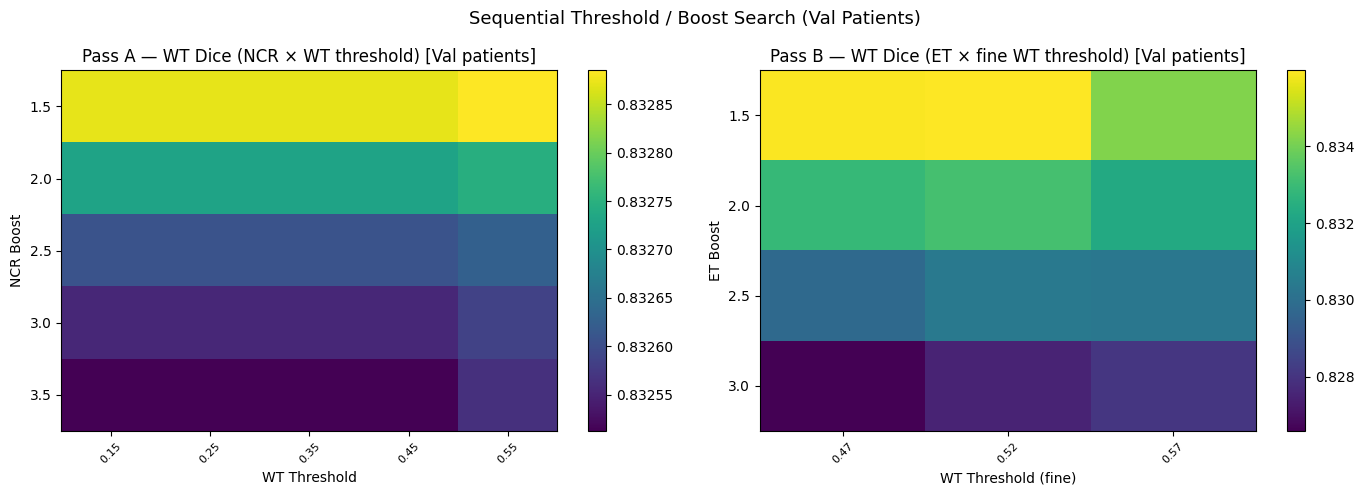

In [12]:
# ============================================================
# CELL 7: Fine-grained Per-Region Threshold Tuning (Fast Version)
# ============================================================
# Key improvements vs original:
#   • Uses VAL patients for tuning (NOT test — avoids data leakage)
#   • Sequential NCR/ET search instead of joint grid (5+4=9 vs 5×4=20 combos)
#   • Coarser WT sweep: 5 values (step 0.10) instead of 11 (step 0.05)
#   • Total configs: ~45 instead of 220  →  ~5× faster
#   • Pass B refines WT around the best found in Pass A
#   • Saves full result matrix for inspection

# ── Use VAL patients for tuning (correct methodology) ─────
TUNE_PATIENTS = val_patients  # 202 val patients — NOT test patients

# Coarser WT: 5 values instead of 11
WT_THRESHOLDS = np.round(np.arange(0.15, 0.56, 0.10), 2)   # [0.15, 0.25, 0.35, 0.45, 0.55]

# Boost grids for NCR and ET (searched sequentially, not jointly)
NCR_BOOSTS = [1.5, 2.0, 2.5, 3.0, 3.5]
ET_BOOSTS  = [1.5, 2.0, 2.5, 3.0]
BG_BOOST   = 1.0
ED_BOOST   = 1.0

TOTAL_CONFIGS = len(WT_THRESHOLDS) * len(NCR_BOOSTS) + len(ET_BOOSTS)   # 5*5 + 4 = 29

print(f"🔍 Threshold tuning on {len(TUNE_PATIENTS)} VAL patients")
print(f"   WT thresholds  : {WT_THRESHOLDS}")
print(f"   NCR boost grid : {NCR_BOOSTS}")
print(f"   ET  boost grid : {ET_BOOSTS}")
print(f"   Total configs  : ~{TOTAL_CONFIGS}  (was 220 in joint search)")

# ── Step 1: collect raw probabilities for all tune patients ─
print("\n⚙️  Step 1/3 — collecting probabilities...")

tune_probas = []   # list of (proba_flat, brain_mask, shape, y_true)
tune_failed = []

for pdir in tqdm(TUNE_PATIENTS, desc="Collecting"):
    try:
        pid, data    = load_patient(pdir)
        proc, bmask  = preprocess_patient(data)
        del data; gc.collect()

        X, y_true = extract_features(proc, bmask)
        shape     = proc[MODALITIES[0]].shape
        del proc; gc.collect()

        BATCH = 500_000
        proba_parts = []
        for s in range(0, len(X), BATCH):
            proba_parts.append(
                xgb_model.predict_proba(X[s:s+BATCH]).astype(np.float32))
        proba_flat = np.concatenate(proba_parts)

        tune_probas.append((proba_flat, bmask, shape, y_true))
        del X; gc.collect()

    except Exception as e:
        tune_failed.append(Path(pdir).name)
        tqdm.write(f"⚠️  {Path(pdir).name}: {e}")

print(f"   Collected : {len(tune_probas)} patients "
      f"({len(tune_failed)} failed)")

# ── Step 2: Pass A — sweep (WT, NCR), fix ET=2.0 ───────────
print("\n⚙️  Step 2/3 — Pass A: sweeping WT × NCR (ET fixed at 2.0)...")

best_ncr    = 2.0
best_wt     = 0.35
best_wt_score = -1
results_passA = []

for wt_t in tqdm(WT_THRESHOLDS, desc="Pass A (WT)"):
    for ncr_b in NCR_BOOSTS:
        boost = np.array([BG_BOOST, ncr_b, ED_BOOST, 2.0],
                         dtype=np.float32)
        dice_wt, dice_tc, dice_et = [], [], []

        for (proba_flat, bmask, shape, y_true) in tune_probas:
            pred_vol, _, _ = postprocess_mrf(
                proba_flat, bmask, shape,
                boost=boost,
                wt_threshold=wt_t,
                min_blob_voxels=200)

            y_pred = pred_vol[bmask]
            dice_wt.append(region_dice(y_true, y_pred, [1,2,3]))
            dice_tc.append(region_dice(y_true, y_pred, [1,3]))
            dice_et.append(region_dice(y_true, y_pred, [3]))

        mwt = np.mean(dice_wt)
        mtc = np.mean(dice_tc)
        met = np.mean(dice_et)

        results_passA.append({
            'wt_thresh': wt_t,
            'ncr_boost': ncr_b,
            'et_boost':  2.0,
            'WT': mwt, 'TC': mtc, 'ET': met,
            'mean': (mwt + mtc + met) / 3
        })

        if mwt > best_wt_score:
            best_wt_score = mwt
            best_ncr      = ncr_b
            best_wt       = wt_t

print(f"   Pass A best → wt_threshold={best_wt},  ncr_boost={best_ncr},  WT Dice={best_wt_score:.4f}")

# ── Step 3: Pass B — fine WT around best + sweep ET ────────
WT_FINE = np.round(np.arange(
    max(0.10, best_wt - 0.08),
    min(0.60, best_wt + 0.09),
    0.05), 2)

print(f"\n      ⚙️  Step 3/3 — Pass B: fine WT {WT_FINE} × ET (NCR fixed at {best_ncr})...")

best_et       = 2.0
best_et_wt    = best_wt
best_et_score = -1
results_passB = []

for wt_t in tqdm(WT_FINE, desc="Pass B (WT fine)"):
    for et_b in ET_BOOSTS:
        boost = np.array([BG_BOOST, best_ncr, ED_BOOST, et_b],
                         dtype=np.float32)
        dice_wt, dice_tc, dice_et = [], [], []

        for (proba_flat, bmask, shape, y_true) in tune_probas:
            pred_vol, _, _ = postprocess_mrf(
                proba_flat, bmask, shape,
                boost=boost,
                wt_threshold=wt_t,
                min_blob_voxels=200)

            y_pred = pred_vol[bmask]
            dice_wt.append(region_dice(y_true, y_pred, [1,2,3]))
            dice_tc.append(region_dice(y_true, y_pred, [1,3]))
            dice_et.append(region_dice(y_true, y_pred, [3]))

        mwt = np.mean(dice_wt)
        mtc = np.mean(dice_tc)
        met = np.mean(dice_et)

        results_passB.append({
            'wt_thresh': wt_t,
            'ncr_boost': best_ncr,
            'et_boost':  et_b,
            'WT': mwt, 'TC': mtc, 'ET': met,
            'mean': (mwt + mtc + met) / 3
        })

        if mwt > best_et_score:
            best_et_score = mwt
            best_et       = et_b
            best_et_wt    = wt_t

# ── Assemble best config ──────────────────────────────────
best_config = {
    'wt_threshold': best_et_wt,
    'boost':        np.array([BG_BOOST, best_ncr, ED_BOOST, best_et],
                             dtype=np.float32),
    'ncr_boost':    best_ncr,
    'et_boost':     best_et,
    'WT':           best_et_score,
}

# ── Report ────────────────────────────────────────────────
df_A = pd.DataFrame(results_passA).sort_values('WT', ascending=False)
df_B = pd.DataFrame(results_passB).sort_values('WT', ascending=False)
df_grid = pd.concat([df_A, df_B], ignore_index=True)

print(f"\n── Pass A top 5 (WT × NCR) ──────────────────────────")
print(df_A.head(5).to_string(index=False))

print(f"\n── Pass B top 5 (fine WT × ET) ──────────────────────")
print(df_B.head(5).to_string(index=False))

print(f"\n✅ Best configuration (tuned on VAL patients):")
print(f"   WT threshold : {best_config['wt_threshold']}")
print(f"   NCR boost    : {best_config['ncr_boost']}")
print(f"   ET  boost    : {best_config['et_boost']}")
print(f"   WT Dice      : {best_config['WT']:.4f}")

# ── Save config ───────────────────────────────────────────
cfg_path  = os.path.join(MODEL_DIR, "best_config.npy")
grid_path = os.path.join(MODEL_DIR, "threshold_grid.csv")
np.save(cfg_path, best_config)
df_grid.to_csv(grid_path, index=False)
print(f"\n💾 Config saved → {cfg_path}")
print(f"💾 Grid saved   → {grid_path}")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pass A heatmap: WT x NCR
pivot_A = df_A.pivot_table(
    index='ncr_boost', columns='wt_thresh', values='WT', aggfunc='mean')
im0 = axes[0].imshow(pivot_A.values, aspect='auto', cmap='viridis',
                     vmin=pivot_A.values.min(), vmax=pivot_A.values.max())
axes[0].set_title('Pass A — WT Dice (NCR × WT threshold) [Val patients]')
axes[0].set_xlabel('WT Threshold')
axes[0].set_ylabel('NCR Boost')
axes[0].set_xticks(range(len(pivot_A.columns)))
axes[0].set_xticklabels([f'{v:.2f}' for v in pivot_A.columns], rotation=45, fontsize=8)
axes[0].set_yticks(range(len(pivot_A.index)))
axes[0].set_yticklabels(pivot_A.index)
plt.colorbar(im0, ax=axes[0])

# Pass B heatmap: ET x fine-WT
pivot_B = df_B.pivot_table(
    index='et_boost', columns='wt_thresh', values='WT', aggfunc='mean')
im1 = axes[1].imshow(pivot_B.values, aspect='auto', cmap='viridis',
                     vmin=pivot_B.values.min(), vmax=pivot_B.values.max())
axes[1].set_title('Pass B — WT Dice (ET × fine WT threshold) [Val patients]')
axes[1].set_xlabel('WT Threshold (fine)')
axes[1].set_ylabel('ET Boost')
axes[1].set_xticks(range(len(pivot_B.columns)))
axes[1].set_xticklabels([f'{v:.2f}' for v in pivot_B.columns], rotation=45, fontsize=8)
axes[1].set_yticks(range(len(pivot_B.index)))
axes[1].set_yticklabels(pivot_B.index)
plt.colorbar(im1, ax=axes[1])

plt.suptitle('Sequential Threshold / Boost Search (Val Patients)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "grid_search.png"), dpi=120)
plt.show()

In [12]:
# ============================================================
# CELL 8: Full Test Evaluation
# ============================================================

# ── Load best config (safe fallback) ──────────────────────
try:
    best_config
except NameError:
    cfg_path = os.path.join(MODEL_DIR, "best_config.npy")
    if os.path.exists(cfg_path):
        best_config = np.load(cfg_path, allow_pickle=True).item()
        print(f"✅ Loaded config: {best_config}")
    else:
        best_config = {
            'wt_threshold': 0.35,
            'boost': np.array([1.0, 2.5, 1.0, 2.0], np.float32),
            'ncr_boost': 2.5, 'et_boost': 2.0
        }
        print("⚠️  Using default config")

try:
    xgb_model
except NameError:
    xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_final.pkl"))
    print("✅ XGBoost loaded from disk")


def evaluate_test(model, patient_list, config,
                  min_blob_voxels=200):
    print(f"\n🧪 Test Evaluation")
    print(f"   Patients      : {len(patient_list)}")
    print(f"   WT threshold  : {config['wt_threshold']}")
    print(f"   Boost         : {config['boost']}\n")

    results = []

    for pdir in tqdm(patient_list, desc="Test"):
        try:
            pid, data    = load_patient(pdir)
            proc, bmask  = preprocess_patient(data)
            shape        = proc[MODALITIES[0]].shape
            del data; gc.collect()

            X, y_true = extract_features(proc, bmask)
            del proc; gc.collect()

            # Predict probabilities in batches
            BATCH = 500_000
            proba_parts = []
            for s in range(0, len(X), BATCH):
                proba_parts.append(
                    model.predict_proba(X[s:s+BATCH]).astype(np.float32))
            proba_flat = np.concatenate(proba_parts)
            del X; gc.collect()

            # MRF post-processing
            pred_vol, _, n_removed = postprocess_mrf(
                proba_flat, bmask, shape,
                boost=config['boost'],
                wt_threshold=config['wt_threshold'],
                min_blob_voxels=min_blob_voxels)
            del proba_flat; gc.collect()

            y_pred = pred_vol[bmask]

            row = {'patient': pid, 'blobs_removed': n_removed}
            for region, labels in REGIONS.items():
                gt   = np.isin(y_true, labels).astype(np.uint8)
                pred = np.isin(y_pred,  labels).astype(np.uint8)
                row[f'dice_{region}'] = f1_score(
                    gt, pred, zero_division=0)
                row[f'iou_{region}']  = jaccard_score(
                    gt, pred, zero_division=0)

            for lbl, name in LABEL_NAMES.items():
                row[f'gt_{name}']   = int((y_true == lbl).sum())
                row[f'pred_{name}'] = int((y_pred == lbl).sum())

            results.append(row)
            del y_true, y_pred, pred_vol; gc.collect()

        except Exception as e:
            tqdm.write(f"⚠️  {Path(pdir).name}: {e}")

    df = pd.DataFrame(results)

    print(f"\n{'='*58}")
    print(f"  Test Results — {len(df)} patients")
    print(f"{'='*58}")
    for region in REGIONS:
        col    = f'dice_{region}'
        dices  = df[col].values
        best_p  = df.loc[df[col].idxmax(), 'patient']
        worst_p = df.loc[df[col].idxmin(), 'patient']
        print(f"\n  {region}:")
        print(f"    Mean   : {dices.mean():.4f}")
        print(f"    Std    : {dices.std():.4f}")
        print(f"    Median : {np.median(dices):.4f}")
        print(f"    Min    : {dices.min():.4f}  ({worst_p})")
        print(f"    Max    : {dices.max():.4f}  ({best_p})")
        print(f"    ≥ 0.70 : {(dices>=0.7).sum()} / {len(dices)}")
        print(f"    ≥ 0.50 : {(dices>=0.5).sum()} / {len(dices)}")

    print(f"\n  IoU Summary:")
    for region in REGIONS:
        print(f"    {region} Mean IoU : "
              f"{df[f'iou_{region}'].mean():.4f}")
    print(f"\n  Blobs removed (mean) : "
          f"{df['blobs_removed'].mean():.1f}")
    print(f"{'='*58}")

    csv_path = os.path.join(MODEL_DIR, "test_results_final.csv")
    df.to_csv(csv_path, index=False)
    print(f"💾 Results → {csv_path}")
    return df


df_results = evaluate_test(
    xgb_model, test_patients, best_config)


🧪 Test Evaluation
   Patients      : 136
   WT threshold  : 0.1
   Boost         : [1.  1.5 1.  1.5]



Test: 100%|██████████| 136/136 [1:47:13<00:00, 47.31s/it]


  Test Results — 136 patients

  WT:
    Mean   : 0.8283
    Std    : 0.1416
    Median : 0.8625
    Min    : 0.0000  (BraTS-GLI-02767-100)
    Max    : 0.9706  (BraTS-GLI-02141-100)
    ≥ 0.70 : 122 / 136
    ≥ 0.50 : 131 / 136

  TC:
    Mean   : 0.6841
    Std    : 0.2567
    Median : 0.7996
    Min    : 0.0000  (BraTS-GLI-02204-102)
    Max    : 0.9633  (BraTS-GLI-02981-101)
    ≥ 0.70 : 91 / 136
    ≥ 0.50 : 110 / 136

  ET:
    Mean   : 0.6778
    Std    : 0.2630
    Median : 0.7913
    Min    : 0.0000  (BraTS-GLI-02204-102)
    Max    : 0.9633  (BraTS-GLI-02981-101)
    ≥ 0.70 : 90 / 136
    ≥ 0.50 : 111 / 136

  IoU Summary:
    WT Mean IoU : 0.7254
    TC Mean IoU : 0.5673
    ET Mean IoU : 0.5617

  Blobs removed (mean) : 429.6
💾 Results → D:\shashwat\models_phase2\test_results_final.csv


📂 Loading patient...
   t1c: (182, 218, 182)
   t1n: (182, 218, 182)
   t2f: (182, 218, 182)
   t2w: (182, 218, 182)
   seg: (182, 218, 182)

⚙️  Preprocessing...
   Brain voxels : 1,314,409

🔧 Extracting features...
   Feature matrix : (1314409, 109)

📦 Loading model...
   ✅ Model loaded
   ✅ Config loaded
   WT threshold : 0.52
   Boost        : [1.  1.5 1.  1.5]

🚀 Running inference...
   voxels 0 → 500,000 done
   voxels 500,000 → 1,000,000 done
   voxels 1,000,000 → 1,314,409 done

🧠 MRF smoothing...
   MRF iter 1/5
   MRF iter 2/5
   MRF iter 3/5
   MRF iter 4/5
   MRF iter 5/5

  Results for patient: BraTS-GLI-03056-101

── Predicted voxel counts ──────────────────────────
   0 Background  : 7,099,666 voxels
   1 NCR         :      685 voxels
   2 Edema       :   76,194 voxels
   3 ET          :   44,487 voxels

── Dice / IoU ──────────────────────────────────────
   WT  Dice=0.8599  IoU=0.7543
   TC  Dice=0.7888  IoU=0.6512
   ET  Dice=0.7945  IoU=0.6591

── Per-label GT vs Pre

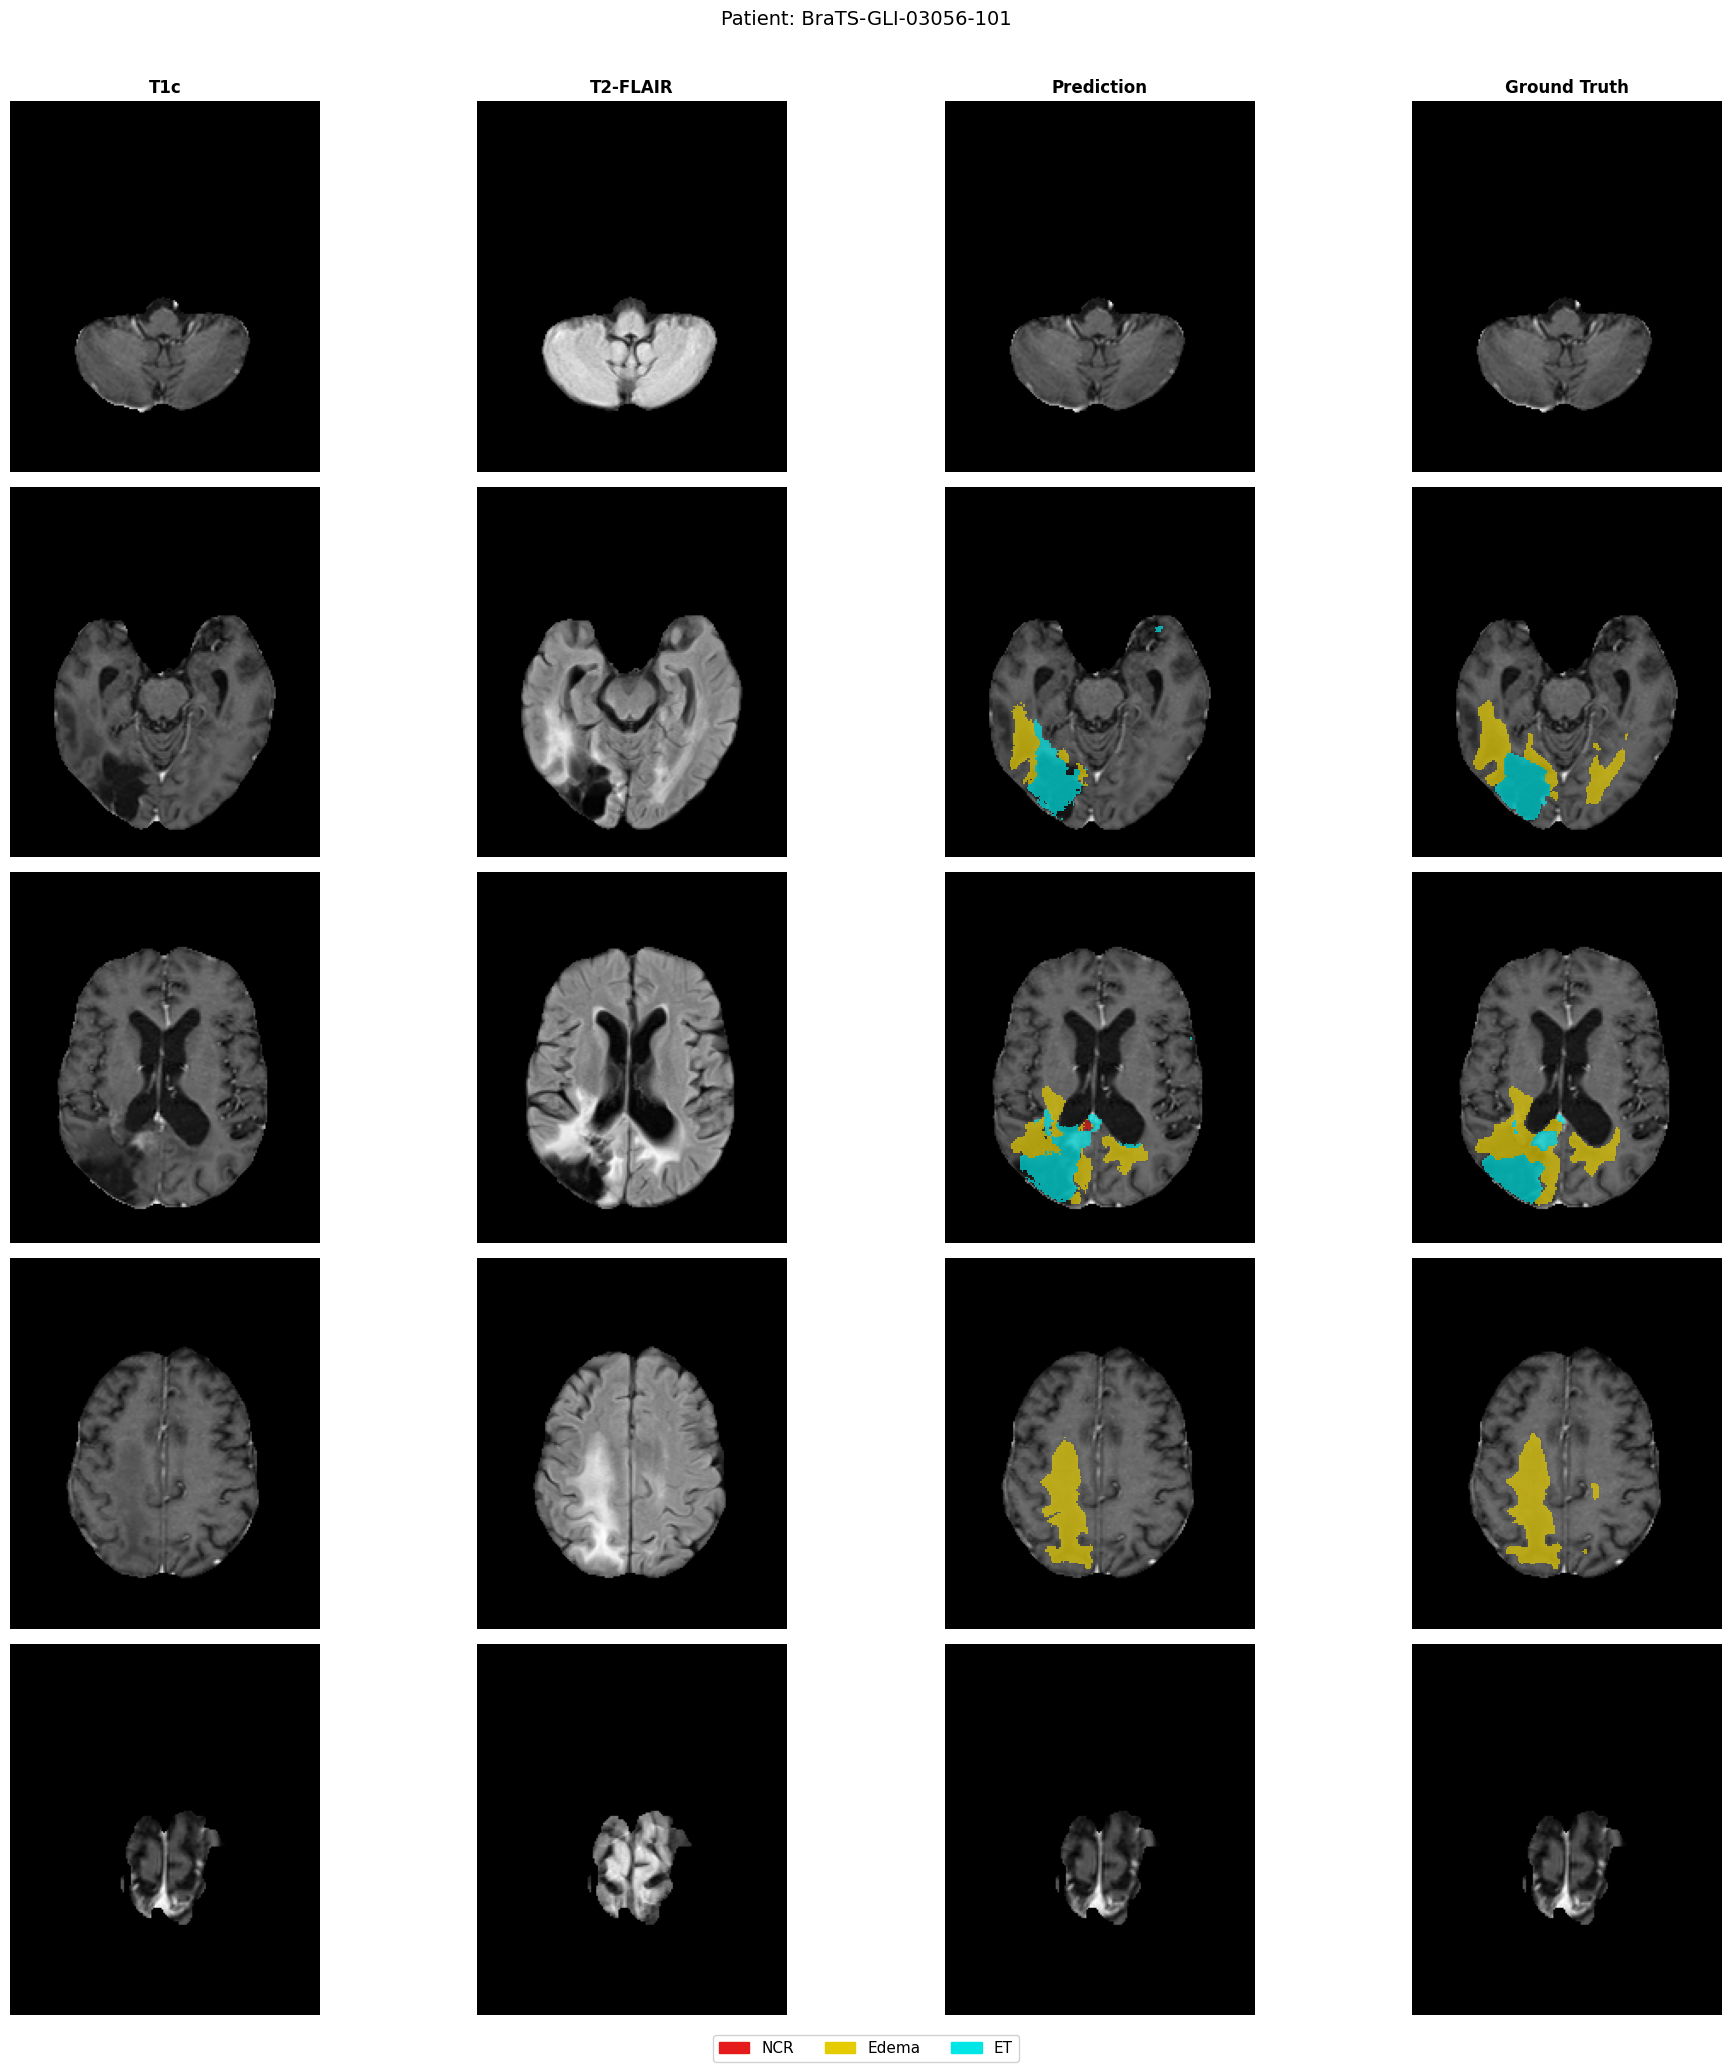


✅ Done.


In [3]:
# ============================================================
# inference — run this cell
# Set the two paths below, everything prints in cell output
# ============================================================

PATIENT_DIR = r"test\BraTS-GLI-03056-101"   # ← folder for one patient
MODEL_DIR   = r"D:\shashwat\models_phase2"               # ← folder containing pkl + npy

# ============================================================
import numpy as np
import nibabel as nib
import joblib
import os
import gc
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.ndimage import (uniform_filter, gaussian_filter,
                            sobel as nd_sobel,
                            label as nd_label,
                            laplace,
                            distance_transform_edt)
from skimage.filters import gabor_kernel
from sklearn.metrics import f1_score, jaccard_score

MODALITIES  = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX  = 'seg'
N_CLASSES   = 4
LABEL_NAMES = {0: 'Background', 1: 'NCR', 2: 'Edema', 3: 'ET'}
REGIONS     = {'WT': [1, 2, 3], 'TC': [1, 3], 'ET': [3]}
MRF_BETA       = 0.5
MRF_ITERATIONS = 5
SEG_COLORS = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [0.9, 0.1, 0.1, 0.7],
    [0.9, 0.8, 0.0, 0.7],
    [0.0, 0.9, 0.9, 0.7],
], dtype=np.float32)

# ============================================================
# STEP 1 — LOAD
# ============================================================
print("📂 Loading patient...")
patient_dir = Path(PATIENT_DIR)
pid         = patient_dir.name
data        = {}
affine      = None

for mod in MODALITIES + [SEG_SUFFIX]:
    matches = glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz"))
    if not matches:
        matches = glob.glob(str(patient_dir / f"*-{mod}.nii.gz"))
    if not matches:
        if mod == SEG_SUFFIX:
            data[mod] = None
            print(f"   {mod}: not found — Dice will be skipped")
            continue
        else:
            raise FileNotFoundError(f"Missing modality: {mod}")
    img        = nib.load(matches[0])
    data[mod]  = img.get_fdata(dtype=np.float32)
    if affine is None:
        affine = img.affine
    print(f"   {mod}: {data[mod].shape}")

# ============================================================
# STEP 2 — PREPROCESS
# ============================================================
print("\n⚙️  Preprocessing...")

brain_mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
for mod in MODALITIES:
    brain_mask |= (data[mod] > 0)
print(f"   Brain voxels : {brain_mask.sum():,}")

def zscore(vol, mask):
    v = vol.copy()
    roi = v[mask]
    v[mask]  = (roi - roi.mean()) / (roi.std() + 1e-8)
    v[~mask] = 0.0
    return v

proc = {}
for mod in MODALITIES:
    proc[mod] = zscore(data[mod], brain_mask)
proc[SEG_SUFFIX] = data[SEG_SUFFIX]

# ============================================================
# STEP 3 — FEATURE EXTRACTION
# ============================================================
print("\n🔧 Extracting features...")

def fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol**2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean**2, 0)).astype(np.float32)

def apply_gabor_3d(vol, kernel_2d):
    from scipy.ndimage import convolve
    return convolve(vol.astype(np.float32),
                    kernel_2d[:, :, np.newaxis],
                    mode='reflect').astype(np.float32)

def entropy_proxy(vol, size=5):
    lmean = uniform_filter(np.abs(vol).astype(np.float32), size=size)
    return (fast_local_std(vol, size) / (lmean + 1e-6)).astype(np.float32)

def distance_to_edge(mask):
    dist = distance_transform_edt(mask).astype(np.float32)
    return dist / (dist.max() + 1e-8)

gabor_kernels = [
    np.real(gabor_kernel(0.2, theta=t)).astype(np.float32)
    for t in [0, np.pi/4, np.pi/2, 3*np.pi/4]
]

cols      = []
dist_edge = distance_to_edge(brain_mask)

def add(vol):
    cols.append(vol[brain_mask].astype(np.float32))

for mod in MODALITIES:
    vol = proc[mod].astype(np.float32)
    add(vol.copy())
    for sz in [3, 5, 9, 15]:
        add(uniform_filter(vol, size=sz))
        add(fast_local_std(vol, size=sz))
    gx = nd_sobel(vol, axis=0)
    gy = nd_sobel(vol, axis=1)
    gz = nd_sobel(vol, axis=2)
    add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
    del gx, gy, gz
    add(np.abs(laplace(vol)).astype(np.float32))
    g1 = gaussian_filter(vol, sigma=1.0)
    g2 = gaussian_filter(vol, sigma=2.0)
    g3 = gaussian_filter(vol, sigma=3.0)
    add(g1); add(g2); add(g3)
    add((g1 - g2).astype(np.float32))
    add((g2 - g3).astype(np.float32))
    del g1, g2, g3
    for k in gabor_kernels:
        add(apply_gabor_3d(vol, k))
    add((vol - vol[::-1, :, :]).astype(np.float32))
    add(entropy_proxy(vol))
    add(dist_edge)
    del vol
    gc.collect()

shape = proc[MODALITIES[0]].shape
cx, cy, cz = [s/2 for s in shape]
xx, yy, zz = np.meshgrid(
    np.linspace(0, 1, shape[0], dtype=np.float32),
    np.linspace(0, 1, shape[1], dtype=np.float32),
    np.linspace(0, 1, shape[2], dtype=np.float32),
    indexing='ij')
add(xx); add(yy); add(zz)
xn = (np.arange(shape[0], dtype=np.float32) - cx) / (cx + 1e-8)
yn = (np.arange(shape[1], dtype=np.float32) - cy) / (cy + 1e-8)
zn = (np.arange(shape[2], dtype=np.float32) - cz) / (cz + 1e-8)
add(np.sqrt(xn[:,None,None]**2 + yn[None,:,None]**2 + zn[None,None,:]**2
            ).astype(np.float32))
del xx, yy, zz; gc.collect()

eps = 1e-8
t1c = proc['t1c'].astype(np.float32)
t1n = proc['t1n'].astype(np.float32)
t2f = proc['t2f'].astype(np.float32)
t2w = proc['t2w'].astype(np.float32)
add(np.clip(t2w / (t1c + eps), -10, 10))
add(np.clip(t2f / (t1n + eps), -10, 10))
add(t2f - t1c);  add(t2w - t1n);  add(t1c - t1n)
add(t2f - t2w);  add(t1c - t2f);  add(t1c - t2w)
add(np.clip(t1c / (t2f + eps), -10, 10))
add(gaussian_filter((t1c - t1n).astype(np.float32), sigma=1.5))
add(np.clip(t2f / (t2w + eps), -10, 10))
add((t1c * t2f) / (np.abs(t1c * t2f).max() + eps))
add((t1n * t2w) / (np.abs(t1n * t2w).max() + eps))
del t1c, t1n, t2f, t2w; gc.collect()

X = np.column_stack(cols).astype(np.float32)
del cols; gc.collect()
print(f"   Feature matrix : {X.shape}")

# ============================================================
# STEP 4 — XGBOOST INFERENCE
# ============================================================
print("\n📦 Loading model...")
xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_final_phase2.pkl"))
print("   ✅ Model loaded")

cfg_path = os.path.join(MODEL_DIR, "best_config.npy")
if os.path.exists(cfg_path):
    cfg = np.load(cfg_path, allow_pickle=True).item()
    print(f"   ✅ Config loaded")
else:
    cfg = {'wt_threshold': 0.35,
           'boost': np.array([1.0, 2.5, 1.0, 2.0], np.float32)}
    print("   ⚠️  Config not found — using defaults")

print(f"   WT threshold : {cfg['wt_threshold']}")
print(f"   Boost        : {cfg['boost']}")

print("\n🚀 Running inference...")
BATCH = 500_000
proba_parts = []
for s in range(0, len(X), BATCH):
    e = min(s + BATCH, len(X))
    proba_parts.append(
        xgb_model.predict_proba(X[s:e]).astype(np.float32))
    print(f"   voxels {s:,} → {e:,} done")
proba_flat = np.concatenate(proba_parts)
del X; gc.collect()

# ============================================================
# STEP 5 — MRF POST-PROCESSING
# ============================================================
print("\n🧠 MRF smoothing...")

_COMPAT = np.array([
    [ 0.0, -1.0, -0.5, -1.0],
    [-1.0,  0.0, -0.8,  0.0],
    [-0.5, -0.8,  0.0, -0.8],
    [-1.0,  0.0, -0.8,  0.0],
], dtype=np.float32)

# reshape flat → volume
proba_vol = np.zeros((N_CLASSES, *shape), dtype=np.float32)
for c in range(N_CLASSES):
    v = np.zeros(shape, dtype=np.float32)
    v[brain_mask] = proba_flat[:, c]
    proba_vol[c]  = v

# boost
boost = np.array(cfg['boost'], dtype=np.float32)
proba_vol *= boost[:, None, None, None]
proba_vol /= proba_vol.sum(axis=0, keepdims=True) + 1e-8

# mean-field iterations
unary = np.log(np.clip(proba_vol, 1e-6, 1.0))
q     = proba_vol.copy()
for it in range(MRF_ITERATIONS):
    q_sm = np.stack([
        gaussian_filter(q[c].astype(np.float64), sigma=1.0).astype(np.float32)
        for c in range(N_CLASSES)])
    msg   = np.einsum('cd,dxyz->cxyz', _COMPAT, q_sm)
    log_q = unary - MRF_BETA * msg
    log_q -= log_q.max(axis=0, keepdims=True)
    q      = np.exp(log_q)
    q     /= q.sum(axis=0, keepdims=True) + 1e-8
    print(f"   MRF iter {it+1}/{MRF_ITERATIONS}")
proba_vol = q

# argmax + WT threshold
pred_vol = proba_vol.argmax(axis=0).astype(np.int8)
prob_tumor = proba_vol[[1,2,3]].sum(axis=0)
pred_vol[prob_tumor < cfg['wt_threshold']] = 0
pred_vol[~brain_mask] = 0

# remove small blobs
for lbl in [3, 1, 2]:
    binary = (pred_vol == lbl).astype(np.uint8)
    labeled, n_comp = nd_label(binary)
    for cid in range(1, n_comp + 1):
        if (labeled == cid).sum() < 200:
            pred_vol[labeled == cid] = 0

del proba_flat; gc.collect()

# ============================================================
# STEP 6 — PRINT RESULTS
# ============================================================
print(f"\n{'='*46}")
print(f"  Results for patient: {pid}")
print(f"{'='*46}")

print(f"\n── Predicted voxel counts ──────────────────────────")
for lbl, name in LABEL_NAMES.items():
    n = int((pred_vol == lbl).sum())
    print(f"   {lbl} {name:<12}: {n:>8,} voxels")

if proc[SEG_SUFFIX] is not None:
    gt = proc[SEG_SUFFIX].astype(np.int8)
    gt[gt == 4] = 3
    y_true = gt[brain_mask]
    y_pred = pred_vol[brain_mask]

    print(f"\n── Dice / IoU ──────────────────────────────────────")
    for region, labels in REGIONS.items():
        gt_r   = np.isin(y_true, labels).astype(np.uint8)
        pred_r = np.isin(y_pred, labels).astype(np.uint8)
        dice   = f1_score(gt_r, pred_r, zero_division=0)
        iou    = jaccard_score(gt_r, pred_r, zero_division=0)
        print(f"   {region}  Dice={dice:.4f}  IoU={iou:.4f}")

    print(f"\n── Per-label GT vs Pred ────────────────────────────")
    print(f"   {'Label':<12} {'GT':>10} {'Pred':>10}")
    for lbl, name in LABEL_NAMES.items():
        print(f"   {name:<12} {int((y_true==lbl).sum()):>10,} "
              f"{int((y_pred==lbl).sum()):>10,}")

# ============================================================
# STEP 7 — VISUALISE IN CELL OUTPUT
# ============================================================
print("\n📊 Plotting...")

def norm(img):
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-8)

def label_to_rgba(lslice):
    rgba = np.zeros((*lslice.shape, 4), dtype=np.float32)
    for lbl in range(N_CLASSES):
        rgba[lslice == lbl] = SEG_COLORS[lbl]
    return rgba

has_gt   = proc[SEG_SUFFIX] is not None
n_cols   = 4 if has_gt else 3
n_slices = 5

z_indices = np.linspace(shape[2] * 0.2,
                         shape[2] * 0.8,
                         n_slices, dtype=int)

fig, axes = plt.subplots(n_slices, n_cols,
                          figsize=(5 * n_cols, 4 * n_slices))
fig.suptitle(f"Patient: {pid}", fontsize=14, y=1.01)

col_titles = ['T1c', 'T2-FLAIR', 'Prediction']
if has_gt:
    col_titles.append('Ground Truth')
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

for row, z in enumerate(z_indices):
    t1c_sl  = data['t1c'][:, :, z]
    t2f_sl  = data['t2f'][:, :, z]
    pred_sl = pred_vol[:, :, z]

    axes[row, 0].imshow(norm(t1c_sl).T,  cmap='gray', origin='lower')
    axes[row, 0].set_ylabel(f"z={z}", fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(norm(t2f_sl).T,  cmap='gray', origin='lower')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(norm(t1c_sl).T,  cmap='gray', origin='lower')
    axes[row, 2].imshow(label_to_rgba(pred_sl).transpose(1, 0, 2),
                         origin='lower', interpolation='none')
    axes[row, 2].axis('off')

    if has_gt:
        gt_sl = gt[:, :, z]
        axes[row, 3].imshow(norm(t1c_sl).T, cmap='gray', origin='lower')
        axes[row, 3].imshow(label_to_rgba(gt_sl).transpose(1, 0, 2),
                             origin='lower', interpolation='none')
        axes[row, 3].axis('off')

patches = [
    mpatches.Patch(color=SEG_COLORS[1,:3], label='NCR'),
    mpatches.Patch(color=SEG_COLORS[2,:3], label='Edema'),
    mpatches.Patch(color=SEG_COLORS[3,:3], label='ET'),
]
fig.legend(handles=patches, loc='lower center',
           ncol=3, fontsize=11, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

print("\n✅ Done.")

📦 Loading model and config...
   ✅ Model loaded
   ✅ Config loaded
   WT threshold : 0.1
   Boost        : [1.  1.5 1.  1.5]
   MRF iters    : 2

📁 Train patients : 1012
   Test  patients : 136
   Total          : 1148
🔄 Starting clean evaluation from scratch...

── Evaluating TRAIN (1012 patients) ──────────────


train:   2%|▏         | 25/1012 [19:47<13:50:15, 50.47s/it]

   💾 Checkpoint saved (25 done) | elapsed 20 min | ~781 min remaining


train:   5%|▍         | 50/1012 [39:52<13:30:40, 50.56s/it]

   💾 Checkpoint saved (50 done) | elapsed 40 min | ~767 min remaining


...

   💾 Checkpoint saved (100 done) | elapsed 76 min | ~27 min remaining


test:  92%|█████████▏| 125/136 [1:34:18<08:13, 44.89s/it]

   💾 Checkpoint saved (125 done) | elapsed 94 min | ~8 min remaining


test: 100%|██████████| 136/136 [1:42:31<00:00, 45.23s/it]
C:\Users\Student\AppData\Local\Temp\ipykernel_25200\482113153.py:382: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tr_vals, te_vals],
C:\Users\Student\AppData\Local\Temp\ipykernel_25200\482113153.py:382: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tr_vals, te_vals],
C:\Users\Student\AppData\Local\Temp\ipykernel_25200\482113153.py:382: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tr_vals, te_vals],
C:\Users\Student\AppData\Local\Temp\ipykernel_25200\482113153.py:382: MatplotlibDeprecationWarning: The 'labels' parameter of 

   ✅ test done in 102.5 min

💾 Final results saved → D:\shashwat\eval_results.csv
   Total patients evaluated : 1148

  TRAIN  (1012 patients)
  Metric           Mean      Std   Median      Min      Max
  ----------------------------------------------------------
  WT_dice        0.8347   0.1213   0.8669   0.0000   0.9716
  TC_dice        0.7250   0.2302   0.8111   0.0000   0.9683
  ET_dice        0.7202   0.2329   0.8087   0.0000   0.9683
  WT_iou         0.7314   0.1478   0.7650   0.0000   0.9448
  TC_iou         0.6101   0.2335   0.6822   0.0000   0.9386
  ET_iou         0.6046   0.2345   0.6788   0.0000   0.9386

  TEST  (136 patients)
  Metric           Mean      Std   Median      Min      Max
  ----------------------------------------------------------
  WT_dice        0.8283   0.1421   0.8625   0.0000   0.9706
  TC_dice        0.6842   0.2577   0.7996   0.0000   0.9633
  ET_dice        0.6780   0.2640   0.7913   0.0000   0.9633
  WT_iou         0.7255   0.1574   0.7582   0.0000 

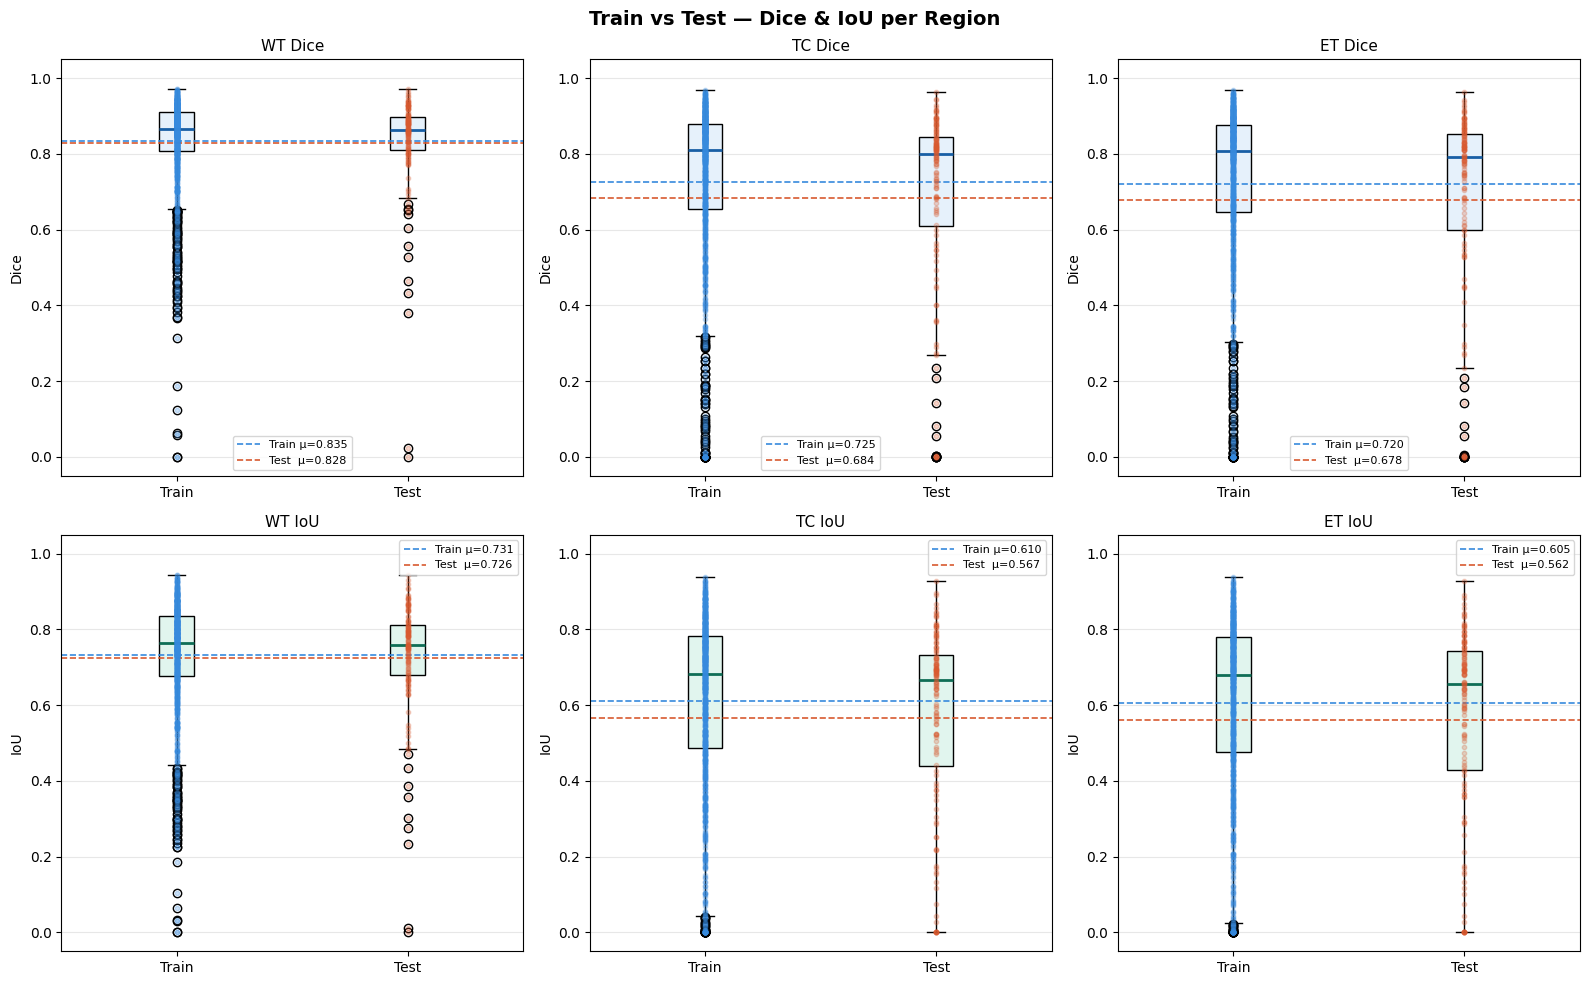

📊 Boxplots saved → D:\shashwat\models_phase2\eval_boxplots.png


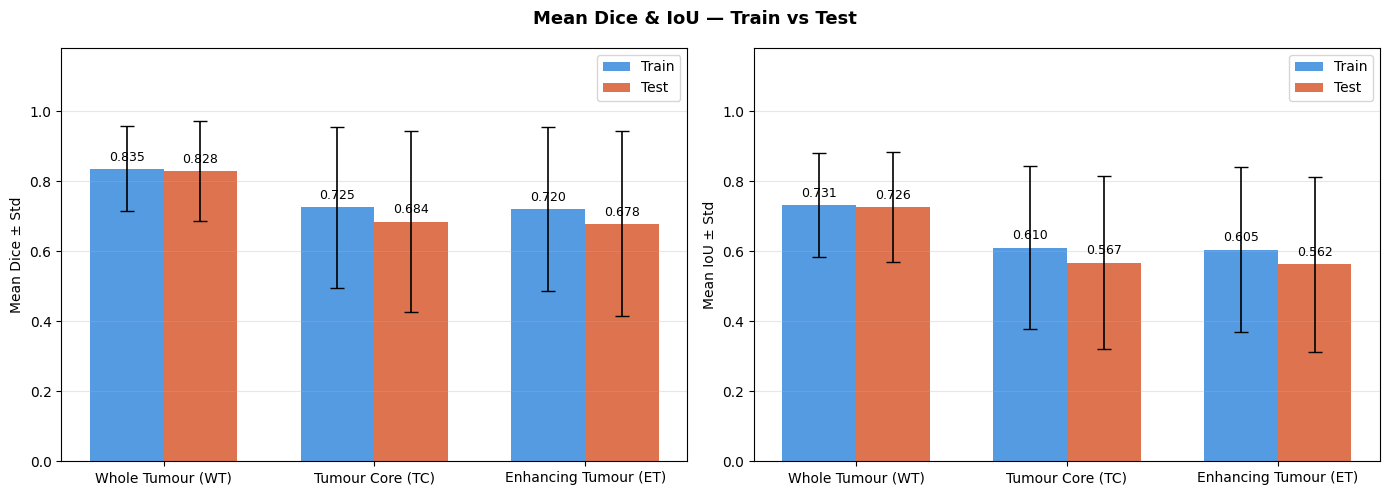

📊 Bar chart saved → D:\shashwat\models_phase2\eval_barchart.png


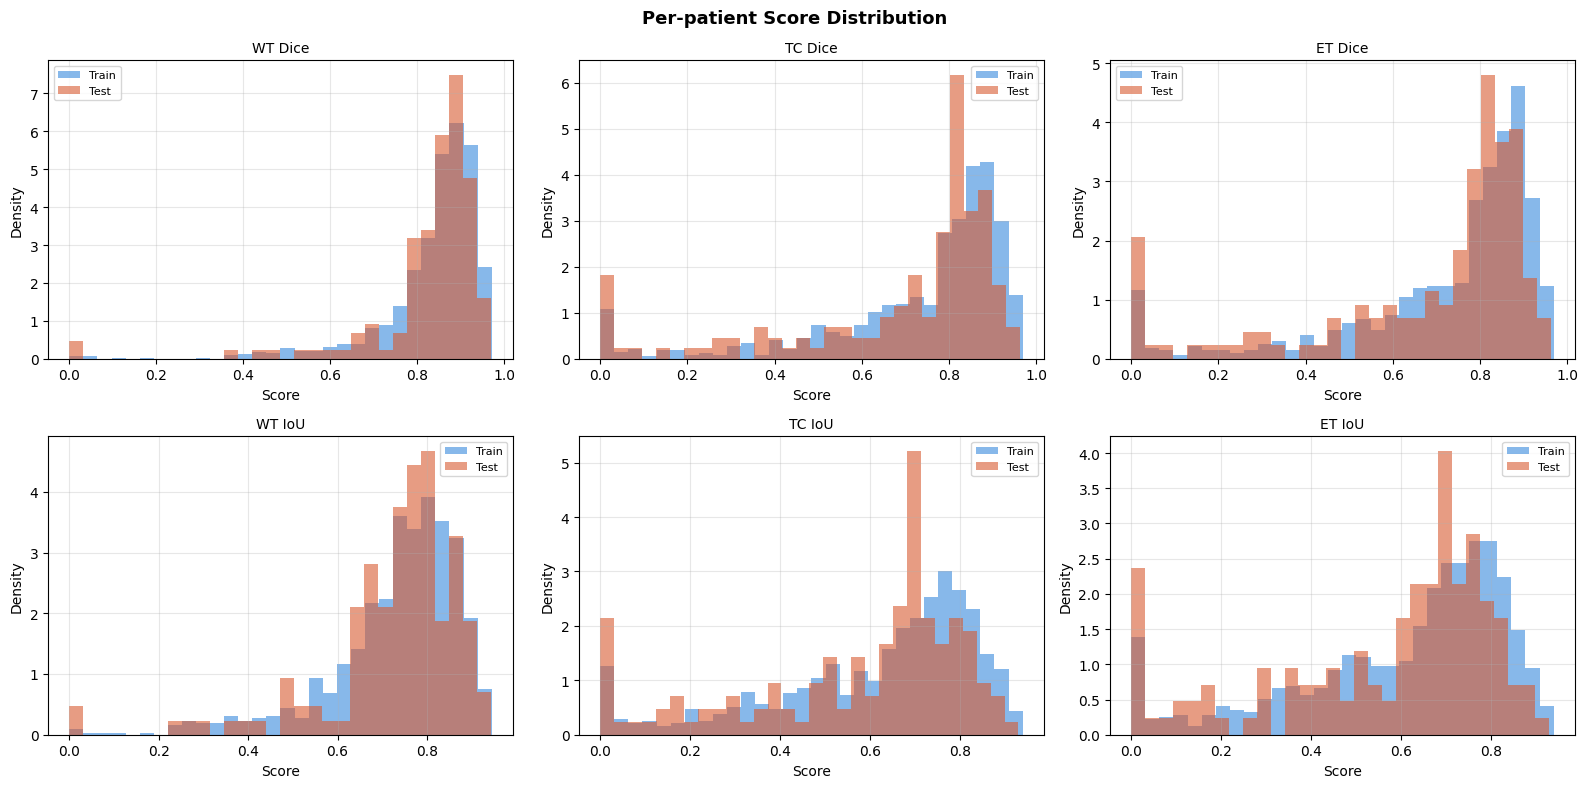

📊 Histograms saved → D:\shashwat\models_phase2\eval_histograms.png

✅ Evaluation complete.


In [1]:
# ============================================================
# BATCH EVALUATION — Train vs Test Dice/IoU comparison
# All 1012 train + 200 test patients, MRF=2 iterations
# CLEAN RESTART VERSION — ignores any previous checkpoint
# ============================================================

TRAIN_DIR   = r"D:\shashwat\train"
TEST_DIR    = r"D:\shashwat\test"
MODEL_DIR   = r"D:\shashwat\models_phase2"
OUTPUT_CSV  = r"D:\shashwat\eval_results.csv"

# ============================================================
import numpy as np
import nibabel as nib
import joblib
import os
import gc
import glob
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import (uniform_filter, gaussian_filter,
                            sobel as nd_sobel,
                            label as nd_label,
                            laplace,
                            distance_transform_edt)
from skimage.filters import gabor_kernel
from sklearn.metrics import f1_score, jaccard_score
import time

MODALITIES     = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX     = 'seg'
N_CLASSES      = 4
REGIONS        = {'WT': [1, 2, 3], 'TC': [1, 3], 'ET': [3]}
MRF_BETA       = 0.5
MRF_ITERATIONS = 2

# ============================================================
# LOAD MODEL + CONFIG
# ============================================================
print("📦 Loading model and config...")
xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_final_phase2.pkl"))
print("   ✅ Model loaded")

cfg_path = os.path.join(MODEL_DIR, "best_config.npy")
if os.path.exists(cfg_path):
    cfg = np.load(cfg_path, allow_pickle=True).item()
    print("   ✅ Config loaded")
else:
    cfg = {'wt_threshold': 0.35,
           'boost': np.array([1.0, 2.5, 1.0, 2.0], np.float32)}
    print("   ⚠️  Config not found — using defaults")

print(f"   WT threshold : {cfg['wt_threshold']}")
print(f"   Boost        : {cfg['boost']}")
print(f"   MRF iters    : {MRF_ITERATIONS}")

# ============================================================
# HELPER FUNCTIONS
# ============================================================
gabor_kernels = [
    np.real(gabor_kernel(0.2, theta=t)).astype(np.float32)
    for t in [0, np.pi/4, np.pi/2, 3*np.pi/4]
]

def fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol**2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean**2, 0)).astype(np.float32)

def apply_gabor_3d(vol, kernel_2d):
    from scipy.ndimage import convolve
    return convolve(vol.astype(np.float32),
                    kernel_2d[:, :, np.newaxis],
                    mode='reflect').astype(np.float32)

def entropy_proxy(vol, size=5):
    lmean = uniform_filter(np.abs(vol).astype(np.float32), size=size)
    return (fast_local_std(vol, size) / (lmean + 1e-6)).astype(np.float32)

def distance_to_edge(mask):
    dist = distance_transform_edt(mask).astype(np.float32)
    return dist / (dist.max() + 1e-8)

def zscore(vol, mask):
    v = vol.copy()
    roi = v[mask]
    v[mask]  = (roi - roi.mean()) / (roi.std() + 1e-8)
    v[~mask] = 0.0
    return v

def extract_features(proc, brain_mask):
    cols = []
    dist_edge = distance_to_edge(brain_mask)

    def add(vol):
        cols.append(vol[brain_mask].astype(np.float32))

    for mod in MODALITIES:
        vol = proc[mod].astype(np.float32)
        add(vol.copy())
        for sz in [3, 5, 9, 15]:
            add(uniform_filter(vol, size=sz))
            add(fast_local_std(vol, size=sz))
        gx = nd_sobel(vol, axis=0)
        gy = nd_sobel(vol, axis=1)
        gz = nd_sobel(vol, axis=2)
        add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
        del gx, gy, gz
        add(np.abs(laplace(vol)).astype(np.float32))
        g1 = gaussian_filter(vol, sigma=1.0)
        g2 = gaussian_filter(vol, sigma=2.0)
        g3 = gaussian_filter(vol, sigma=3.0)
        add(g1); add(g2); add(g3)
        add((g1 - g2).astype(np.float32))
        add((g2 - g3).astype(np.float32))
        del g1, g2, g3
        for k in gabor_kernels:
            add(apply_gabor_3d(vol, k))
        add((vol - vol[::-1, :, :]).astype(np.float32))
        add(entropy_proxy(vol))
        add(dist_edge)
        del vol
        gc.collect()

    shape = proc[MODALITIES[0]].shape
    cx, cy, cz = [s/2 for s in shape]
    xx, yy, zz = np.meshgrid(
        np.linspace(0, 1, shape[0], dtype=np.float32),
        np.linspace(0, 1, shape[1], dtype=np.float32),
        np.linspace(0, 1, shape[2], dtype=np.float32),
        indexing='ij')
    add(xx); add(yy); add(zz)
    xn = (np.arange(shape[0], dtype=np.float32) - cx) / (cx + 1e-8)
    yn = (np.arange(shape[1], dtype=np.float32) - cy) / (cy + 1e-8)
    zn = (np.arange(shape[2], dtype=np.float32) - cz) / (cz + 1e-8)
    add(np.sqrt(xn[:,None,None]**2 + yn[None,:,None]**2 + zn[None,None,:]**2
                ).astype(np.float32))
    del xx, yy, zz; gc.collect()

    eps = 1e-8
    t1c = proc['t1c'].astype(np.float32)
    t1n = proc['t1n'].astype(np.float32)
    t2f = proc['t2f'].astype(np.float32)
    t2w = proc['t2w'].astype(np.float32)
    add(np.clip(t2w / (t1c + eps), -10, 10))
    add(np.clip(t2f / (t1n + eps), -10, 10))
    add(t2f - t1c);  add(t2w - t1n);  add(t1c - t1n)
    add(t2f - t2w);  add(t1c - t2f);  add(t1c - t2w)
    add(np.clip(t1c / (t2f + eps), -10, 10))
    add(gaussian_filter((t1c - t1n).astype(np.float32), sigma=1.5))
    add(np.clip(t2f / (t2w + eps), -10, 10))
    add((t1c * t2f) / (np.abs(t1c * t2f).max() + eps))
    add((t1n * t2w) / (np.abs(t1n * t2w).max() + eps))
    del t1c, t1n, t2f, t2w; gc.collect()

    return np.column_stack(cols).astype(np.float32)


_COMPAT = np.array([
    [ 0.0, -1.0, -0.5, -1.0],
    [-1.0,  0.0, -0.8,  0.0],
    [-0.5, -0.8,  0.0, -0.8],
    [-1.0,  0.0, -0.8,  0.0],
], dtype=np.float32)


def run_patient(patient_dir):
    patient_dir = Path(patient_dir)
    pid  = patient_dir.name
    data = {}

    for mod in MODALITIES + [SEG_SUFFIX]:
        matches = glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz"))
        if not matches:
            matches = glob.glob(str(patient_dir / f"*-{mod}.nii.gz"))
        if not matches:
            if mod == SEG_SUFFIX:
                return None
            raise FileNotFoundError(f"{pid}: missing {mod}")
        data[mod] = nib.load(matches[0]).get_fdata(dtype=np.float32)

    brain_mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
    for mod in MODALITIES:
        brain_mask |= (data[mod] > 0)

    proc  = {mod: zscore(data[mod], brain_mask) for mod in MODALITIES}
    shape = proc[MODALITIES[0]].shape

    X = extract_features(proc, brain_mask)
    del proc; gc.collect()

    BATCH = 500_000
    proba_parts = []
    for s in range(0, len(X), BATCH):
        proba_parts.append(
            xgb_model.predict_proba(X[s:s+BATCH]).astype(np.float32))
    proba_flat = np.concatenate(proba_parts)
    del X; gc.collect()

    proba_vol = np.zeros((N_CLASSES, *shape), dtype=np.float32)
    for c in range(N_CLASSES):
        v = np.zeros(shape, dtype=np.float32)
        v[brain_mask] = proba_flat[:, c]
        proba_vol[c]  = v

    boost = np.array(cfg['boost'], dtype=np.float32)
    proba_vol *= boost[:, None, None, None]
    proba_vol /= proba_vol.sum(axis=0, keepdims=True) + 1e-8

    unary = np.log(np.clip(proba_vol, 1e-6, 1.0))
    q = proba_vol.copy()
    for _ in range(MRF_ITERATIONS):
        q_sm  = np.stack([
            gaussian_filter(q[c].astype(np.float64), sigma=1.0).astype(np.float32)
            for c in range(N_CLASSES)])
        msg   = np.einsum('cd,dxyz->cxyz', _COMPAT, q_sm)
        log_q = unary - MRF_BETA * msg
        log_q -= log_q.max(axis=0, keepdims=True)
        q      = np.exp(log_q)
        q     /= q.sum(axis=0, keepdims=True) + 1e-8
    proba_vol = q

    pred_vol   = proba_vol.argmax(axis=0).astype(np.int8)
    prob_tumor = proba_vol[[1,2,3]].sum(axis=0)
    pred_vol[prob_tumor < cfg['wt_threshold']] = 0
    pred_vol[~brain_mask] = 0

    for lbl in [3, 1, 2]:
        binary          = (pred_vol == lbl).astype(np.uint8)
        labeled, n_comp = nd_label(binary)
        for cid in range(1, n_comp + 1):
            if (labeled == cid).sum() < 200:
                pred_vol[labeled == cid] = 0

    del proba_flat; gc.collect()

    gt = data[SEG_SUFFIX].astype(np.int8)
    gt[gt == 4] = 3
    y_true = gt[brain_mask]
    y_pred = pred_vol[brain_mask]

    row = {'patient': pid}
    for region, labels in REGIONS.items():
        gt_r   = np.isin(y_true, labels).astype(np.uint8)
        pred_r = np.isin(y_pred, labels).astype(np.uint8)
        row[f'{region}_dice'] = float(f1_score(gt_r, pred_r, zero_division=0))
        row[f'{region}_iou']  = float(jaccard_score(gt_r, pred_r, zero_division=0))

    return row


# ============================================================
# COLLECT PATIENT DIRS
# ============================================================
def get_patient_dirs(root):
    return sorted([d for d in Path(root).iterdir() if d.is_dir()])

train_dirs = get_patient_dirs(TRAIN_DIR)
test_dirs  = get_patient_dirs(TEST_DIR)

print(f"\n📁 Train patients : {len(train_dirs)}")
print(f"   Test  patients : {len(test_dirs)}")
print(f"   Total          : {len(train_dirs) + len(test_dirs)}")

# ============================================================
# CLEAN RESTART — delete existing CSV and start fresh
# ============================================================
if os.path.exists(OUTPUT_CSV):
    os.remove(OUTPUT_CSV)
    print(f"\n🗑️  Deleted existing checkpoint: {OUTPUT_CSV}")

all_rows = []
failed   = []
done_patients = set()

print("🔄 Starting clean evaluation from scratch...\n")

# ============================================================
# RUN EVALUATION — with live CSV checkpointing every 25 patients
# ============================================================
CHECKPOINT_EVERY = 25

def eval_split(dirs, split_name):
    t0 = time.time()
    done_count = 0
    for i, pdir in enumerate(tqdm(dirs, desc=split_name)):
        pid = Path(pdir).name
        try:
            row = run_patient(pdir)
            if row:
                row['split'] = split_name.lower()
                all_rows.append(row)
                done_patients.add(pid)
                done_count += 1
        except Exception as e:
            failed.append((pid, str(e)))
            tqdm.write(f"⚠️  {pid}: {e}")

        if done_count > 0 and done_count % CHECKPOINT_EVERY == 0:
            pd.DataFrame(all_rows).to_csv(OUTPUT_CSV, index=False)
            elapsed   = (time.time() - t0) / 60
            remaining = (elapsed / done_count) * (len(dirs) - i - 1)
            tqdm.write(f"   💾 Checkpoint saved ({done_count} done) | "
                       f"elapsed {elapsed:.0f} min | "
                       f"~{remaining:.0f} min remaining")

    pd.DataFrame(all_rows).to_csv(OUTPUT_CSV, index=False)
    elapsed = (time.time() - t0) / 60
    print(f"   ✅ {split_name} done in {elapsed:.1f} min")

print(f"── Evaluating TRAIN ({len(train_dirs)} patients) ──────────────")
eval_split(train_dirs, "train")

print(f"\n── Evaluating TEST ({len(test_dirs)} patients) ───────────────")
eval_split(test_dirs, "test")

# ============================================================
# FINAL SAVE + FAILURE REPORT
# ============================================================
df = pd.DataFrame(all_rows)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\n💾 Final results saved → {OUTPUT_CSV}")
print(f"   Total patients evaluated : {len(df)}")

if failed:
    print(f"\n⚠️  {len(failed)} patients failed:")
    for pid, err in failed:
        print(f"   {pid}: {err}")

# ============================================================
# SUMMARY STATS
# ============================================================
metrics  = ['WT_dice', 'TC_dice', 'ET_dice', 'WT_iou', 'TC_iou', 'ET_iou']
df_train = df[df['split'] == 'train']
df_test  = df[df['split'] == 'test']

def summary(split_df, label):
    print(f"\n{'='*58}")
    print(f"  {label}  ({len(split_df)} patients)")
    print(f"{'='*58}")
    print(f"  {'Metric':<12} {'Mean':>8} {'Std':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'-'*58}")
    for m in metrics:
        v = split_df[m]
        print(f"  {m:<12} {v.mean():>8.4f} {v.std():>8.4f} "
              f"{v.median():>8.4f} {v.min():>8.4f} {v.max():>8.4f}")

summary(df_train, "TRAIN")
summary(df_test,  "TEST")

print(f"\n{'='*58}")
print(f"  TRAIN vs TEST COMPARISON")
print(f"{'='*58}")
print(f"  {'Metric':<12} {'Train':>10} {'Test':>10} {'Gap (T-t)':>12} {'Overfit?':>10}")
print(f"  {'-'*58}")
for m in metrics:
    tr   = df_train[m].mean()
    te   = df_test[m].mean()
    gap  = tr - te
    flag = '⚠️  yes' if gap > 0.05 else '✅  no'
    print(f"  {m:<12} {tr:>10.4f} {te:>10.4f} {gap:>+12.4f} {flag:>10}")

# ============================================================
# PLOTS
# ============================================================
colors  = {'train': '#378ADD', 'test': '#D85A30'}
regions = ['WT', 'TC', 'ET']

# ── Boxplot grid ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Train vs Test — Dice & IoU per Region", fontsize=14, fontweight='bold')

for col, region in enumerate(regions):
    for row, metric in enumerate(['dice', 'iou']):
        ax  = axes[row, col]
        key = f'{region}_{metric}'
        tr_vals = df_train[key].dropna().values
        te_vals = df_test[key].dropna().values

        ax.boxplot([tr_vals, te_vals],
                   labels=['Train', 'Test'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#E6F1FB' if metric=='dice' else '#E1F5EE'),
                   medianprops=dict(color='#185FA5' if metric=='dice' else '#0F6E56',
                                    linewidth=2),
                   whiskerprops=dict(linewidth=1),
                   capprops=dict(linewidth=1))

        ax.scatter([1]*len(tr_vals), tr_vals,
                   alpha=0.25, s=10, color=colors['train'], zorder=3)
        ax.scatter([2]*len(te_vals), te_vals,
                   alpha=0.25, s=10, color=colors['test'], zorder=3)
        ax.axhline(np.mean(tr_vals), color=colors['train'],
                   linestyle='--', linewidth=1.2,
                   label=f'Train μ={np.mean(tr_vals):.3f}')
        ax.axhline(np.mean(te_vals), color=colors['test'],
                   linestyle='--', linewidth=1.2,
                   label=f'Test  μ={np.mean(te_vals):.3f}')
        ax.set_title(f'{region} {"Dice" if metric=="dice" else "IoU"}', fontsize=11)
        ax.set_ylabel('Dice' if metric == 'dice' else 'IoU')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
boxplot_path = os.path.join(MODEL_DIR, "eval_boxplots.png")
plt.savefig(boxplot_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"📊 Boxplots saved → {boxplot_path}")

# ── Bar chart ─────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Mean Dice & IoU — Train vs Test", fontsize=13, fontweight='bold')

for ax, metric, ylabel in zip(axes2, ['dice', 'iou'], ['Mean Dice ± Std', 'Mean IoU ± Std']):
    x     = np.arange(len(regions))
    width = 0.35
    tr_m  = [df_train[f'{r}_{metric}'].mean() for r in regions]
    te_m  = [df_test[f'{r}_{metric}'].mean()  for r in regions]
    tr_s  = [df_train[f'{r}_{metric}'].std()  for r in regions]
    te_s  = [df_test[f'{r}_{metric}'].std()   for r in regions]

    b1 = ax.bar(x - width/2, tr_m, width, yerr=tr_s,
                label='Train', color='#378ADD', alpha=0.85,
                capsize=5, error_kw={'linewidth': 1.2})
    b2 = ax.bar(x + width/2, te_m, width, yerr=te_s,
                label='Test',  color='#D85A30', alpha=0.85,
                capsize=5, error_kw={'linewidth': 1.2})

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.015,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(['Whole Tumour (WT)', 'Tumour Core (TC)', 'Enhancing Tumour (ET)'])
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.18)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
bar_path = os.path.join(MODEL_DIR, "eval_barchart.png")
plt.savefig(bar_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"📊 Bar chart saved → {bar_path}")

# ── Histograms ────────────────────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(16, 8))
fig3.suptitle("Per-patient Score Distribution", fontsize=13, fontweight='bold')

for col, region in enumerate(regions):
    for row, metric in enumerate(['dice', 'iou']):
        ax  = axes3[row, col]
        key = f'{region}_{metric}'
        ax.hist(df_train[key].dropna(), bins=30, alpha=0.6,
                color=colors['train'], label='Train', density=True)
        ax.hist(df_test[key].dropna(),  bins=30, alpha=0.6,
                color=colors['test'],  label='Test',  density=True)
        ax.set_title(f'{region} {"Dice" if metric=="dice" else "IoU"}', fontsize=10)
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
hist_path = os.path.join(MODEL_DIR, "eval_histograms.png")
plt.savefig(hist_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"📊 Histograms saved → {hist_path}")

print("\n✅ Evaluation complete.")

## T2-Flair Modality Train and Test Prediction complete 

📦 Loading model...


   ✅  WT threshold=0.52  boost=[1.  1.5 1.  1.5]
   📋 Created checkpoint file: checkpoint_scores.xlsx
   📂 Checkpoint file: checkpoint_scores.xlsx

  Split: TRAIN  |  1012 patients  |  train

  [train] (1/1012) BraTS-GLI-00005-100
    WT  Dice=0.8408  IoU=0.7253
    TC  Dice=0.6044  IoU=0.4331
    ET  Dice=0.6044  IoU=0.4331
    💾 Checkpoint saved → checkpoint_scores.xlsx

  [train] (2/1012) BraTS-GLI-00006-100
    WT  Dice=0.8957  IoU=0.8111
    TC  Dice=0.9047  IoU=0.8260
    ET  Dice=0.9047  IoU=0.8260
    💾 Checkpoint saved → checkpoint_scores.xlsx

  [train] (3/1012) BraTS-GLI-00006-101
    WT  Dice=0.8676  IoU=0.7661
    TC  Dice=0.8871  IoU=0.7970
    ET  Dice=0.8871  IoU=0.7970
    💾 Checkpoint saved → checkpoint_scores.xlsx

  [train] (4/1012) BraTS-GLI-00008-101
    WT  Dice=0.7378  IoU=0.5845
    TC  Dice=0.3193  IoU=0.1900
    ET  Dice=0.3193  IoU=0.1900
    💾 Checkpoint saved → checkpoint_scores.xlsx

  [train] (5/1012) BraTS-GLI-00008-103
    WT  Dice=0.7985  IoU=0.6646
 

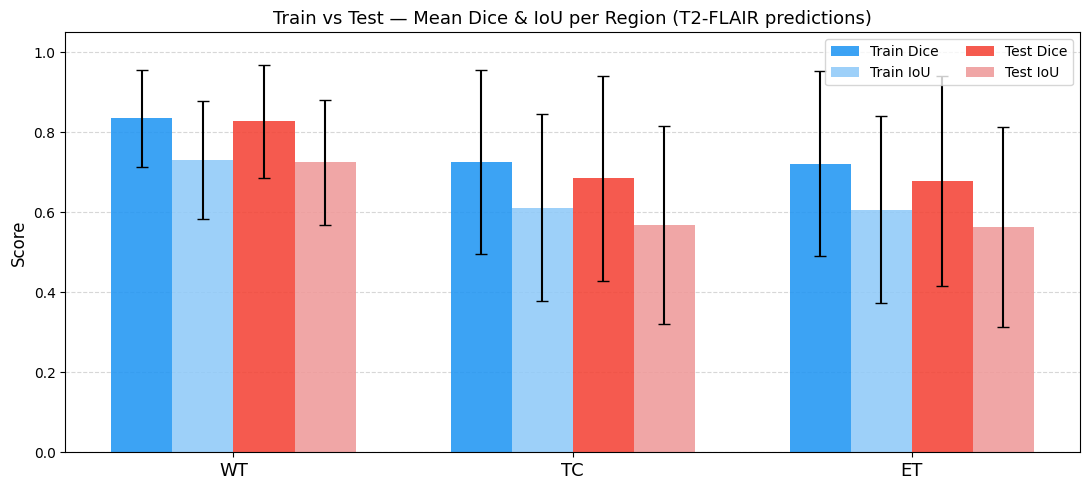

   💾 comparison_bar.png


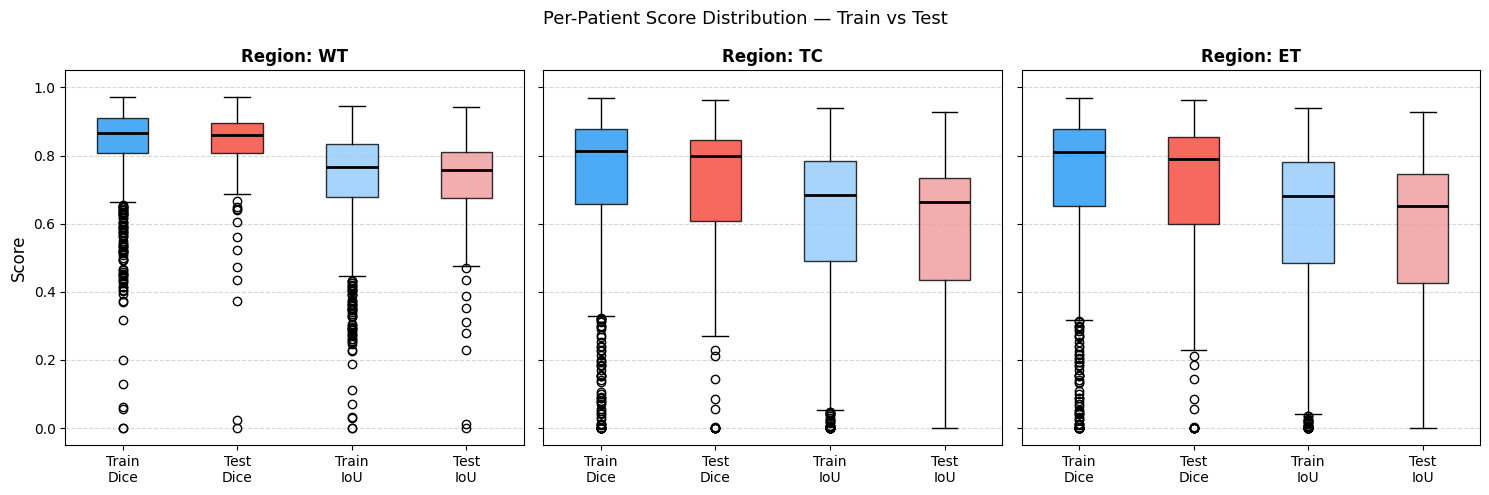

   💾 comparison_boxplot.png


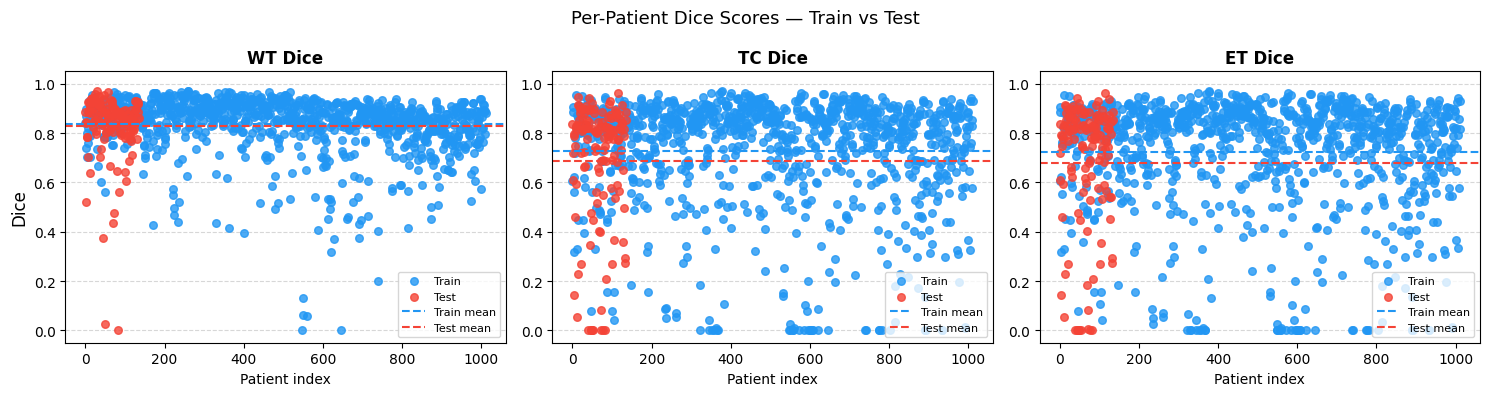

   💾 comparison_scatter.png

✅ All done.
   Checkpoint → checkpoint_scores.xlsx  (2 sheets: Scores + Summary)
   CSV        → all_scores_train_test.csv
   PNGs       → comparison_bar.png | comparison_boxplot.png | comparison_scatter.png
   Per-patient plots → flair_plots/


In [3]:
# ============================================================
#  run_all_and_compare.py
#  Run the 4-modality XGBoost model on ALL train + test patients,
#  visualise predictions on T2-FLAIR, collect Dice / IoU scores,
#  and produce a side-by-side comparison of train vs test.
#
#  ✅ CHECKPOINT SYSTEM:
#     - Progress is saved to `checkpoint_scores.xlsx` after EACH patient
#     - On re-run, already-processed patients are SKIPPED automatically
#     - Safe against power cuts, crashes, kernel restarts
#
#  SET THESE THREE PATHS:
# ============================================================

TRAIN_DIR  = r"train"                      # ← parent folder of all training patients
TEST_DIR   = r"test"                       # ← parent folder of all test patients
MODEL_DIR  = r"D:\shashwat\models_phase2"  # ← folder with xgb_final_phase2.pkl + best_config.npy

SAVE_PLOTS      = True    # save per-patient PNG?  (False = skip, speeds things up)
N_SLICES        = 5       # axial slices shown per patient plot
CHECKPOINT_FILE = "checkpoint_scores.xlsx"   # ← Excel file used for checkpointing

# ============================================================
import numpy as np
import nibabel as nib
import joblib
import os, gc, glob, csv, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.ndimage import (uniform_filter, gaussian_filter,
                            sobel as nd_sobel,
                            label as nd_label,
                            laplace,
                            distance_transform_edt)
from skimage.filters import gabor_kernel
from sklearn.metrics import f1_score, jaccard_score
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

warnings.filterwarnings('ignore')

MODALITIES  = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX  = 'seg'
N_CLASSES   = 4
LABEL_NAMES = {0: 'Background', 1: 'NCR', 2: 'Edema', 3: 'ET'}
REGIONS     = {'WT': [1, 2, 3], 'TC': [1, 3], 'ET': [3]}
MRF_BETA       = 0.5
MRF_ITERATIONS = 5
SEG_COLORS = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [0.9, 0.1, 0.1, 0.7],
    [0.9, 0.8, 0.0, 0.7],
    [0.0, 0.9, 0.9, 0.7],
], dtype=np.float32)

_COMPAT = np.array([
    [ 0.0, -1.0, -0.5, -1.0],
    [-1.0,  0.0, -0.8,  0.0],
    [-0.5, -0.8,  0.0, -0.8],
    [-1.0,  0.0, -0.8,  0.0],
], dtype=np.float32)

gabor_kernels = [
    np.real(gabor_kernel(0.2, theta=t)).astype(np.float32)
    for t in [0, np.pi/4, np.pi/2, 3*np.pi/4]
]

SCORE_COLUMNS = ['split', 'patient',
                 'WT_Dice', 'WT_IoU',
                 'TC_Dice', 'TC_IoU',
                 'ET_Dice', 'ET_IoU']

# ============================================================
# Checkpoint helpers
# ============================================================

def _header_style(cell, bg_hex):
    cell.font      = Font(bold=True, color="FFFFFF", name="Arial", size=10)
    cell.fill      = PatternFill("solid", fgColor=bg_hex)
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

def _thin_border():
    s = Side(style="thin", color="CCCCCC")
    return Border(left=s, right=s, top=s, bottom=s)

def _status_fill(status):
    colors = {"done": "E8F5E9", "skipped": "FFF9C4"}
    return PatternFill("solid", fgColor=colors.get(status, "FFFFFF"))

def init_checkpoint_excel(path):
    """Create a fresh Excel checkpoint file with formatted headers."""
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Scores"

    headers = SCORE_COLUMNS + ['status']
    header_colors = {
        'split':   '455A64',
        'patient': '455A64',
        'WT_Dice': '1565C0', 'WT_IoU': '1565C0',
        'TC_Dice': '6A1B9A', 'TC_IoU': '6A1B9A',
        'ET_Dice': 'B71C1C', 'ET_IoU': 'B71C1C',
        'status':  '2E7D32',
    }
    col_widths = {
        'split': 8, 'patient': 28,
        'WT_Dice': 12, 'WT_IoU': 12,
        'TC_Dice': 12, 'TC_IoU': 12,
        'ET_Dice': 12, 'ET_IoU': 12,
        'status': 10,
    }
    ws.row_dimensions[1].height = 30
    for ci, h in enumerate(headers, start=1):
        cell = ws.cell(row=1, column=ci, value=h)
        _header_style(cell, header_colors.get(h, '37474F'))
        ws.column_dimensions[get_column_letter(ci)].width = col_widths.get(h, 14)

    # Summary sheet
    ws2 = wb.create_sheet("Summary")
    ws2['A1'] = "Run Summary"
    ws2['A1'].font = Font(bold=True, size=13, name="Arial")
    ws2['A2'] = "This sheet is auto-updated after every patient."
    ws2['A2'].font = Font(italic=True, color="888888", name="Arial", size=9)

    wb.save(path)
    print(f"   📋 Created checkpoint file: {path}")


def load_completed(path):
    """
    Returns a set of (split, patient_id) tuples that are already done,
    and the list of score-row dicts already saved.
    """
    if not os.path.exists(path):
        return set(), []

    wb   = openpyxl.load_workbook(path)
    ws   = wb["Scores"]
    rows = list(ws.iter_rows(min_row=2, values_only=True))
    if not rows or rows[0][0] is None:
        return set(), []

    completed = set()
    saved_rows = []
    for r in rows:
        if r[0] is None:
            continue
        d = dict(zip(SCORE_COLUMNS + ['status'], r))
        key = (d['split'], d['patient'])
        if d.get('status') == 'done':
            completed.add(key)
            # Rebuild score row (NaN if stored as None)
            score_row = {k: (float('nan') if v is None else v) for k, v in d.items()
                         if k in SCORE_COLUMNS}
            saved_rows.append(score_row)
    print(f"   ♻️  Checkpoint: {len(completed)} patients already processed — will skip them.")
    return completed, saved_rows


def append_to_checkpoint(path, row_dict, status='done'):
    """Append one patient row to the Excel checkpoint (thread-safe via file open/close)."""
    if not os.path.exists(path):
        init_checkpoint_excel(path)

    wb = openpyxl.load_workbook(path)
    ws = wb["Scores"]

    # Find next empty row
    next_row = ws.max_row + 1

    values = [row_dict.get(c) for c in SCORE_COLUMNS] + [status]
    border = _thin_border()
    fill   = _status_fill(status)

    for ci, val in enumerate(values, start=1):
        cell = ws.cell(row=next_row, column=ci)
        # Store NaN as None so Excel doesn't show the string
        cell.value     = None if (isinstance(val, float) and np.isnan(val)) else val
        cell.border    = border
        cell.fill      = fill
        cell.font      = Font(name="Arial", size=10)
        cell.alignment = Alignment(horizontal="center")

    # Color score cells green/amber based on value
    metric_col_start = 3  # WT_Dice is col 3
    for ci in range(metric_col_start, metric_col_start + 6):
        cell = ws.cell(row=next_row, column=ci)
        if cell.value is not None:
            v = float(cell.value)
            if v >= 0.80:
                cell.fill = PatternFill("solid", fgColor="C8E6C9")
            elif v >= 0.60:
                cell.fill = PatternFill("solid", fgColor="FFF9C4")
            else:
                cell.fill = PatternFill("solid", fgColor="FFCDD2")

    _update_summary_sheet(wb, row_dict)
    wb.save(path)


def _update_summary_sheet(wb, latest_row):
    """Refresh the Summary sheet with current aggregate stats."""
    ws_scores = wb["Scores"]
    ws2 = wb["Summary"]
    ws2.delete_rows(4, ws2.max_row)  # clear old summary rows

    # Collect all rows
    all_rows = []
    for r in ws_scores.iter_rows(min_row=2, values_only=True):
        if r[0] is None:
            continue
        d = dict(zip(SCORE_COLUMNS + ['status'], r))
        all_rows.append(d)

    metric_keys = [f'{reg}_{m}' for reg in REGIONS for m in ['Dice', 'IoU']]
    header_row = ['Metric', 'Train (mean)', 'Train (std)', 'Train (n)',
                  'Test (mean)',  'Test (std)',  'Test (n)']
    for ci, h in enumerate(header_row, start=1):
        cell = ws2.cell(row=4, column=ci, value=h)
        cell.font      = Font(bold=True, name="Arial", size=10, color="FFFFFF")
        cell.fill      = PatternFill("solid", fgColor="37474F")
        cell.alignment = Alignment(horizontal="center")
        ws2.column_dimensions[get_column_letter(ci)].width = 16

    for ri, mk in enumerate(metric_keys, start=5):
        tr_vals = [float(r[mk]) for r in all_rows
                   if r.get('split') == 'train' and r.get(mk) is not None
                   and not (isinstance(r[mk], float) and np.isnan(r[mk]))]
        te_vals = [float(r[mk]) for r in all_rows
                   if r.get('split') == 'test'  and r.get(mk) is not None
                   and not (isinstance(r[mk], float) and np.isnan(r[mk]))]

        row_vals = [
            mk,
            round(np.mean(tr_vals), 4) if tr_vals else 'N/A',
            round(np.std(tr_vals),  4) if tr_vals else 'N/A',
            len(tr_vals),
            round(np.mean(te_vals), 4) if te_vals else 'N/A',
            round(np.std(te_vals),  4) if te_vals else 'N/A',
            len(te_vals),
        ]
        fill_color = "F3E5F5" if ri % 2 == 0 else "FFFFFF"
        for ci, val in enumerate(row_vals, start=1):
            cell = ws2.cell(row=ri, column=ci, value=val)
            cell.font      = Font(name="Arial", size=10)
            cell.fill      = PatternFill("solid", fgColor=fill_color)
            cell.alignment = Alignment(horizontal="center")

    ws2['A3'] = f"Last updated after patient: {latest_row.get('patient', '?')}  |  Total processed: {len(all_rows)}"
    ws2['A3'].font = Font(italic=True, color="555555", name="Arial", size=9)


# ============================================================
# Helper functions (unchanged)
# ============================================================
def zscore(vol, mask):
    v = vol.copy()
    roi = v[mask]
    v[mask]  = (roi - roi.mean()) / (roi.std() + 1e-8)
    v[~mask] = 0.0
    return v

def fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol**2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean**2, 0)).astype(np.float32)

def apply_gabor_3d(vol, kernel_2d):
    from scipy.ndimage import convolve
    return convolve(vol.astype(np.float32),
                    kernel_2d[:, :, np.newaxis],
                    mode='reflect').astype(np.float32)

def entropy_proxy(vol, size=5):
    lmean = uniform_filter(np.abs(vol).astype(np.float32), size=size)
    return (fast_local_std(vol, size) / (lmean + 1e-6)).astype(np.float32)

def distance_to_edge(mask):
    dist = distance_transform_edt(mask).astype(np.float32)
    return dist / (dist.max() + 1e-8)

def norm(img):
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-8)

def label_to_rgba(lslice):
    rgba = np.zeros((*lslice.shape, 4), dtype=np.float32)
    for lbl in range(N_CLASSES):
        rgba[lslice == lbl] = SEG_COLORS[lbl]
    return rgba

def extract_features(data, brain_mask):
    cols      = []
    dist_edge = distance_to_edge(brain_mask)
    shape     = data[MODALITIES[0]].shape

    def add(vol):
        cols.append(vol[brain_mask].astype(np.float32))

    proc = {mod: zscore(data[mod], brain_mask) for mod in MODALITIES}

    for mod in MODALITIES:
        vol = proc[mod].astype(np.float32)
        add(vol.copy())
        for sz in [3, 5, 9, 15]:
            add(uniform_filter(vol, size=sz))
            add(fast_local_std(vol, size=sz))
        gx = nd_sobel(vol, axis=0); gy = nd_sobel(vol, axis=1); gz = nd_sobel(vol, axis=2)
        add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
        del gx, gy, gz
        add(np.abs(laplace(vol)).astype(np.float32))
        g1 = gaussian_filter(vol, sigma=1.0)
        g2 = gaussian_filter(vol, sigma=2.0)
        g3 = gaussian_filter(vol, sigma=3.0)
        add(g1); add(g2); add(g3)
        add((g1 - g2).astype(np.float32))
        add((g2 - g3).astype(np.float32))
        del g1, g2, g3
        for k in gabor_kernels:
            add(apply_gabor_3d(vol, k))
        add((vol - vol[::-1, :, :]).astype(np.float32))
        add(entropy_proxy(vol))
        add(dist_edge)
        del vol
        gc.collect()

    cx, cy, cz = [s/2 for s in shape]
    xx, yy, zz = np.meshgrid(
        np.linspace(0, 1, shape[0], dtype=np.float32),
        np.linspace(0, 1, shape[1], dtype=np.float32),
        np.linspace(0, 1, shape[2], dtype=np.float32),
        indexing='ij')
    add(xx); add(yy); add(zz)
    xn = (np.arange(shape[0], dtype=np.float32) - cx) / (cx + 1e-8)
    yn = (np.arange(shape[1], dtype=np.float32) - cy) / (cy + 1e-8)
    zn = (np.arange(shape[2], dtype=np.float32) - cz) / (cz + 1e-8)
    add(np.sqrt(xn[:,None,None]**2 + yn[None,:,None]**2 + zn[None,None,:]**2).astype(np.float32))
    del xx, yy, zz; gc.collect()

    eps = 1e-8
    t1c = proc['t1c'].astype(np.float32)
    t1n = proc['t1n'].astype(np.float32)
    t2f = proc['t2f'].astype(np.float32)
    t2w = proc['t2w'].astype(np.float32)
    add(np.clip(t2w / (t1c + eps), -10, 10))
    add(np.clip(t2f / (t1n + eps), -10, 10))
    add(t2f - t1c);  add(t2w - t1n);  add(t1c - t1n)
    add(t2f - t2w);  add(t1c - t2f);  add(t1c - t2w)
    add(np.clip(t1c / (t2f + eps), -10, 10))
    add(gaussian_filter((t1c - t1n).astype(np.float32), sigma=1.5))
    add(np.clip(t2f / (t2w + eps), -10, 10))
    add((t1c * t2f) / (np.abs(t1c * t2f).max() + eps))
    add((t1n * t2w) / (np.abs(t1n * t2w).max() + eps))
    del t1c, t1n, t2f, t2w; gc.collect()

    return np.column_stack(cols).astype(np.float32), proc


def run_patient(patient_dir, xgb_model, cfg, split_tag, plot_dir):
    """
    Full pipeline for one patient.
    Returns a dict of scores, or None if patient is skipped.
    """
    pid = patient_dir.name

    # ── Load ──────────────────────────────────────────────────
    data = {}
    affine = None
    for mod in MODALITIES + [SEG_SUFFIX]:
        matches = (glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz")) or
                   glob.glob(str(patient_dir / f"*-{mod}.nii.gz")))
        if not matches:
            if mod == SEG_SUFFIX:
                data[mod] = None
            else:
                print(f"   ⚠️  {pid}: missing {mod}, skipping")
                return None
        else:
            img       = nib.load(matches[0])
            data[mod] = img.get_fdata(dtype=np.float32)
            if affine is None:
                affine = img.affine

    # ── Brain mask ────────────────────────────────────────────
    brain_mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
    for mod in MODALITIES:
        brain_mask |= (data[mod] > 0)

    # ── Features ──────────────────────────────────────────────
    X, proc = extract_features(data, brain_mask)
    shape   = data[MODALITIES[0]].shape

    # ── Inference ─────────────────────────────────────────────
    BATCH = 500_000
    proba_parts = []
    for s in range(0, len(X), BATCH):
        e = min(s + BATCH, len(X))
        proba_parts.append(xgb_model.predict_proba(X[s:e]).astype(np.float32))
    proba_flat = np.concatenate(proba_parts)
    del X; gc.collect()

    # ── MRF ───────────────────────────────────────────────────
    proba_vol = np.zeros((N_CLASSES, *shape), dtype=np.float32)
    for c in range(N_CLASSES):
        v = np.zeros(shape, dtype=np.float32)
        v[brain_mask] = proba_flat[:, c]
        proba_vol[c]  = v

    boost = np.array(cfg['boost'], dtype=np.float32)
    proba_vol *= boost[:, None, None, None]
    proba_vol /= proba_vol.sum(axis=0, keepdims=True) + 1e-8

    unary = np.log(np.clip(proba_vol, 1e-6, 1.0))
    q     = proba_vol.copy()
    for _ in range(MRF_ITERATIONS):
        q_sm  = np.stack([gaussian_filter(q[c].astype(np.float64), sigma=1.0).astype(np.float32)
                          for c in range(N_CLASSES)])
        msg   = np.einsum('cd,dxyz->cxyz', _COMPAT, q_sm)
        log_q = unary - MRF_BETA * msg
        log_q -= log_q.max(axis=0, keepdims=True)
        q      = np.exp(log_q)
        q     /= q.sum(axis=0, keepdims=True) + 1e-8
    proba_vol = q

    pred_vol = proba_vol.argmax(axis=0).astype(np.int8)
    prob_tumor = proba_vol[[1,2,3]].sum(axis=0)
    pred_vol[prob_tumor < cfg['wt_threshold']] = 0
    pred_vol[~brain_mask] = 0

    for lbl in [3, 1, 2]:
        binary = (pred_vol == lbl).astype(np.uint8)
        labeled, n_comp = nd_label(binary)
        for cid in range(1, n_comp + 1):
            if (labeled == cid).sum() < 200:
                pred_vol[labeled == cid] = 0

    del proba_flat; gc.collect()

    # ── Scores ────────────────────────────────────────────────
    row = {'split': split_tag, 'patient': pid}
    if data[SEG_SUFFIX] is not None:
        gt = data[SEG_SUFFIX].astype(np.int8)
        gt[gt == 4] = 3
        y_true = gt[brain_mask]
        y_pred = pred_vol[brain_mask]
        for region, labels in REGIONS.items():
            gt_r   = np.isin(y_true, labels).astype(np.uint8)
            pred_r = np.isin(y_pred, labels).astype(np.uint8)
            row[f'{region}_Dice'] = round(f1_score(gt_r, pred_r, zero_division=0), 4)
            row[f'{region}_IoU']  = round(jaccard_score(gt_r, pred_r, zero_division=0), 4)
    else:
        for region in REGIONS:
            row[f'{region}_Dice'] = float('nan')
            row[f'{region}_IoU']  = float('nan')

    # ── Plot on T2-FLAIR ──────────────────────────────────────
    if SAVE_PLOTS:
        has_gt   = data[SEG_SUFFIX] is not None
        n_cols   = 3 if has_gt else 2
        z_idx    = np.linspace(shape[2]*0.2, shape[2]*0.8, N_SLICES, dtype=int)
        fig, axes = plt.subplots(N_SLICES, n_cols,
                                  figsize=(5*n_cols, 4*N_SLICES))
        if N_SLICES == 1:
            axes = axes[np.newaxis, :]

        titles = ['T2-FLAIR', 'Prediction on T2-FLAIR']
        if has_gt: titles.append('GT on T2-FLAIR')
        for col, t in enumerate(titles):
            axes[0, col].set_title(t, fontsize=11, fontweight='bold')
        fig.suptitle(f"[{split_tag.upper()}]  {pid}", fontsize=13, y=1.01)

        for row_i, z in enumerate(z_idx):
            flair_sl = data['t2f'][:, :, z]
            pred_sl  = pred_vol[:, :, z]
            axes[row_i, 0].imshow(norm(flair_sl).T, cmap='gray', origin='lower')
            axes[row_i, 0].set_ylabel(f"z={z}", fontsize=9)
            axes[row_i, 0].axis('off')
            axes[row_i, 1].imshow(norm(flair_sl).T, cmap='gray', origin='lower')
            axes[row_i, 1].imshow(label_to_rgba(pred_sl).transpose(1, 0, 2),
                                   origin='lower', interpolation='none')
            axes[row_i, 1].axis('off')
            if has_gt:
                gt_sl = gt[:, :, z]
                axes[row_i, 2].imshow(norm(flair_sl).T, cmap='gray', origin='lower')
                axes[row_i, 2].imshow(label_to_rgba(gt_sl).transpose(1, 0, 2),
                                       origin='lower', interpolation='none')
                axes[row_i, 2].axis('off')

        patches = [mpatches.Patch(color=SEG_COLORS[i, :3], label=n)
                   for i, n in zip([1,2,3], ['NCR','Edema','ET'])]
        fig.legend(handles=patches, loc='lower center', ncol=3,
                   fontsize=10, bbox_to_anchor=(0.5, -0.02))
        plt.tight_layout()
        out_png = plot_dir / f"{split_tag}_{pid}.png"
        plt.savefig(out_png, dpi=100, bbox_inches='tight')
        plt.close()

    del data, proc, pred_vol, proba_vol, brain_mask
    gc.collect()
    return row


# ============================================================
# MAIN
# ============================================================
print("📦 Loading model...")
xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_final_phase2.pkl"))
cfg_path  = os.path.join(MODEL_DIR, "best_config.npy")
cfg = (np.load(cfg_path, allow_pickle=True).item() if os.path.exists(cfg_path)
       else {'wt_threshold': 0.35, 'boost': np.array([1.0, 2.5, 1.0, 2.0], np.float32)})
print(f"   ✅  WT threshold={cfg['wt_threshold']}  boost={cfg['boost']}")

plot_dir = Path("flair_plots")
plot_dir.mkdir(exist_ok=True)

# ── Init / load checkpoint ────────────────────────────────────
if not os.path.exists(CHECKPOINT_FILE):
    init_checkpoint_excel(CHECKPOINT_FILE)

completed_set, all_scores = load_completed(CHECKPOINT_FILE)
print(f"   📂 Checkpoint file: {CHECKPOINT_FILE}")

# ============================================================
# PROCESS PATIENTS
# ============================================================
for split_tag, base_dir in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    base = Path(base_dir)
    if not base.exists():
        print(f"\n⚠️  {split_tag} directory not found: {base_dir} — skipping")
        continue
    patient_dirs = sorted([p for p in base.iterdir() if p.is_dir()])
    print(f"\n{'='*60}")
    print(f"  Split: {split_tag.upper()}  |  {len(patient_dirs)} patients  |  {base_dir}")
    print(f"{'='*60}")

    for i, pd_ in enumerate(patient_dirs):
        pid = pd_.name
        key = (split_tag, pid)

        # ── CHECKPOINT: skip if already done ─────────────────
        if key in completed_set:
            print(f"\n  [{split_tag}] ({i+1}/{len(patient_dirs)}) {pid}  ⏭️  already done — skipping")
            continue

        print(f"\n  [{split_tag}] ({i+1}/{len(patient_dirs)}) {pid}")
        row = run_patient(pd_, xgb_model, cfg, split_tag, plot_dir)

        if row is not None:
            all_scores.append(row)
            for region in REGIONS:
                d = row[f'{region}_Dice']
                u = row[f'{region}_IoU']
                if not np.isnan(d):
                    print(f"    {region}  Dice={d:.4f}  IoU={u:.4f}")
                else:
                    print(f"    {region}  no GT available")

            # ── CHECKPOINT: save immediately to Excel ─────────
            append_to_checkpoint(CHECKPOINT_FILE, row, status='done')
            completed_set.add(key)
            print(f"    💾 Checkpoint saved → {CHECKPOINT_FILE}")

# ============================================================
# SAVE CSV (always regenerated from all_scores in memory)
# ============================================================
csv_path = "all_scores_train_test.csv"
if all_scores:
    fieldnames = list(all_scores[0].keys())
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(all_scores)
    print(f"\n💾 Scores saved → {csv_path}")

# ============================================================
# COMPARISON SUMMARY TABLE (console)
# ============================================================
print(f"\n{'='*60}")
print("  SUMMARY — Train vs Test  (mean ± std)")
print(f"{'='*60}")

metric_keys = [f'{r}_{m}' for r in REGIONS for m in ['Dice', 'IoU']]
header = f"  {'Metric':<16} {'Train':>16} {'Test':>16}"
print(header)
print("  " + "-"*50)

summary = {}
for split in ['train', 'test']:
    rows = [r for r in all_scores if r['split'] == split]
    summary[split] = {}
    for k in metric_keys:
        vals = [r[k] for r in rows if not np.isnan(r[k])]
        summary[split][k] = vals

for k in metric_keys:
    tr = summary['train'][k]
    te = summary['test'][k]
    tr_str = f"{np.mean(tr):.4f} ± {np.std(tr):.4f}" if tr else "N/A"
    te_str = f"{np.mean(te):.4f} ± {np.std(te):.4f}" if te else "N/A"
    print(f"  {k:<16} {tr_str:>16} {te_str:>16}")

# ============================================================
# COMPARISON PLOTS
# ============================================================
print("\n📊 Generating comparison plots...")

# ── 1. Bar chart ──────────────────────────────────────────────
regions  = list(REGIONS.keys())
metrics  = ['Dice', 'IoU']
x        = np.arange(len(regions))
width    = 0.18
colors   = {'train_Dice': '#2196F3', 'train_IoU': '#90CAF9',
            'test_Dice':  '#F44336', 'test_IoU':  '#EF9A9A'}

fig, ax = plt.subplots(figsize=(11, 5))
for i, (split, metric) in enumerate([('train','Dice'),('train','IoU'),
                                      ('test', 'Dice'),('test', 'IoU')]):
    vals  = [np.mean(summary[split][f'{r}_{metric}']) if summary[split][f'{r}_{metric}'] else 0
             for r in regions]
    errs  = [np.std(summary[split][f'{r}_{metric}'])  if summary[split][f'{r}_{metric}'] else 0
             for r in regions]
    label = f'{split.capitalize()} {metric}'
    color = colors[f'{split}_{metric}']
    bars  = ax.bar(x + (i - 1.5) * width, vals, width,
                   yerr=errs, capsize=4,
                   label=label, color=color, alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=13)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Train vs Test — Mean Dice & IoU per Region (T2-FLAIR predictions)', fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, ncol=2)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("comparison_bar.png", dpi=130, bbox_inches='tight')
plt.show()
print("   💾 comparison_bar.png")

# ── 2. Box plots ──────────────────────────────────────────────
fig, axes = plt.subplots(1, len(regions), figsize=(5 * len(regions), 5), sharey=True)
if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    tr_dice = summary['train'][f'{region}_Dice']
    te_dice = summary['test'][f'{region}_Dice']
    tr_iou  = summary['train'][f'{region}_IoU']
    te_iou  = summary['test'][f'{region}_IoU']

    data_bp  = [tr_dice, te_dice, tr_iou, te_iou]
    labels_bp = ['Train\nDice', 'Test\nDice', 'Train\nIoU', 'Test\nIoU']
    bp = ax.boxplot(data_bp, labels=labels_bp, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    box_colors = ['#2196F3', '#F44336', '#90CAF9', '#EF9A9A']
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)

    ax.set_title(f'Region: {region}', fontsize=12, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Score', fontsize=12)
fig.suptitle('Per-Patient Score Distribution — Train vs Test', fontsize=13)
plt.tight_layout()
plt.savefig("comparison_boxplot.png", dpi=130, bbox_inches='tight')
plt.show()
print("   💾 comparison_boxplot.png")

# ── 3. Per-patient Dice scatter ───────────────────────────────
fig, axes = plt.subplots(1, len(regions), figsize=(5 * len(regions), 4))
if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    key = f'{region}_Dice'
    tr_rows = [r for r in all_scores if r['split'] == 'train' and not np.isnan(r[key])]
    te_rows = [r for r in all_scores if r['split'] == 'test'  and not np.isnan(r[key])]
    ax.scatter(range(len(tr_rows)), [r[key] for r in tr_rows],
               color='#2196F3', s=30, alpha=0.8, label='Train')
    ax.scatter(range(len(te_rows)), [r[key] for r in te_rows],
               color='#F44336', s=30, alpha=0.8, label='Test')
    if tr_rows:
        ax.axhline(np.mean([r[key] for r in tr_rows]),
                   color='#2196F3', linestyle='--', linewidth=1.5, label='Train mean')
    if te_rows:
        ax.axhline(np.mean([r[key] for r in te_rows]),
                   color='#F44336', linestyle='--', linewidth=1.5, label='Test mean')
    ax.set_title(f'{region} Dice', fontsize=12, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Patient index')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Dice', fontsize=12)
fig.suptitle('Per-Patient Dice Scores — Train vs Test', fontsize=13)
plt.tight_layout()
plt.savefig("comparison_scatter.png", dpi=130, bbox_inches='tight')
plt.show()
print("   💾 comparison_scatter.png")

print("\n✅ All done.")
print(f"   Checkpoint → {CHECKPOINT_FILE}  (2 sheets: Scores + Summary)")
print(f"   CSV        → all_scores_train_test.csv")                 
print(f"   PNGs       → comparison_bar.png | comparison_boxplot.png | comparison_scatter.png")
print(f"   Per-patient plots → flair_plots/")

🚀  Running inference on  [test]  BraTS-GLI-00511-101 …


────────────────────────────────────────────
  Patient : BraTS-GLI-00511-101
  Split   : test
────────────────────────────────────────────
  WT   Dice: 0.5212  [██████████░░░░░░░░░░]  IoU: 0.3525
  TC   Dice: 0.6105  [████████████░░░░░░░░]  IoU: 0.4394
  ET   Dice: 0.6105  [████████████░░░░░░░░]  IoU: 0.4394
────────────────────────────────────────────

   🔄  Rebuilding prediction volume for display …
   💾 Saved → flair_plots\single_test_BraTS-GLI-00511-101.png


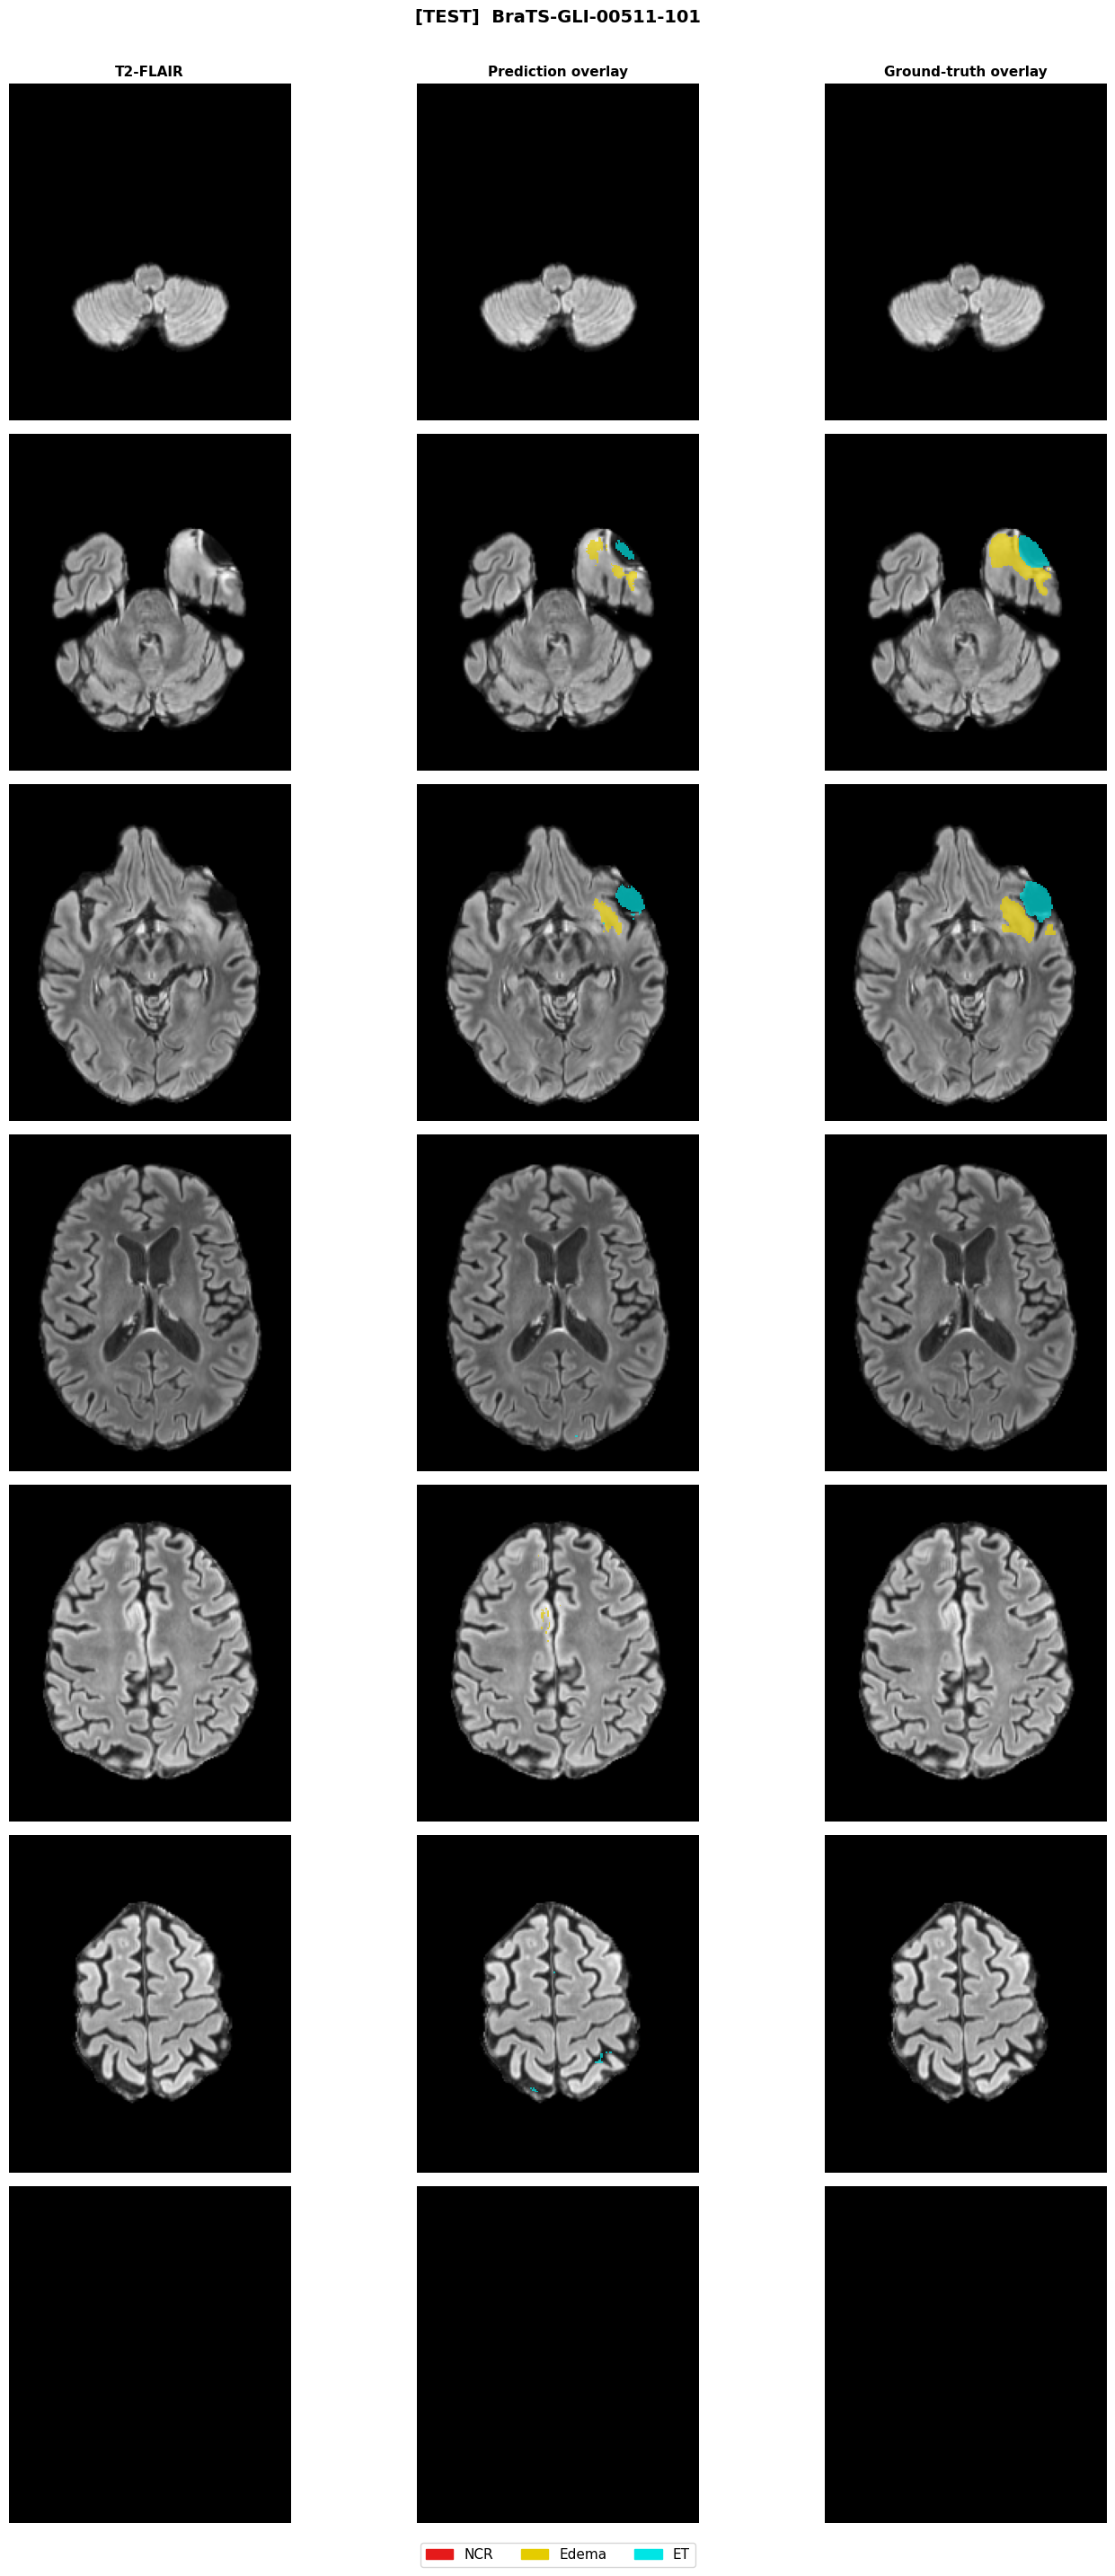


✅  Done.


In [8]:
# ============================================================
#  CELL: Single-patient inference + T2-FLAIR visualisation
#  Set the two paths below and run the cell.
#  (xgb_model and cfg must already be loaded from the previous cell,
#   OR set STANDALONE = True to reload them from disk)
# ============================================================

PATIENT_DIR = r"test/BraTS-GLI-00511-101"   # ← set this
MODEL_DIR   = r"D:\shashwat\models_phase2"    # ← only used if STANDALONE=True
STANDALONE  = False   # True → reload model from MODEL_DIR
N_SLICES    = 7       # axial slices to display
SAVE_SINGLE = True    # save PNG to flair_plots/

# ── Optionally reload model ───────────────────────────────────
if STANDALONE:
    print("📦 Loading model …")
    xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_final_phase2.pkl"))
    cfg_path  = os.path.join(MODEL_DIR, "best_config.npy")
    cfg = (np.load(cfg_path, allow_pickle=True).item()
           if os.path.exists(cfg_path)
           else {'wt_threshold': 0.35,
                 'boost': np.array([1.0, 2.5, 1.0, 2.0], np.float32)})
    print(f"   ✅  WT threshold={cfg['wt_threshold']}  boost={cfg['boost']}")

# ── Resolve patient ───────────────────────────────────────────
patient_dir = Path(PATIENT_DIR)
if not patient_dir.exists():
    raise FileNotFoundError(f"Patient directory not found: {patient_dir}")

pid = patient_dir.name
split_tag = 'unknown'
for part in patient_dir.parts:
    if part.lower() in ('train', 'test', 'val', 'validation'):
        split_tag = part.lower()
        break

print(f"🚀  Running inference on  [{split_tag}]  {pid} …\n")

plot_dir = Path("flair_plots")
plot_dir.mkdir(exist_ok=True)

# ── Run pipeline (scores + PNG via run_patient) ───────────────
row = run_patient(patient_dir, xgb_model, cfg, split_tag, plot_dir)

if row is None:
    raise RuntimeError("Patient was skipped — check for missing modality files.")

# ── Print scores ──────────────────────────────────────────────
print(f"\n{'─'*44}")
print(f"  Patient : {pid}")
print(f"  Split   : {split_tag}")
print(f"{'─'*44}")
has_scores = False
for region in REGIONS:
    d = row.get(f'{region}_Dice', float('nan'))
    u = row.get(f'{region}_IoU',  float('nan'))
    if not np.isnan(d):
        has_scores = True
        bar = '█' * int(d * 20) + '░' * (20 - int(d * 20))
        print(f"  {region:3s}  Dice: {d:.4f}  [{bar}]  IoU: {u:.4f}")
if not has_scores:
    print("  (No ground-truth segmentation — scores not computed)")
print(f"{'─'*44}\n")

# ── Reload volumes for display (run_patient frees them) ───────
data_plot = {}
for mod in MODALITIES + [SEG_SUFFIX]:
    matches = (glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz")) or
               glob.glob(str(patient_dir / f"*-{mod}.nii.gz")))
    data_plot[mod] = nib.load(matches[0]).get_fdata(dtype=np.float32) if matches else None

flair = data_plot['t2f']
if flair is None:
    raise FileNotFoundError("T2-FLAIR not found — cannot display.")

shape      = flair.shape
brain_mask = np.zeros(shape, dtype=bool)
for mod in MODALITIES:
    if data_plot[mod] is not None:
        brain_mask |= (data_plot[mod] > 0)

# ── Re-inference for pred_vol ─────────────────────────────────
print("   🔄  Rebuilding prediction volume for display …")
data_tmp = {m: data_plot[m] for m in MODALITIES if data_plot[m] is not None}
X2, _    = extract_features(data_tmp, brain_mask)

BATCH = 500_000
proba_parts = []
for s in range(0, len(X2), BATCH):
    proba_parts.append(xgb_model.predict_proba(X2[s:min(s+BATCH, len(X2))]).astype(np.float32))
proba_flat = np.concatenate(proba_parts)
del X2; gc.collect()

proba_vol = np.zeros((N_CLASSES, *shape), dtype=np.float32)
for c in range(N_CLASSES):
    v = np.zeros(shape, dtype=np.float32)
    v[brain_mask] = proba_flat[:, c]
    proba_vol[c]  = v

boost      = np.array(cfg['boost'], dtype=np.float32)
proba_vol *= boost[:, None, None, None]
proba_vol /= proba_vol.sum(axis=0, keepdims=True) + 1e-8

unary = np.log(np.clip(proba_vol, 1e-6, 1.0))
q     = proba_vol.copy()
for _ in range(MRF_ITERATIONS):
    q_sm  = np.stack([gaussian_filter(q[c].astype(np.float64), sigma=1.0).astype(np.float32)
                      for c in range(N_CLASSES)])
    msg   = np.einsum('cd,dxyz->cxyz', _COMPAT, q_sm)
    log_q = unary - MRF_BETA * msg
    log_q -= log_q.max(axis=0, keepdims=True)
    q      = np.exp(log_q)
    q     /= q.sum(axis=0, keepdims=True) + 1e-8

pred_vol = q.argmax(axis=0).astype(np.int8)
pred_vol[q[[1,2,3]].sum(axis=0) < cfg['wt_threshold']] = 0
pred_vol[~brain_mask] = 0
del proba_flat, q; gc.collect()

# ── Plot ──────────────────────────────────────────────────────
has_gt  = data_plot[SEG_SUFFIX] is not None
n_cols  = 3 if has_gt else 2
z_idx   = np.linspace(shape[2]*0.15, shape[2]*0.85, N_SLICES, dtype=int)

col_titles = ['T2-FLAIR', 'Prediction overlay']
if has_gt:
    col_titles.append('Ground-truth overlay')
    gt = data_plot[SEG_SUFFIX].astype(np.int8)
    gt[gt == 4] = 3

fig, axes = plt.subplots(N_SLICES, n_cols, figsize=(5*n_cols, 4*N_SLICES))
if N_SLICES == 1:
    axes = axes[np.newaxis, :]

for ci, t in enumerate(col_titles):
    axes[0, ci].set_title(t, fontsize=11, fontweight='bold', pad=6)
fig.suptitle(f"[{split_tag.upper()}]  {pid}", fontsize=14, fontweight='bold', y=1.005)

for ri, z in enumerate(z_idx):
    fl_sl   = norm(flair[:, :, z]).T
    pred_sl = pred_vol[:, :, z]

    axes[ri, 0].imshow(fl_sl, cmap='gray', origin='lower')
    axes[ri, 0].set_ylabel(f"z = {z}", fontsize=9)
    axes[ri, 0].axis('off')

    axes[ri, 1].imshow(fl_sl, cmap='gray', origin='lower')
    axes[ri, 1].imshow(label_to_rgba(pred_sl).transpose(1, 0, 2),
                       origin='lower', interpolation='none')
    axes[ri, 1].axis('off')

    if has_gt:
        axes[ri, 2].imshow(fl_sl, cmap='gray', origin='lower')
        axes[ri, 2].imshow(label_to_rgba(gt[:, :, z]).transpose(1, 0, 2),
                           origin='lower', interpolation='none')
        axes[ri, 2].axis('off')

patches = [mpatches.Patch(color=SEG_COLORS[i, :3], label=n)
           for i, n in zip([1, 2, 3], ['NCR', 'Edema', 'ET'])]
fig.legend(handles=patches, loc='lower center', ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.015))
plt.tight_layout()

if SAVE_SINGLE:
    out_png = plot_dir / f"single_{split_tag}_{pid}.png"
    plt.savefig(out_png, dpi=110, bbox_inches='tight')
    print(f"   💾 Saved → {out_png}")

plt.show()

del data_plot, pred_vol, proba_vol, brain_mask
gc.collect()
print("\n✅  Done.")


📦 Loading model from D:\shashwat\models_phase2...
   ✅ Model loaded
   ✅ Config loaded
   WT threshold : 0.52
   Boost        : [1.  1.5 1.  1.5]

  Processing patient: BraTS-GLI-00511-101
📂 Loading...
   t1c: (182, 218, 182)
   t1n: (182, 218, 182)
   t2f: (182, 218, 182)
   t2w: (182, 218, 182)
   seg: (182, 218, 182)
   Brain voxels: 1,826,089
🔧 Extracting features...
   Feature matrix: (1826089, 109)
🚀 Running inference...
   voxels 0 → 500,000 done
   voxels 500,000 → 1,000,000 done
   voxels 1,000,000 → 1,500,000 done
   voxels 1,500,000 → 1,826,089 done
🧠 MRF smoothing...
   MRF iter 1/5
   MRF iter 2/5
   MRF iter 3/5
   MRF iter 4/5
   MRF iter 5/5

── Predicted voxel counts ──
   0 Background  : 7,208,260 voxels
   1 NCR         :        0 voxels
   2 Edema       :    4,306 voxels
   3 ET          :    8,466 voxels

── Dice / IoU (T2-FLAIR visualisation) ──
   WT  Dice=0.5212  IoU=0.3525
   TC  Dice=0.6105  IoU=0.4394
   ET  Dice=0.6105  IoU=0.4394

── Per-label GT vs Pred ─

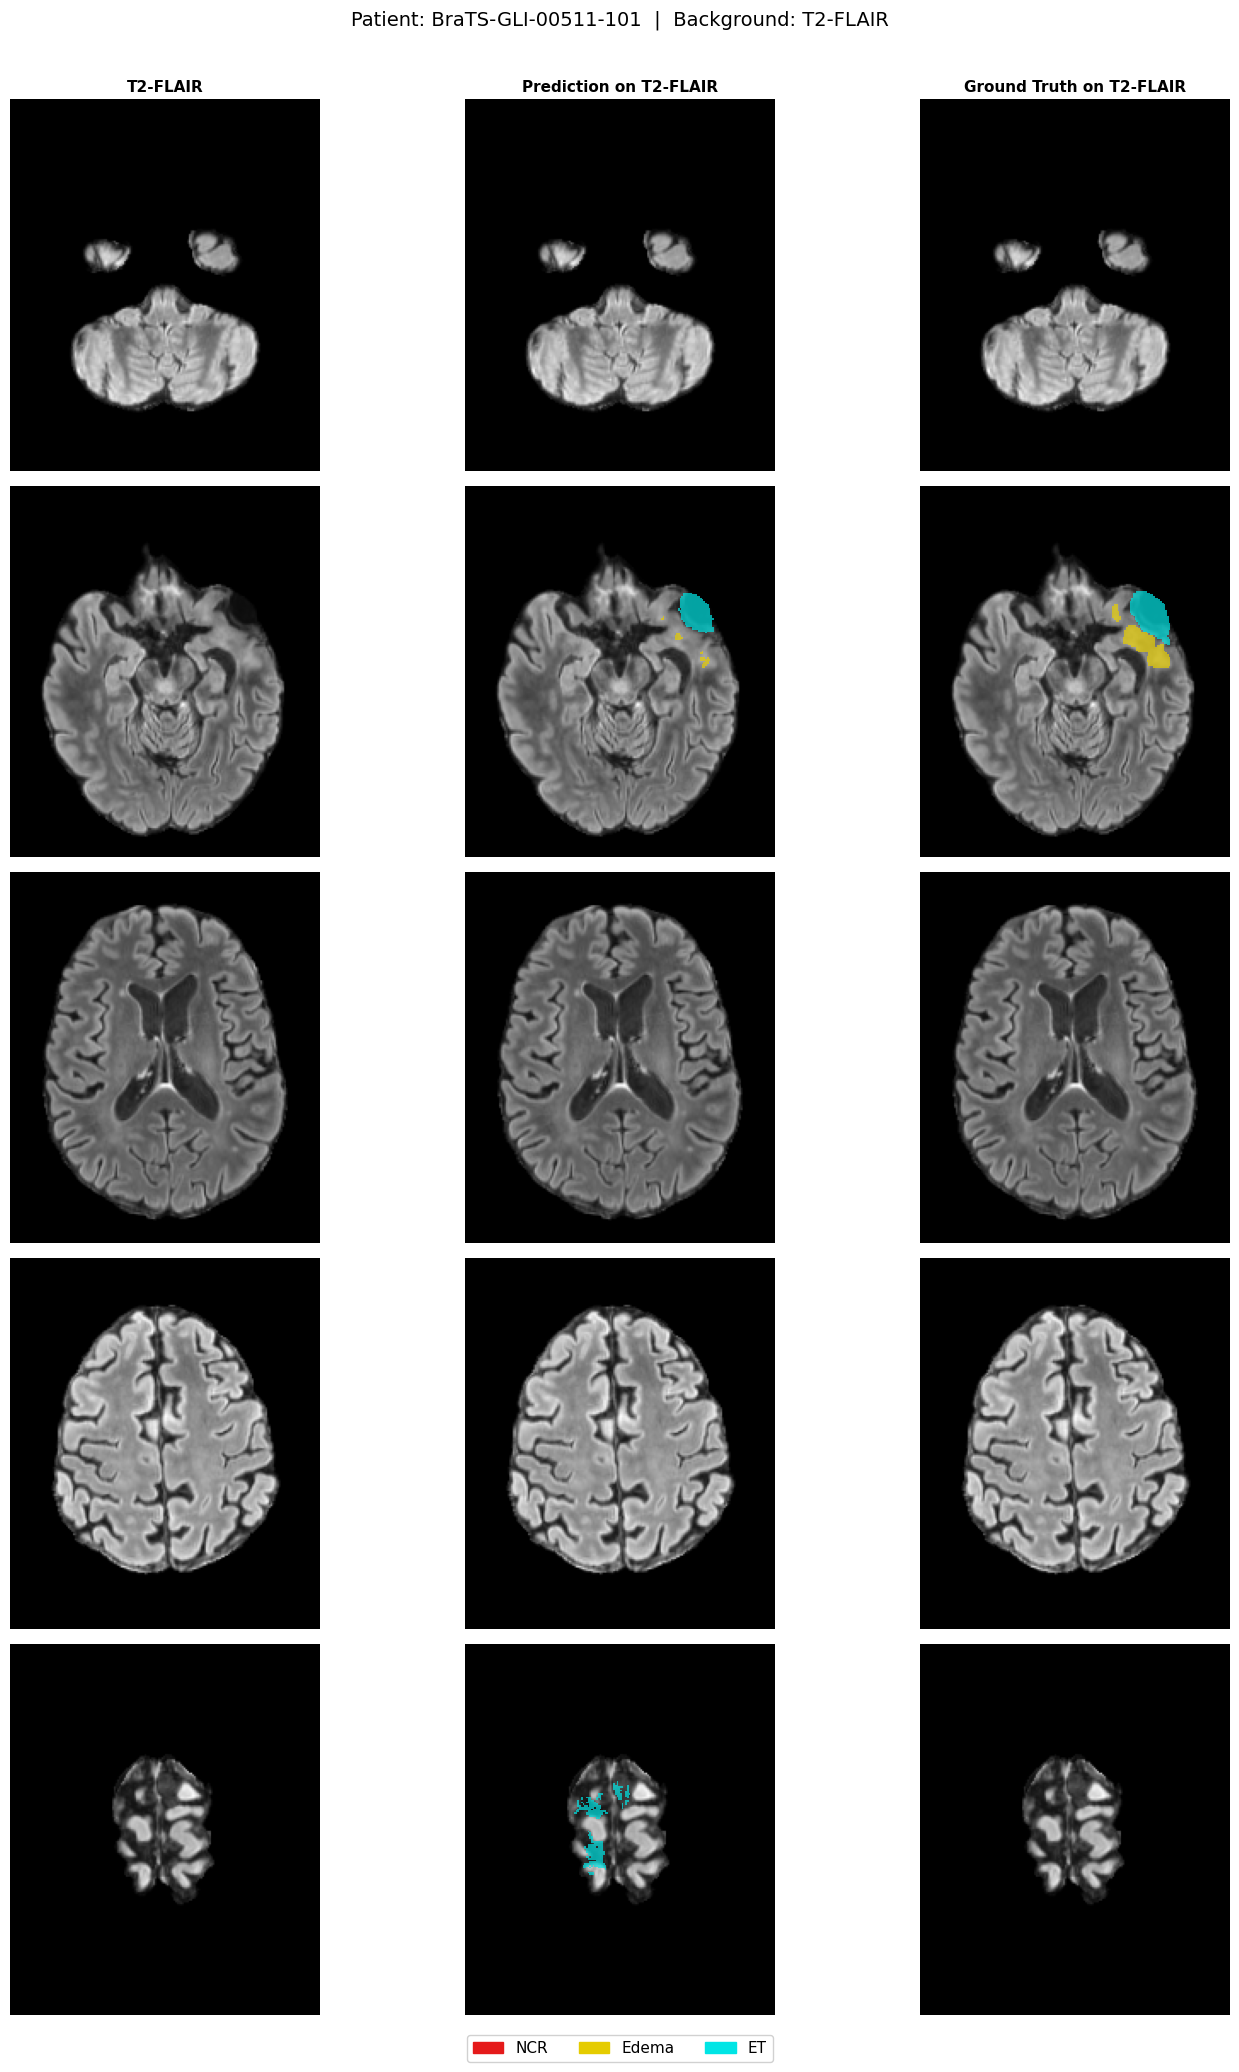

   💾 Saved: BraTS-GLI-00511-101_flair_prediction.png

  SUMMARY — Scores across all patients (T2-FLAIR view)
       patient       WT_Dice        WT_IoU       TC_Dice        TC_IoU       ET_Dice        ET_IoU
  BraTS-GLI-00511-101        0.5212        0.3525        0.6105        0.4394        0.6105        0.4394

  💾 Scores saved to: all_patients_scores.csv

  Averages:
    WT_Dice         : 0.5212
    WT_IoU          : 0.3525
    TC_Dice         : 0.6105
    TC_IoU          : 0.4394
    ET_Dice         : 0.6105
    ET_IoU          : 0.4394

✅ Done.


In [9]:
# ============================================================
# inference — run this cell
# Set the two paths below, everything prints in cell output
# ============================================================

PATIENT_DIR = r"test\BraTS-GLI-00511-101"   # ← folder for one patient
MODEL_DIR   = r"D:\shashwat\models_phase2"               # ← folder containing pkl + npy

# If you want to run on ALL patients at once, set this to the
# parent folder containing all patient sub-folders, e.g.:
#   ALL_PATIENTS_DIR = r"test"
# and set PATIENT_DIR = None
ALL_PATIENTS_DIR = None   # ← set to parent folder to batch-run, else None

# ============================================================
import numpy as np
import nibabel as nib
import joblib
import os
import gc
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv
from pathlib import Path
from scipy.ndimage import (uniform_filter, gaussian_filter,
                            sobel as nd_sobel,
                            label as nd_label,
                            laplace,
                            distance_transform_edt)
from skimage.filters import gabor_kernel
from sklearn.metrics import f1_score, jaccard_score

MODALITIES  = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX  = 'seg'
N_CLASSES   = 4
LABEL_NAMES = {0: 'Background', 1: 'NCR', 2: 'Edema', 3: 'ET'}
REGIONS     = {'WT': [1, 2, 3], 'TC': [1, 3], 'ET': [3]}
MRF_BETA       = 0.5
MRF_ITERATIONS = 5
SEG_COLORS = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [0.9, 0.1, 0.1, 0.7],
    [0.9, 0.8, 0.0, 0.7],
    [0.0, 0.9, 0.9, 0.7],
], dtype=np.float32)

# ============================================================
# Collect patient directories to process
# ============================================================
if ALL_PATIENTS_DIR is not None:
    parent = Path(ALL_PATIENTS_DIR)
    patient_dirs = sorted([p for p in parent.iterdir() if p.is_dir()])
    print(f"📁 Found {len(patient_dirs)} patient folders in {ALL_PATIENTS_DIR}")
else:
    patient_dirs = [Path(PATIENT_DIR)]

# CSV log to save all scores
score_log = []   # list of dicts, one per patient

# ============================================================
# Load model ONCE outside the patient loop
# ============================================================
print(f"\n📦 Loading model from {MODEL_DIR}...")
xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_final_phase2.pkl"))
print("   ✅ Model loaded")

cfg_path = os.path.join(MODEL_DIR, "best_config.npy")
if os.path.exists(cfg_path):
    cfg = np.load(cfg_path, allow_pickle=True).item()
    print(f"   ✅ Config loaded")
else:
    cfg = {'wt_threshold': 0.35,
           'boost': np.array([1.0, 2.5, 1.0, 2.0], np.float32)}
    print("   ⚠️  Config not found — using defaults")

print(f"   WT threshold : {cfg['wt_threshold']}")
print(f"   Boost        : {cfg['boost']}")


# ============================================================
# Helper functions
# ============================================================
def zscore(vol, mask):
    v = vol.copy()
    roi = v[mask]
    v[mask]  = (roi - roi.mean()) / (roi.std() + 1e-8)
    v[~mask] = 0.0
    return v

def fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol**2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean**2, 0)).astype(np.float32)

def apply_gabor_3d(vol, kernel_2d):
    from scipy.ndimage import convolve
    return convolve(vol.astype(np.float32),
                    kernel_2d[:, :, np.newaxis],
                    mode='reflect').astype(np.float32)

def entropy_proxy(vol, size=5):
    lmean = uniform_filter(np.abs(vol).astype(np.float32), size=size)
    return (fast_local_std(vol, size) / (lmean + 1e-6)).astype(np.float32)

def distance_to_edge(mask):
    dist = distance_transform_edt(mask).astype(np.float32)
    return dist / (dist.max() + 1e-8)

def norm(img):
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-8)

def label_to_rgba(lslice):
    rgba = np.zeros((*lslice.shape, 4), dtype=np.float32)
    for lbl in range(N_CLASSES):
        rgba[lslice == lbl] = SEG_COLORS[lbl]
    return rgba

gabor_kernels = [
    np.real(gabor_kernel(0.2, theta=t)).astype(np.float32)
    for t in [0, np.pi/4, np.pi/2, 3*np.pi/4]
]

_COMPAT = np.array([
    [ 0.0, -1.0, -0.5, -1.0],
    [-1.0,  0.0, -0.8,  0.0],
    [-0.5, -0.8,  0.0, -0.8],
    [-1.0,  0.0, -0.8,  0.0],
], dtype=np.float32)


# ============================================================
# Per-patient loop
# ============================================================
for patient_dir in patient_dirs:

    pid = patient_dir.name
    print(f"\n{'='*56}")
    print(f"  Processing patient: {pid}")
    print(f"{'='*56}")

    # ----------------------------------------------------------
    # STEP 1 — LOAD
    # ----------------------------------------------------------
    print("📂 Loading...")
    data   = {}
    affine = None

    for mod in MODALITIES + [SEG_SUFFIX]:
        matches = glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz"))
        if not matches:
            matches = glob.glob(str(patient_dir / f"*-{mod}.nii.gz"))
        if not matches:
            if mod == SEG_SUFFIX:
                data[mod] = None
                print(f"   {mod}: not found — Dice will be skipped")
                continue
            else:
                print(f"   ⚠️  Missing modality {mod} — skipping patient")
                break
        img        = nib.load(matches[0])
        data[mod]  = img.get_fdata(dtype=np.float32)
        if affine is None:
            affine = img.affine
        print(f"   {mod}: {data[mod].shape}")
    else:
        pass   # all modalities found, continue

    if any(mod not in data for mod in MODALITIES):
        continue   # skip this patient

    # ----------------------------------------------------------
    # STEP 2 — PREPROCESS
    # ----------------------------------------------------------
    brain_mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
    for mod in MODALITIES:
        brain_mask |= (data[mod] > 0)
    print(f"   Brain voxels: {brain_mask.sum():,}")

    proc = {}
    for mod in MODALITIES:
        proc[mod] = zscore(data[mod], brain_mask)
    proc[SEG_SUFFIX] = data[SEG_SUFFIX]

    # ----------------------------------------------------------
    # STEP 3 — FEATURE EXTRACTION
    # ----------------------------------------------------------
    print("🔧 Extracting features...")
    cols      = []
    dist_edge = distance_to_edge(brain_mask)

    def add(vol):
        cols.append(vol[brain_mask].astype(np.float32))

    for mod in MODALITIES:
        vol = proc[mod].astype(np.float32)
        add(vol.copy())
        for sz in [3, 5, 9, 15]:
            add(uniform_filter(vol, size=sz))
            add(fast_local_std(vol, size=sz))
        gx = nd_sobel(vol, axis=0)
        gy = nd_sobel(vol, axis=1)
        gz = nd_sobel(vol, axis=2)
        add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
        del gx, gy, gz
        add(np.abs(laplace(vol)).astype(np.float32))
        g1 = gaussian_filter(vol, sigma=1.0)
        g2 = gaussian_filter(vol, sigma=2.0)
        g3 = gaussian_filter(vol, sigma=3.0)
        add(g1); add(g2); add(g3)
        add((g1 - g2).astype(np.float32))
        add((g2 - g3).astype(np.float32))
        del g1, g2, g3
        for k in gabor_kernels:
            add(apply_gabor_3d(vol, k))
        add((vol - vol[::-1, :, :]).astype(np.float32))
        add(entropy_proxy(vol))
        add(dist_edge)
        del vol
        gc.collect()

    shape = proc[MODALITIES[0]].shape
    cx, cy, cz = [s/2 for s in shape]
    xx, yy, zz = np.meshgrid(
        np.linspace(0, 1, shape[0], dtype=np.float32),
        np.linspace(0, 1, shape[1], dtype=np.float32),
        np.linspace(0, 1, shape[2], dtype=np.float32),
        indexing='ij')
    add(xx); add(yy); add(zz)
    xn = (np.arange(shape[0], dtype=np.float32) - cx) / (cx + 1e-8)
    yn = (np.arange(shape[1], dtype=np.float32) - cy) / (cy + 1e-8)
    zn = (np.arange(shape[2], dtype=np.float32) - cz) / (cz + 1e-8)
    add(np.sqrt(xn[:,None,None]**2 + yn[None,:,None]**2 + zn[None,None,:]**2
                ).astype(np.float32))
    del xx, yy, zz; gc.collect()

    eps = 1e-8
    t1c = proc['t1c'].astype(np.float32)
    t1n = proc['t1n'].astype(np.float32)
    t2f = proc['t2f'].astype(np.float32)
    t2w = proc['t2w'].astype(np.float32)
    add(np.clip(t2w / (t1c + eps), -10, 10))
    add(np.clip(t2f / (t1n + eps), -10, 10))
    add(t2f - t1c);  add(t2w - t1n);  add(t1c - t1n)
    add(t2f - t2w);  add(t1c - t2f);  add(t1c - t2w)
    add(np.clip(t1c / (t2f + eps), -10, 10))
    add(gaussian_filter((t1c - t1n).astype(np.float32), sigma=1.5))
    add(np.clip(t2f / (t2w + eps), -10, 10))
    add((t1c * t2f) / (np.abs(t1c * t2f).max() + eps))
    add((t1n * t2w) / (np.abs(t1n * t2w).max() + eps))
    del t1c, t1n, t2f, t2w; gc.collect()

    X = np.column_stack(cols).astype(np.float32)
    del cols; gc.collect()
    print(f"   Feature matrix: {X.shape}")

    # ----------------------------------------------------------
    # STEP 4 — XGBOOST INFERENCE
    # ----------------------------------------------------------
    print("🚀 Running inference...")
    BATCH = 500_000
    proba_parts = []
    for s in range(0, len(X), BATCH):
        e = min(s + BATCH, len(X))
        proba_parts.append(
            xgb_model.predict_proba(X[s:e]).astype(np.float32))
        print(f"   voxels {s:,} → {e:,} done")
    proba_flat = np.concatenate(proba_parts)
    del X; gc.collect()

    # ----------------------------------------------------------
    # STEP 5 — MRF POST-PROCESSING
    # ----------------------------------------------------------
    print("🧠 MRF smoothing...")
    proba_vol = np.zeros((N_CLASSES, *shape), dtype=np.float32)
    for c in range(N_CLASSES):
        v = np.zeros(shape, dtype=np.float32)
        v[brain_mask] = proba_flat[:, c]
        proba_vol[c]  = v

    boost = np.array(cfg['boost'], dtype=np.float32)
    proba_vol *= boost[:, None, None, None]
    proba_vol /= proba_vol.sum(axis=0, keepdims=True) + 1e-8

    unary = np.log(np.clip(proba_vol, 1e-6, 1.0))
    q     = proba_vol.copy()
    for it in range(MRF_ITERATIONS):
        q_sm = np.stack([
            gaussian_filter(q[c].astype(np.float64), sigma=1.0).astype(np.float32)
            for c in range(N_CLASSES)])
        msg   = np.einsum('cd,dxyz->cxyz', _COMPAT, q_sm)
        log_q = unary - MRF_BETA * msg
        log_q -= log_q.max(axis=0, keepdims=True)
        q      = np.exp(log_q)
        q     /= q.sum(axis=0, keepdims=True) + 1e-8
        print(f"   MRF iter {it+1}/{MRF_ITERATIONS}")
    proba_vol = q

    pred_vol = proba_vol.argmax(axis=0).astype(np.int8)
    prob_tumor = proba_vol[[1,2,3]].sum(axis=0)
    pred_vol[prob_tumor < cfg['wt_threshold']] = 0
    pred_vol[~brain_mask] = 0

    for lbl in [3, 1, 2]:
        binary = (pred_vol == lbl).astype(np.uint8)
        labeled, n_comp = nd_label(binary)
        for cid in range(1, n_comp + 1):
            if (labeled == cid).sum() < 200:
                pred_vol[labeled == cid] = 0

    del proba_flat; gc.collect()

    # ----------------------------------------------------------
    # STEP 6 — SCORES
    # ----------------------------------------------------------
    print(f"\n── Predicted voxel counts ──")
    for lbl, name in LABEL_NAMES.items():
        n = int((pred_vol == lbl).sum())
        print(f"   {lbl} {name:<12}: {n:>8,} voxels")

    patient_scores = {'patient': pid}

    if proc[SEG_SUFFIX] is not None:
        gt = proc[SEG_SUFFIX].astype(np.int8)
        gt[gt == 4] = 3
        y_true = gt[brain_mask]
        y_pred = pred_vol[brain_mask]

        print(f"\n── Dice / IoU (T2-FLAIR visualisation) ──")
        for region, labels in REGIONS.items():
            gt_r   = np.isin(y_true, labels).astype(np.uint8)
            pred_r = np.isin(y_pred, labels).astype(np.uint8)
            dice   = f1_score(gt_r, pred_r, zero_division=0)
            iou    = jaccard_score(gt_r, pred_r, zero_division=0)
            print(f"   {region}  Dice={dice:.4f}  IoU={iou:.4f}")
            patient_scores[f'{region}_Dice'] = round(dice, 4)
            patient_scores[f'{region}_IoU']  = round(iou,  4)

        print(f"\n── Per-label GT vs Pred ──")
        print(f"   {'Label':<12} {'GT':>10} {'Pred':>10}")
        for lbl, name in LABEL_NAMES.items():
            print(f"   {name:<12} {int((y_true==lbl).sum()):>10,} "
                  f"{int((y_pred==lbl).sum()):>10,}")
    else:
        for region in REGIONS:
            patient_scores[f'{region}_Dice'] = 'N/A'
            patient_scores[f'{region}_IoU']  = 'N/A'

    score_log.append(patient_scores)

    # ----------------------------------------------------------
    # STEP 7 — VISUALISE ON T2-FLAIR ONLY
    # ----------------------------------------------------------
    print("📊 Plotting (T2-FLAIR background)...")

    has_gt   = proc[SEG_SUFFIX] is not None
    # columns: FLAIR | Pred-on-FLAIR | GT-on-FLAIR (if available)
    n_cols   = 3 if has_gt else 2
    n_slices = 5

    z_indices = np.linspace(shape[2] * 0.2,
                             shape[2] * 0.8,
                             n_slices, dtype=int)

    fig, axes = plt.subplots(n_slices, n_cols,
                              figsize=(5 * n_cols, 4 * n_slices))
    # ensure axes is always 2-D
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    fig.suptitle(f"Patient: {pid}  |  Background: T2-FLAIR", fontsize=14, y=1.01)

    col_titles = ['T2-FLAIR', 'Prediction on T2-FLAIR']
    if has_gt:
        col_titles.append('Ground Truth on T2-FLAIR')
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold')

    for row, z in enumerate(z_indices):
        flair_sl = data['t2f'][:, :, z]      # ← T2-FLAIR background
        pred_sl  = pred_vol[:, :, z]

        # col 0 — plain FLAIR
        axes[row, 0].imshow(norm(flair_sl).T, cmap='gray', origin='lower')
        axes[row, 0].set_ylabel(f"z={z}", fontsize=9)
        axes[row, 0].axis('off')

        # col 1 — prediction overlaid on FLAIR
        axes[row, 1].imshow(norm(flair_sl).T, cmap='gray', origin='lower')
        axes[row, 1].imshow(label_to_rgba(pred_sl).transpose(1, 0, 2),
                             origin='lower', interpolation='none')
        axes[row, 1].axis('off')

        # col 2 — ground truth overlaid on FLAIR (if available)
        if has_gt:
            gt_sl = gt[:, :, z]
            axes[row, 2].imshow(norm(flair_sl).T, cmap='gray', origin='lower')
            axes[row, 2].imshow(label_to_rgba(gt_sl).transpose(1, 0, 2),
                                 origin='lower', interpolation='none')
            axes[row, 2].axis('off')

    patches = [
        mpatches.Patch(color=SEG_COLORS[1, :3], label='NCR'),
        mpatches.Patch(color=SEG_COLORS[2, :3], label='Edema'),
        mpatches.Patch(color=SEG_COLORS[3, :3], label='ET'),
    ]
    fig.legend(handles=patches, loc='lower center',
               ncol=3, fontsize=11, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.savefig(f"{pid}_flair_prediction.png", dpi=120, bbox_inches='tight')
    plt.show()
    print(f"   💾 Saved: {pid}_flair_prediction.png")

    # free memory before next patient
    del data, proc, pred_vol, proba_vol, brain_mask, dist_edge
    gc.collect()


# ============================================================
# STEP 8 — SUMMARY TABLE ACROSS ALL PATIENTS
# ============================================================
print(f"\n{'='*60}")
print("  SUMMARY — Scores across all patients (T2-FLAIR view)")
print(f"{'='*60}")

if score_log:
    header = list(score_log[0].keys())
    print("  " + "  ".join(f"{h:>12}" for h in header))
    for row in score_log:
        print("  " + "  ".join(f"{str(row[h]):>12}" for h in header))

    # save CSV
    csv_path = "all_patients_scores.csv"
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=header)
        writer.writeheader()
        writer.writerows(score_log)
    print(f"\n  💾 Scores saved to: {csv_path}")

    # averages
    numeric_keys = [k for k in header if k != 'patient' and score_log[0][k] != 'N/A']
    if numeric_keys:
        print("\n  Averages:")
        for k in numeric_keys:
            vals = [row[k] for row in score_log if row[k] != 'N/A']
            print(f"    {k:<16}: {np.mean(vals):.4f}")

print("\n✅ Done.")

## Edema and Necrosis Prediuction 

📦 Loading model and config...
   ✅ Model loaded
   ✅ Config loaded
   WT threshold : 0.52
   Boost        : [1.  1.5 1.  1.5]
   MRF iters    : 2

📁 Train patients : 1012
   Test  patients : 136
   Total          : 1148

🗑️  Deleted existing checkpoint: D:\shashwat\eval_results.csv
── Evaluating TRAIN (1012 patients) ──────────────


train:   2%|▏         | 25/1012 [19:53<13:03:22, 47.62s/it]

   💾 Checkpoint saved (25 done) | elapsed 20 min | ~785 min remaining


train:   5%|▍         | 50/1012 [40:03<13:35:53, 50.89s/it]

   💾 Checkpoint saved (50 done) | elapsed 40 min | ~771 min remaining


...

   💾 Checkpoint saved (100 done) | elapsed 80 min | ~29 min remaining


test:  92%|█████████▏| 125/136 [1:39:11<08:39, 47.19s/it]

   💾 Checkpoint saved (125 done) | elapsed 99 min | ~9 min remaining


test: 100%|██████████| 136/136 [1:47:50<00:00, 47.58s/it]
C:\Users\Student\AppData\Local\Temp\ipykernel_22940\1799260889.py:396: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tr_vals, te_vals],
C:\Users\Student\AppData\Local\Temp\ipykernel_22940\1799260889.py:396: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tr_vals, te_vals],
C:\Users\Student\AppData\Local\Temp\ipykernel_22940\1799260889.py:396: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tr_vals, te_vals],
C:\Users\Student\AppData\Local\Temp\ipykernel_22940\1799260889.py:396: MatplotlibDeprecationWarning: The 'labels' parameter

   ✅ test done in 107.8 min

💾 Final results saved → D:\shashwat\eval_results.csv
   Total patients evaluated : 1148

  TRAIN  (1012 patients)
  Metric               Mean      Std   Median      Min      Max
  --------------------------------------------------------------------
  WT_dice            0.8347   0.1209   0.8669   0.0000   0.9715
  TC_dice            0.7268   0.2298   0.8127   0.0000   0.9689
  ET_dice            0.7220   0.2324   0.8105   0.0000   0.9689
  Edema_dice         0.7681   0.1670   0.8171   0.0000   0.9720
  Necrosis_dice      0.1499   0.2757   0.0000   0.0000   0.9479
  WT_iou             0.7314   0.1475   0.7651   0.0000   0.9446
  TC_iou             0.6121   0.2330   0.6845   0.0000   0.9396
  ET_iou             0.6067   0.2340   0.6814   0.0000   0.9396
  Edema_iou          0.6477   0.1817   0.6908   0.0000   0.9456
  Necrosis_iou       0.1137   0.2209   0.0000   0.0000   0.9009

  TEST  (136 patients)
  Metric               Mean      Std   Median      Min    

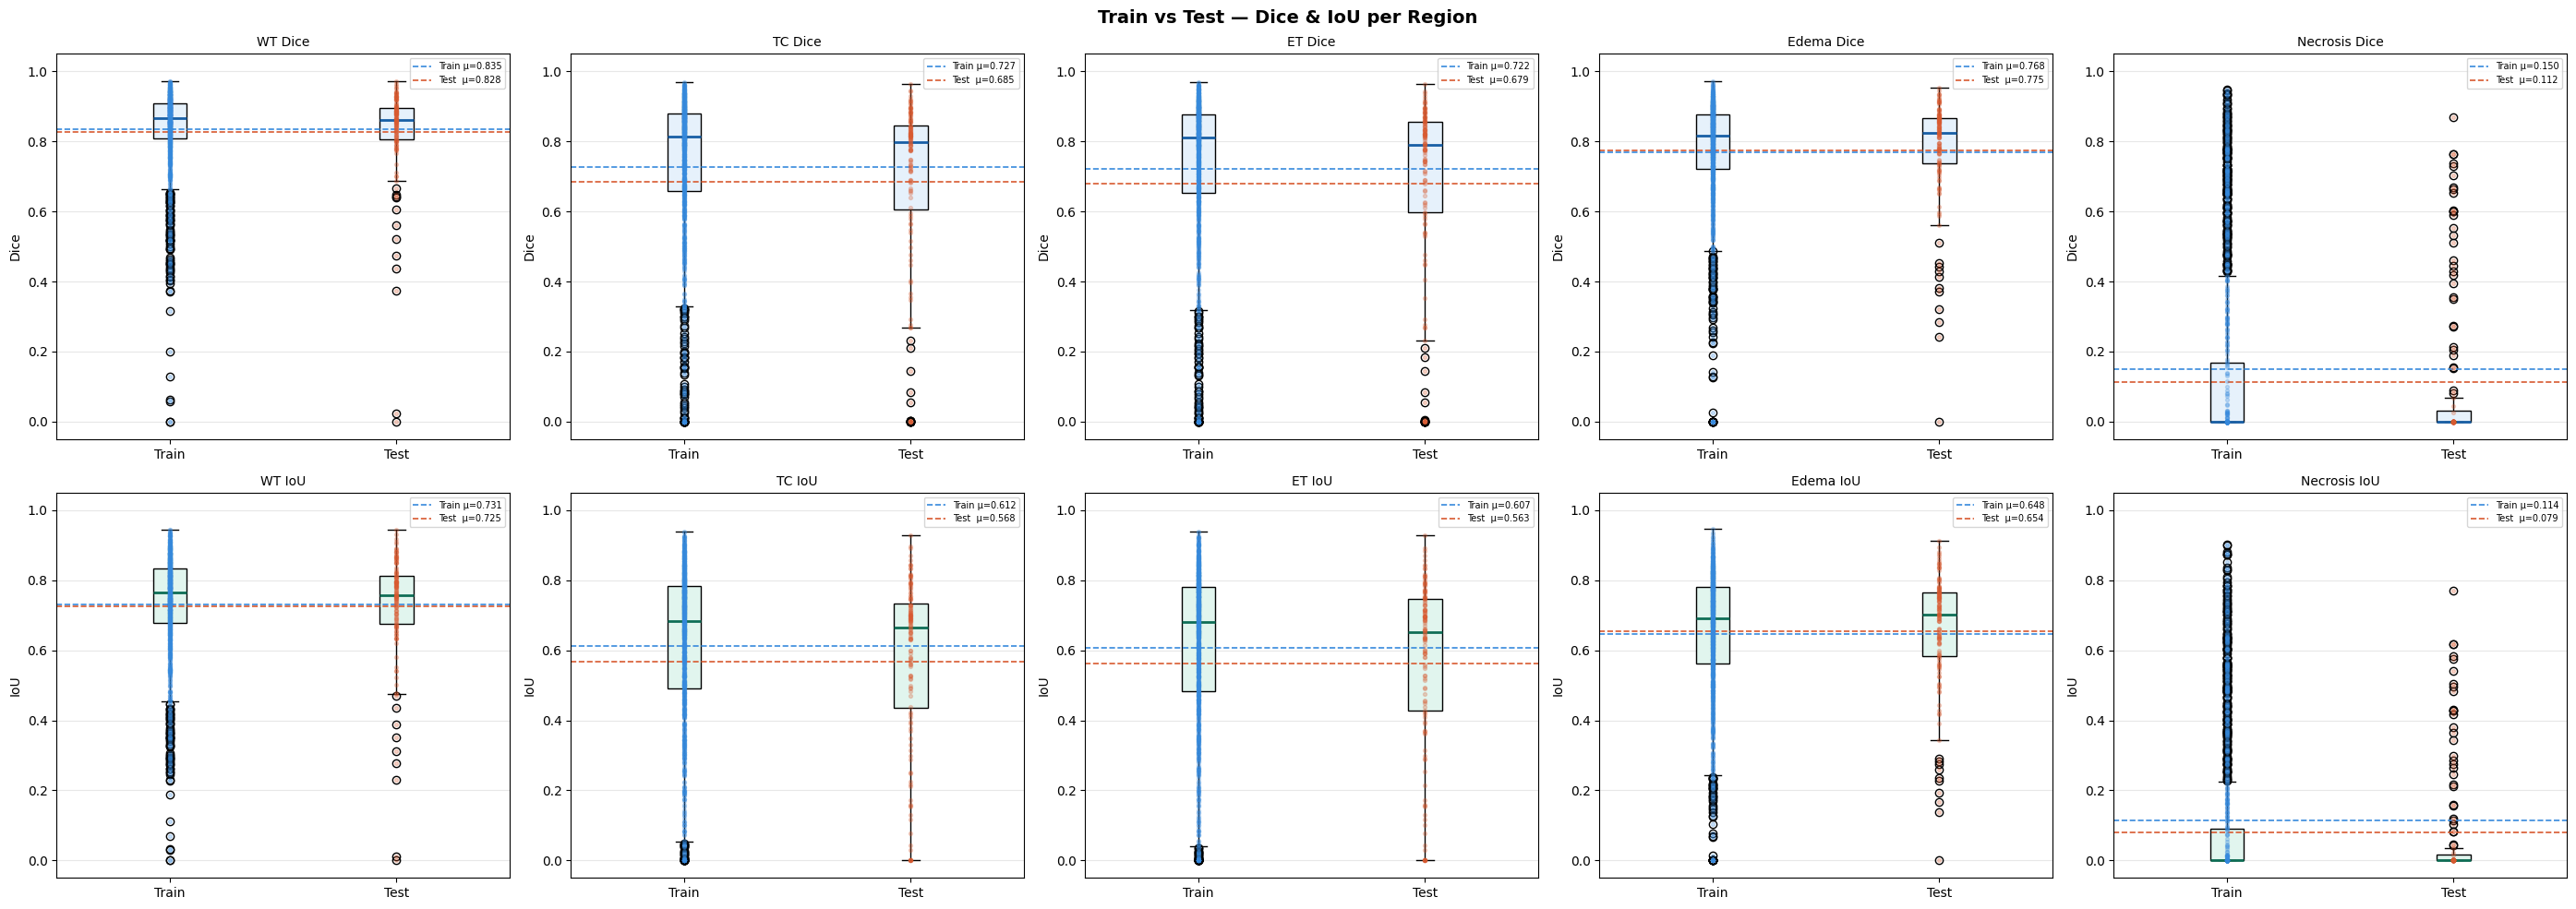

📊 Boxplots saved → D:\shashwat\models_phase2\eval_boxplots.png


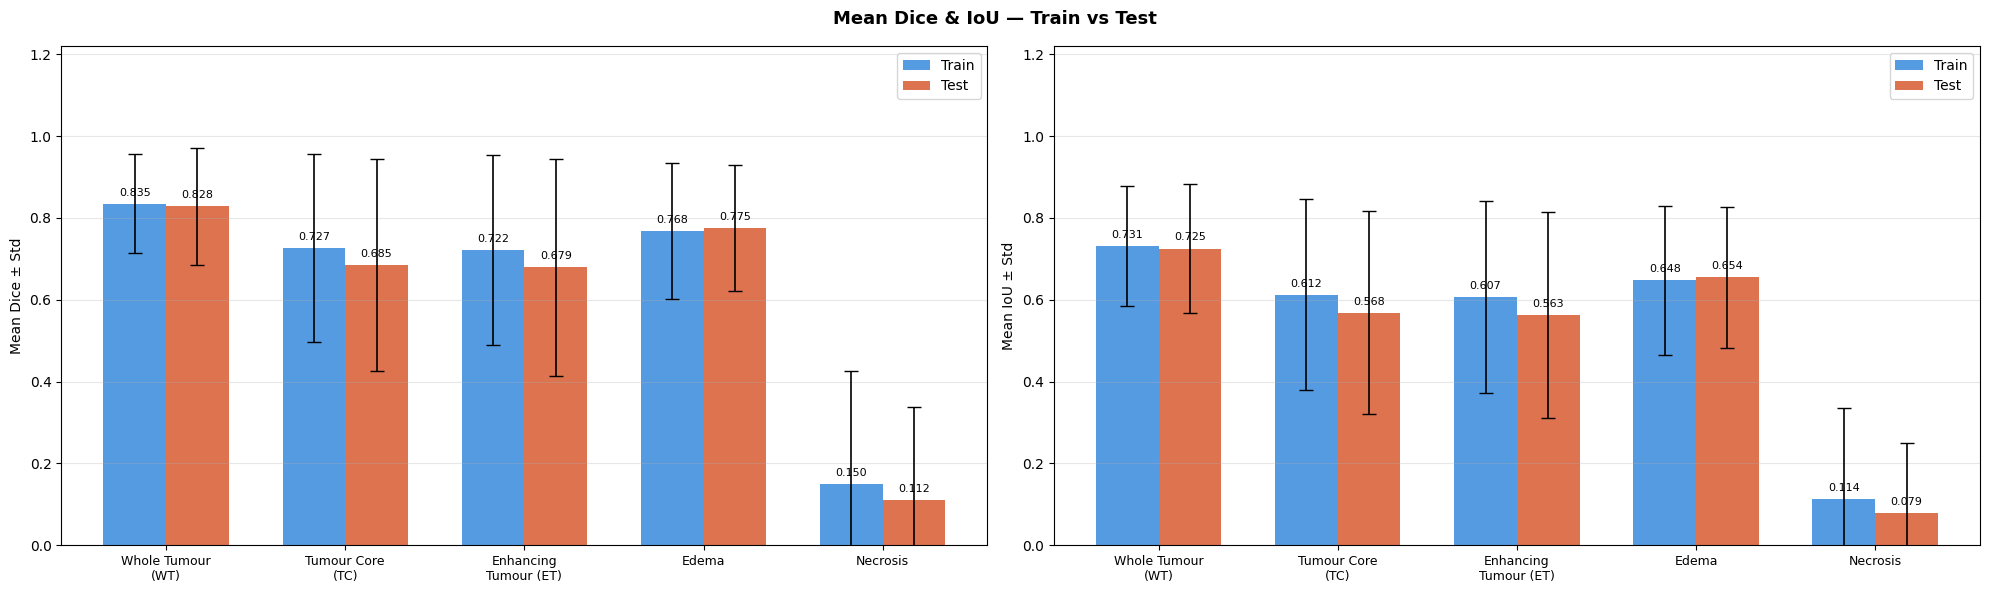

📊 Bar chart saved → D:\shashwat\models_phase2\eval_barchart.png


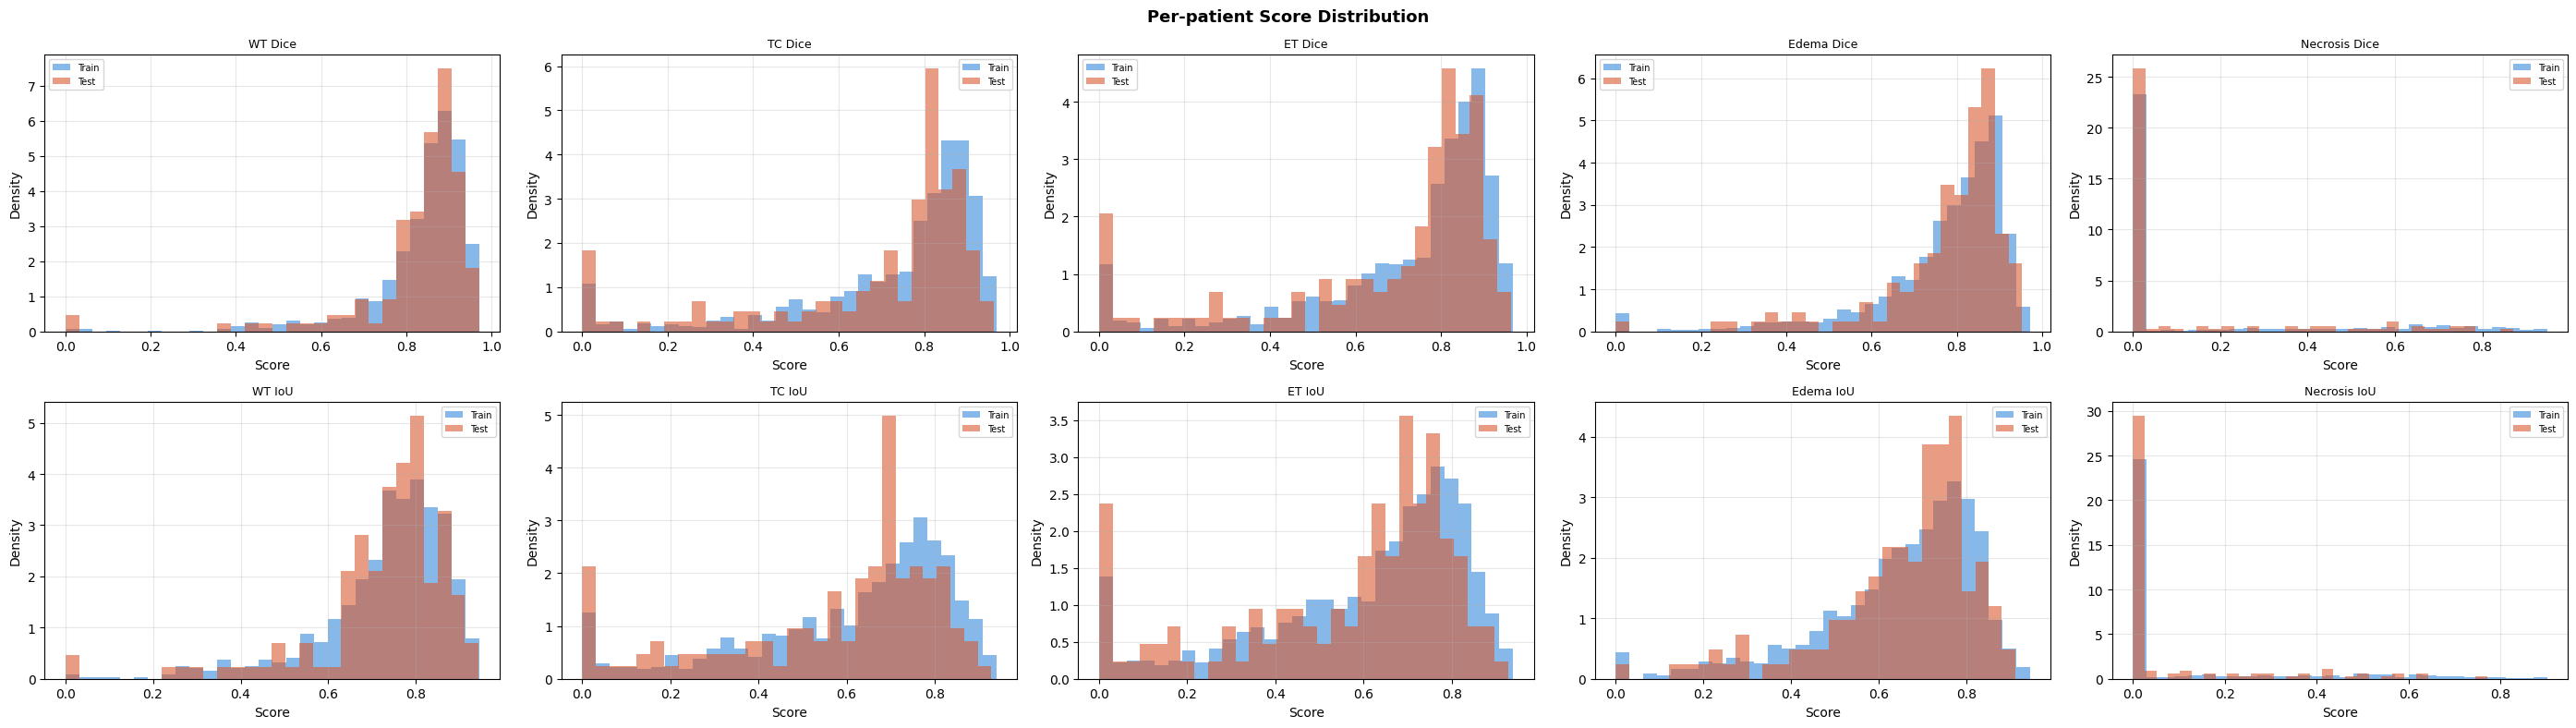

📊 Histograms saved → D:\shashwat\models_phase2\eval_histograms.png

✅ Evaluation complete.


In [ ]:
# ============================================================
# BATCH EVALUATION — Train vs Test Dice/IoU comparison
# Regions: WT, TC, ET, Edema, Necrosis
# ============================================================

TRAIN_DIR   = r"D:\shashwat\train"
TEST_DIR    = r"D:\shashwat\test"
MODEL_DIR   = r"D:\shashwat\models_phase2"
OUTPUT_CSV  = r"D:\shashwat\eval_results.csv"

# ============================================================
import numpy as np
import nibabel as nib
import joblib
import os
import gc
import glob
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import (uniform_filter, gaussian_filter,
                            sobel as nd_sobel,
                            label as nd_label,
                            laplace,
                            distance_transform_edt)
from skimage.filters import gabor_kernel
from sklearn.metrics import f1_score, jaccard_score
import time

MODALITIES     = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX     = 'seg'
N_CLASSES      = 4
# ── UPDATED: 5 regions ────────────────────────────────────
REGIONS = {
    'WT':       [1, 2, 3],   # Whole Tumour
    'TC':       [1, 3],      # Tumour Core
    'ET':       [3],         # Enhancing Tumour  (label 3, was 4 in raw)
    'Edema':    [2],         # Peritumoral Edema (label 2)
    'Necrosis': [1],         # Necrotic Core     (label 1)
}
MRF_BETA       = 0.5
MRF_ITERATIONS = 2

# ============================================================
# LOAD MODEL + CONFIG
# ============================================================
print("📦 Loading model and config...")
xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_final_phase2.pkl"))
print("   ✅ Model loaded")

cfg_path = os.path.join(MODEL_DIR, "best_config.npy")
if os.path.exists(cfg_path):
    cfg = np.load(cfg_path, allow_pickle=True).item()
    print("   ✅ Config loaded")
else:
    cfg = {'wt_threshold': 0.35,
           'boost': np.array([1.0, 2.5, 1.0, 2.0], np.float32)}
    print("   ⚠️  Config not found — using defaults")

print(f"   WT threshold : {cfg['wt_threshold']}")
print(f"   Boost        : {cfg['boost']}")
print(f"   MRF iters    : {MRF_ITERATIONS}")

# ============================================================
# HELPER FUNCTIONS  (unchanged)
# ============================================================
gabor_kernels = [
    np.real(gabor_kernel(0.2, theta=t)).astype(np.float32)
    for t in [0, np.pi/4, np.pi/2, 3*np.pi/4]
]

def fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol**2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean**2, 0)).astype(np.float32)

def apply_gabor_3d(vol, kernel_2d):
    from scipy.ndimage import convolve
    return convolve(vol.astype(np.float32),
                    kernel_2d[:, :, np.newaxis],
                    mode='reflect').astype(np.float32)

def entropy_proxy(vol, size=5):
    lmean = uniform_filter(np.abs(vol).astype(np.float32), size=size)
    return (fast_local_std(vol, size) / (lmean + 1e-6)).astype(np.float32)

def distance_to_edge(mask):
    dist = distance_transform_edt(mask).astype(np.float32)
    return dist / (dist.max() + 1e-8)

def zscore(vol, mask):
    v = vol.copy()
    roi = v[mask]
    v[mask]  = (roi - roi.mean()) / (roi.std() + 1e-8)
    v[~mask] = 0.0
    return v

def extract_features(proc, brain_mask):
    cols = []
    dist_edge = distance_to_edge(brain_mask)

    def add(vol):
        cols.append(vol[brain_mask].astype(np.float32))

    for mod in MODALITIES:
        vol = proc[mod].astype(np.float32)
        add(vol.copy())
        for sz in [3, 5, 9, 15]:
            add(uniform_filter(vol, size=sz))
            add(fast_local_std(vol, size=sz))
        gx = nd_sobel(vol, axis=0)
        gy = nd_sobel(vol, axis=1)
        gz = nd_sobel(vol, axis=2)
        add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
        del gx, gy, gz
        add(np.abs(laplace(vol)).astype(np.float32))
        g1 = gaussian_filter(vol, sigma=1.0)
        g2 = gaussian_filter(vol, sigma=2.0)
        g3 = gaussian_filter(vol, sigma=3.0)
        add(g1); add(g2); add(g3)
        add((g1 - g2).astype(np.float32))
        add((g2 - g3).astype(np.float32))
        del g1, g2, g3
        for k in gabor_kernels:
            add(apply_gabor_3d(vol, k))
        add((vol - vol[::-1, :, :]).astype(np.float32))
        add(entropy_proxy(vol))
        add(dist_edge)
        del vol
        gc.collect()

    shape = proc[MODALITIES[0]].shape
    cx, cy, cz = [s/2 for s in shape]
    xx, yy, zz = np.meshgrid(
        np.linspace(0, 1, shape[0], dtype=np.float32),
        np.linspace(0, 1, shape[1], dtype=np.float32),
        np.linspace(0, 1, shape[2], dtype=np.float32),
        indexing='ij')
    add(xx); add(yy); add(zz)
    xn = (np.arange(shape[0], dtype=np.float32) - cx) / (cx + 1e-8)
    yn = (np.arange(shape[1], dtype=np.float32) - cy) / (cy + 1e-8)
    zn = (np.arange(shape[2], dtype=np.float32) - cz) / (cz + 1e-8)
    add(np.sqrt(xn[:,None,None]**2 + yn[None,:,None]**2 + zn[None,None,:]**2
                ).astype(np.float32))
    del xx, yy, zz; gc.collect()

    eps = 1e-8
    t1c = proc['t1c'].astype(np.float32)
    t1n = proc['t1n'].astype(np.float32)
    t2f = proc['t2f'].astype(np.float32)
    t2w = proc['t2w'].astype(np.float32)
    add(np.clip(t2w / (t1c + eps), -10, 10))
    add(np.clip(t2f / (t1n + eps), -10, 10))
    add(t2f - t1c);  add(t2w - t1n);  add(t1c - t1n)
    add(t2f - t2w);  add(t1c - t2f);  add(t1c - t2w)
    add(np.clip(t1c / (t2f + eps), -10, 10))
    add(gaussian_filter((t1c - t1n).astype(np.float32), sigma=1.5))
    add(np.clip(t2f / (t2w + eps), -10, 10))
    add((t1c * t2f) / (np.abs(t1c * t2f).max() + eps))
    add((t1n * t2w) / (np.abs(t1n * t2w).max() + eps))
    del t1c, t1n, t2f, t2w; gc.collect()

    return np.column_stack(cols).astype(np.float32)


_COMPAT = np.array([
    [ 0.0, -1.0, -0.5, -1.0],
    [-1.0,  0.0, -0.8,  0.0],
    [-0.5, -0.8,  0.0, -0.8],
    [-1.0,  0.0, -0.8,  0.0],
], dtype=np.float32)


def run_patient(patient_dir):
    patient_dir = Path(patient_dir)
    pid  = patient_dir.name
    data = {}

    for mod in MODALITIES + [SEG_SUFFIX]:
        matches = glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz"))
        if not matches:
            matches = glob.glob(str(patient_dir / f"*-{mod}.nii.gz"))
        if not matches:
            if mod == SEG_SUFFIX:
                return None
            raise FileNotFoundError(f"{pid}: missing {mod}")
        data[mod] = nib.load(matches[0]).get_fdata(dtype=np.float32)

    brain_mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
    for mod in MODALITIES:
        brain_mask |= (data[mod] > 0)

    proc  = {mod: zscore(data[mod], brain_mask) for mod in MODALITIES}
    shape = proc[MODALITIES[0]].shape

    X = extract_features(proc, brain_mask)
    del proc; gc.collect()

    BATCH = 500_000
    proba_parts = []
    for s in range(0, len(X), BATCH):
        proba_parts.append(
            xgb_model.predict_proba(X[s:s+BATCH]).astype(np.float32))
    proba_flat = np.concatenate(proba_parts)
    del X; gc.collect()

    proba_vol = np.zeros((N_CLASSES, *shape), dtype=np.float32)
    for c in range(N_CLASSES):
        v = np.zeros(shape, dtype=np.float32)
        v[brain_mask] = proba_flat[:, c]
        proba_vol[c]  = v

    boost = np.array(cfg['boost'], dtype=np.float32)
    proba_vol *= boost[:, None, None, None]
    proba_vol /= proba_vol.sum(axis=0, keepdims=True) + 1e-8

    unary = np.log(np.clip(proba_vol, 1e-6, 1.0))
    q = proba_vol.copy()
    for _ in range(MRF_ITERATIONS):
        q_sm  = np.stack([
            gaussian_filter(q[c].astype(np.float64), sigma=1.0).astype(np.float32)
            for c in range(N_CLASSES)])
        msg   = np.einsum('cd,dxyz->cxyz', _COMPAT, q_sm)
        log_q = unary - MRF_BETA * msg
        log_q -= log_q.max(axis=0, keepdims=True)
        q      = np.exp(log_q)
        q     /= q.sum(axis=0, keepdims=True) + 1e-8
    proba_vol = q

    pred_vol   = proba_vol.argmax(axis=0).astype(np.int8)
    prob_tumor = proba_vol[[1,2,3]].sum(axis=0)
    pred_vol[prob_tumor < cfg['wt_threshold']] = 0
    pred_vol[~brain_mask] = 0

    for lbl in [3, 1, 2]:
        binary          = (pred_vol == lbl).astype(np.uint8)
        labeled, n_comp = nd_label(binary)
        for cid in range(1, n_comp + 1):
            if (labeled == cid).sum() < 200:
                pred_vol[labeled == cid] = 0

    del proba_flat; gc.collect()

    gt = data[SEG_SUFFIX].astype(np.int8)
    gt[gt == 4] = 3          # BraTS remapping: ET label 4 → 3
    y_true = gt[brain_mask]
    y_pred = pred_vol[brain_mask]

    # ── Compute dice + iou for ALL 5 regions ──────────────
    row = {'patient': pid}
    for region, labels in REGIONS.items():
        gt_r   = np.isin(y_true, labels).astype(np.uint8)
        pred_r = np.isin(y_pred, labels).astype(np.uint8)
        row[f'{region}_dice'] = float(f1_score(gt_r, pred_r, zero_division=0))
        row[f'{region}_iou']  = float(jaccard_score(gt_r, pred_r, zero_division=0))

    return row


# ============================================================
# COLLECT PATIENT DIRS
# ============================================================
def get_patient_dirs(root):
    return sorted([d for d in Path(root).iterdir() if d.is_dir()])

train_dirs = get_patient_dirs(TRAIN_DIR)
test_dirs  = get_patient_dirs(TEST_DIR)

print(f"\n📁 Train patients : {len(train_dirs)}")
print(f"   Test  patients : {len(test_dirs)}")
print(f"   Total          : {len(train_dirs) + len(test_dirs)}")

# ============================================================
# CLEAN RESTART
# ============================================================
if os.path.exists(OUTPUT_CSV):
    os.remove(OUTPUT_CSV)
    print(f"\n🗑️  Deleted existing checkpoint: {OUTPUT_CSV}")

all_rows      = []
failed        = []
done_patients = set()
CHECKPOINT_EVERY = 25

# ============================================================
# RUN EVALUATION
# ============================================================
def eval_split(dirs, split_name):
    t0 = time.time()
    done_count = 0
    for i, pdir in enumerate(tqdm(dirs, desc=split_name)):
        pid = Path(pdir).name
        try:
            row = run_patient(pdir)
            if row:
                row['split'] = split_name.lower()
                all_rows.append(row)
                done_patients.add(pid)
                done_count += 1
        except Exception as e:
            failed.append((pid, str(e)))
            tqdm.write(f"⚠️  {pid}: {e}")

        if done_count > 0 and done_count % CHECKPOINT_EVERY == 0:
            pd.DataFrame(all_rows).to_csv(OUTPUT_CSV, index=False)
            elapsed   = (time.time() - t0) / 60
            remaining = (elapsed / done_count) * (len(dirs) - i - 1)
            tqdm.write(f"   💾 Checkpoint saved ({done_count} done) | "
                       f"elapsed {elapsed:.0f} min | "
                       f"~{remaining:.0f} min remaining")

    pd.DataFrame(all_rows).to_csv(OUTPUT_CSV, index=False)
    print(f"   ✅ {split_name} done in {(time.time()-t0)/60:.1f} min")

print(f"── Evaluating TRAIN ({len(train_dirs)} patients) ──────────────")
eval_split(train_dirs, "train")

print(f"\n── Evaluating TEST ({len(test_dirs)} patients) ───────────────")
eval_split(test_dirs, "test")

# ============================================================
# FINAL SAVE + FAILURE REPORT
# ============================================================
df = pd.DataFrame(all_rows)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\n💾 Final results saved → {OUTPUT_CSV}")
print(f"   Total patients evaluated : {len(df)}")

if failed:
    print(f"\n⚠️  {len(failed)} patients failed:")
    for pid, err in failed:
        print(f"   {pid}: {err}")

# ============================================================
# SUMMARY STATS  — all 5 regions, 10 metrics
# ============================================================
metrics  = [
    'WT_dice', 'TC_dice', 'ET_dice', 'Edema_dice', 'Necrosis_dice',
    'WT_iou',  'TC_iou',  'ET_iou',  'Edema_iou',  'Necrosis_iou',
]
regions  = list(REGIONS.keys())          # ['WT','TC','ET','Edema','Necrosis']
df_train = df[df['split'] == 'train']
df_test  = df[df['split'] == 'test']

def summary(split_df, label):
    print(f"\n{'='*68}")
    print(f"  {label}  ({len(split_df)} patients)")
    print(f"{'='*68}")
    print(f"  {'Metric':<16} {'Mean':>8} {'Std':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'-'*68}")
    for m in metrics:
        v = split_df[m]
        print(f"  {m:<16} {v.mean():>8.4f} {v.std():>8.4f} "
              f"{v.median():>8.4f} {v.min():>8.4f} {v.max():>8.4f}")

summary(df_train, "TRAIN")
summary(df_test,  "TEST")

print(f"\n{'='*72}")
print(f"  TRAIN vs TEST COMPARISON")
print(f"{'='*72}")
print(f"  {'Metric':<16} {'Train':>10} {'Test':>10} {'Gap (Tr-Te)':>13} {'Overfit?':>10}")
print(f"  {'-'*72}")
for m in metrics:
    tr   = df_train[m].mean()
    te   = df_test[m].mean()
    gap  = tr - te
    flag = '⚠️  yes' if gap > 0.05 else '✅  no'
    print(f"  {m:<16} {tr:>10.4f} {te:>10.4f} {gap:>+13.4f} {flag:>10}")

# ============================================================
# PLOTS
# ============================================================
colors = {'train': '#378ADD', 'test': '#D85A30'}

region_labels = {
    'WT':       'Whole Tumour\n(WT)',
    'TC':       'Tumour Core\n(TC)',
    'ET':       'Enhancing\nTumour (ET)',
    'Edema':    'Edema',
    'Necrosis': 'Necrosis',
}

# ── Boxplot grid  2 × 5 ───────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(28, 10))
fig.suptitle("Train vs Test — Dice & IoU per Region", fontsize=14, fontweight='bold')

for col, region in enumerate(regions):
    for row, metric in enumerate(['dice', 'iou']):
        ax  = axes[row, col]
        key = f'{region}_{metric}'
        tr_vals = df_train[key].dropna().values
        te_vals = df_test[key].dropna().values

        ax.boxplot([tr_vals, te_vals],
                   labels=['Train', 'Test'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#E6F1FB' if metric=='dice' else '#E1F5EE'),
                   medianprops=dict(color='#185FA5' if metric=='dice' else '#0F6E56',
                                    linewidth=2),
                   whiskerprops=dict(linewidth=1),
                   capprops=dict(linewidth=1))

        ax.scatter([1]*len(tr_vals), tr_vals,
                   alpha=0.25, s=8, color=colors['train'], zorder=3)
        ax.scatter([2]*len(te_vals), te_vals,
                   alpha=0.25, s=8, color=colors['test'], zorder=3)
        ax.axhline(np.mean(tr_vals), color=colors['train'],
                   linestyle='--', linewidth=1.2,
                   label=f'Train μ={np.mean(tr_vals):.3f}')
        ax.axhline(np.mean(te_vals), color=colors['test'],
                   linestyle='--', linewidth=1.2,
                   label=f'Test  μ={np.mean(te_vals):.3f}')
        ax.set_title(f'{region} {"Dice" if metric=="dice" else "IoU"}', fontsize=10)
        ax.set_ylabel('Dice' if metric == 'dice' else 'IoU')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
boxplot_path = os.path.join(MODEL_DIR, "eval_boxplots.png")
plt.savefig(boxplot_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"📊 Boxplots saved → {boxplot_path}")

# ── Bar chart  1 × 2 ──────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(20, 6))
fig2.suptitle("Mean Dice & IoU — Train vs Test", fontsize=13, fontweight='bold')

x     = np.arange(len(regions))
width = 0.35

for ax, metric, ylabel in zip(axes2, ['dice', 'iou'], ['Mean Dice ± Std', 'Mean IoU ± Std']):
    tr_m = [df_train[f'{r}_{metric}'].mean() for r in regions]
    te_m = [df_test[f'{r}_{metric}'].mean()  for r in regions]
    tr_s = [df_train[f'{r}_{metric}'].std()  for r in regions]
    te_s = [df_test[f'{r}_{metric}'].std()   for r in regions]

    b1 = ax.bar(x - width/2, tr_m, width, yerr=tr_s,
                label='Train', color='#378ADD', alpha=0.85,
                capsize=5, error_kw={'linewidth': 1.2})
    b2 = ax.bar(x + width/2, te_m, width, yerr=te_s,
                label='Test',  color='#D85A30', alpha=0.85,
                capsize=5, error_kw={'linewidth': 1.2})

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.015,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([region_labels[r] for r in regions], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.22)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()  
bar_path = os.path.join(MODEL_DIR, "eval_barchart.png")
plt.savefig(bar_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"📊 Bar chart saved → {bar_path}")

# ── Histograms  2 × 5 ─────────────────────────────────────
fig3, axes3 = plt.subplots(2, 5, figsize=(28, 8))
fig3.suptitle("Per-patient Score Distribution", fontsize=13, fontweight='bold')

for col, region in enumerate(regions):
    for row, metric in enumerate(['dice', 'iou']):
        ax  = axes3[row, col]
        key = f'{region}_{metric}'
        ax.hist(df_train[key].dropna(), bins=30, alpha=0.6,
                color=colors['train'], label='Train', density=True)
        ax.hist(df_test[key].dropna(),  bins=30, alpha=0.6,
                color=colors['test'],  label='Test',  density=True)
        ax.set_title(f'{region} {"Dice" if metric=="dice" else "IoU"}', fontsize=9)
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.tight_layout()
hist_path = os.path.join(MODEL_DIR, "eval_histograms.png")
plt.savefig(hist_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"📊 Histograms saved → {hist_path}")

print("\n✅ Evaluation complete.")